# Imports

In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import sys
from typing import List, Dict
from pypalettes import load_palette
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne_hill import *
from nbutils.data_loader import load_all_experiments

from nbutils.lsf_zne import *
import nbutils.rtc_fitting as rtc
from nbutils.rtc_analysis import perform_rtc_analysis

#### Plot markup settting

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    #"font.serif": "Computer Modern Roman",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

---

### Load experimental data

In [3]:
# ==========================================
# Recursive experiment loader
# ==========================================

def load_all_experiments(data_root):
    """
    Recursively load all experiments under data_root and
    populate a master data_records dictionary.

    Parameters
    ----------
    data_root : str or Path
        Root directory containing experiment folders (e.g. data/)

    Returns
    -------
    data_records : dict
        Master experiment registry
    """
    data_root = Path(data_root)
    data_records = {}

    # Iterate over subdirectories like c0, c0.01, ...
    for exp_dir in sorted(p for p in data_root.iterdir() if p.is_dir()):
        experiment_id = exp_dir.name

        json_files = sorted(exp_dir.rglob("iter_*.json"))
        if not json_files:
            continue  # skip empty folders

        # --------------------------
        # Load and group raw data
        # --------------------------
        raw_groups = {}
        exact_solution = None

        for jf in json_files:
            with open(jf, "r") as f:
                data = json.load(f)

            t_max = data["config"]["ansatz"]["ugate"]["time"]["max"]
            cost = data["output"]["optimized_minimum_cost"][0]

            if exact_solution is None:
                exact_solution = data["output"].get("exact_sol", None)

            raw_groups.setdefault(t_max, []).append(cost)

        # --------------------------
        # Processed arrays
        # --------------------------
        t_vals = np.array(sorted(raw_groups.keys()))
        vqe_means = np.array([np.mean(raw_groups[t]) for t in t_vals])
        vqe_stds = np.array([np.std(raw_groups[t]) for t in t_vals])

        # --------------------------
        # Register experiment
        # --------------------------
        data_records[experiment_id] = {
            "meta": {
                "experiment_id": experiment_id,
                "data_path": str(exp_dir),
                "num_json_files": len(json_files),
                "noise_level": float(experiment_id.replace("c", "")) if experiment_id.startswith("c") else None,
            },

            "raw": {
                "json_files": [str(f) for f in json_files],
                "grouped_costs": raw_groups,
            },

            "processed": {
                "t_max": t_vals,
                "vqe_means": vqe_means,
                "vqe_stds": vqe_stds,
                "exact_solution": exact_solution,
            },

        }

    return data_records

### Data container

In [4]:
data_records = load_all_experiments("data")

In [5]:
# ==========================================
# DATA EXTRACTION
# ==========================================
data_dir = Path("data/c0")
json_files = sorted(data_dir.rglob("iter_*.json"))

raw_groups, exact_sol = {}, None
for f in json_files:
    with open(f, "r") as file:
        data = json.load(file)
        big_t = data["config"]["ansatz"]["ugate"]["time"]["max"]
        cost = data["output"]["optimized_minimum_cost"][0]
        #if exact_sol is None: exact_sol = data["output"]["exact_sol"]
        if big_t not in raw_groups: raw_groups[big_t] = []
        raw_groups[big_t].append(cost)

EXPERIMENTAL_PROCESSED_DATA = [[(np.mean(raw_groups[t]), np.std(raw_groups[t])), t] for t in sorted(raw_groups.keys())]
print(f"Len: {len(EXPERIMENTAL_PROCESSED_DATA)}")
print(f"Extracted data for {EXPERIMENTAL_PROCESSED_DATA} noise levels.")

Len: 51
Extracted data for [[(3.0000000817631687, 6.991934657836011e-08), 0], [(1.512344102998239, 0.013932395296170701), 1], [(0.34048750489580726, 0.035478751604426574), 2], [(-1.015718826414441, 0.0345301431008247), 3], [(-2.4914599115717384, 0.08496204398301681), 4], [(-3.295158795505818, 0.2343733313117736), 5], [(-4.062004110615584, 0.15865549389626196), 6], [(-4.710940886686118, 0.21010772943622058), 7], [(-4.848972203941356, 0.19079480233245977), 8], [(-5.124314668335285, 0.1621580343826099), 9], [(-5.36806750137307, 0.19087855942686316), 10], [(-5.530711658622038, 0.16442349747081578), 11], [(-5.68977426806609, 0.16536366548814804), 12], [(-5.724989888801153, 0.1599278825799889), 13], [(-5.797664146300366, 0.12925006513377796), 14], [(-5.8500918167345475, 0.11648195027346925), 15], [(-5.817524418404128, 0.1475214842575809), 16], [(-5.904683436616966, 0.07204586425527805), 17], [(-5.9298316312568415, 0.07567479045998024), 18], [(-5.910673807120366, 0.10301714506773366), 19], [(

In [6]:
#LSF_WINDOWS = [(10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90), (10, 100)]
LSF_WINDOWS = [(0, 30), (0,40), (0, 50)]
EXACT_SOLUTION = -6.026674183332271
print("EXACT_SOLUTION =", EXACT_SOLUTION)

EXACT_SOLUTION = -6.026674183332271


In [7]:
# Extracting components
vqe_means_c0 = data_records["c0"]["processed"]["vqe_means"]
vqe_stds_c0 = data_records["c0"]["processed"]["vqe_stds"]
noise_levels_c0 = data_records["c0"]["processed"]["t_max"]

print(f"Loaded {len(noise_levels_c0)} data points.")
print("EXACT_SOLUTION =", EXACT_SOLUTION)

Loaded 51 data points.
EXACT_SOLUTION = -6.026674183332271


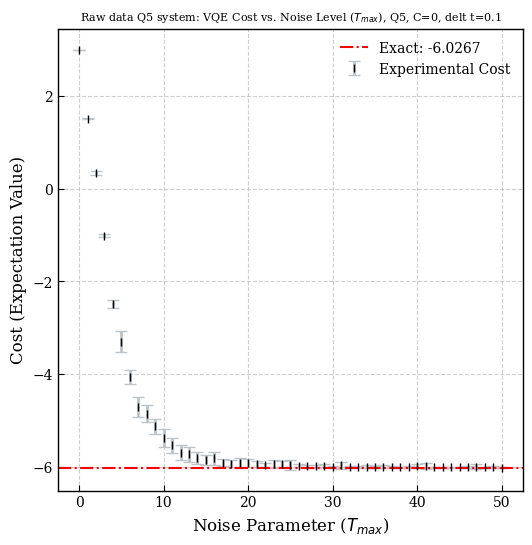

In [8]:
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='Experimental Cost')

plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$), Q5, C=0, delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
#plt.savefig('raw_data_trend.png')
plt.show()

---

### $n$ from noise-free $C=0$ in $T_{max}$ range [0, 30]

In [9]:
# Noiseless guesses
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0
T0_GUESS_NOISELESS = 8.0

In [10]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""
mask = 31
t = noise_levels_c0[:mask]          # T_max
y = vqe_means_c0[:mask]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:mask]

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]

# Guesses for noise-free data hill fitting
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0

T0_GUESS_NOISELESS = 8.0
p0 = [ZNE_GUESS_NOISELESS, A0_GUESS_NOISELESS, T0_GUESS_NOISELESS]

bounds = (
    [-10.0, 0.0, 0],
    [-1.0, 20.0, 50.0],
)

fit_results = {}
for n in n_values:

    result_fit_hill_noiseless_across_n = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = result_fit_hill_noiseless_across_n["output"]["popt"]
    pcov = result_fit_hill_noiseless_across_n["output"]["pcov"]

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    # Store results in dictionary
    fit_results[n] = {
        "initial_guess": {"ZNE0": p0[0], "A0_0": p0[1], "T0_0": p0[2]},
        "params": {"ZNE": ZNE, "A0": A0, "T0": T0},
        "LS": LS_red,
    }
# --- Print Summary Table ---
print(f"T_max range [0, 30]: {t}\n\n")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]

    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]


 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |     8.00 ||   -7.8104 |   10.8439 |     5.07 |   33.802
 2 |    -5.000 |    10.000 |     8.00 ||   -6.0875 |    9.0206 |     3.04 |   25.351
 3 |    -5.000 |    10.000 |     8.00 ||   -5.9365 |    8.7690 |     2.98 |   88.591
 4 |    -5.000 |    10.000 |     8.00 ||   -5.9073 |    8.6807 |     3.03 |  138.008
 5 |    -5.000 |    10.000 |     8.00 ||   -5.8952 |    8.6358 |     3.07 |  172.480
 6 |    -5.000 |    10.000 |     8.00 ||   -5.8876 |    8.6075 |     3.09 |  197.901
 7 |    -5.000 |    10.000 |     8.00 ||   -5.8811 |    8.5875 |     3.10 |  217.025
 8 |    -5.000 |    10.000 |     8.00 ||   -5.8746 |    8.5723 |     3.10 |  231.458
 9 |    -5.000 |   

In [11]:
BEST_n_FROM_C0  = 2
######################################################################
BEST_T0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["T0"]
BEST_A0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["A0"]
ZNE_c0_best = fit_results[BEST_n_FROM_C0]["params"]["ZNE"]
E_mix   = 0.0   # Tr(H_Ising) = 0

lsf_record_c0 = {
    "model": "ZNE + A/(1+(t/T0)^n)",
    "lsf": fit_results,
    "bests": {
        "n": BEST_n_FROM_C0,
        "A": BEST_A0_FROM_C0,
        "T0": BEST_T0_FROM_C0,
        "ZNE": ZNE_c0_best,
    }
}
print(f"Best n = {BEST_n_FROM_C0}")
print(f"BEST_T0_FROM_C0 = {BEST_T0_FROM_C0}")
print(f"BEST_A0_FROM_C0 = {BEST_A0_FROM_C0}")
print(f"ZNE_c0_best = {ZNE_c0_best}")

Best n = 2
BEST_T0_FROM_C0 = 3.042397899782802
BEST_A0_FROM_C0 = 9.02055870884778
ZNE_c0_best = -6.087516684866581


---

##  Noisy LSF with $C$=0.01

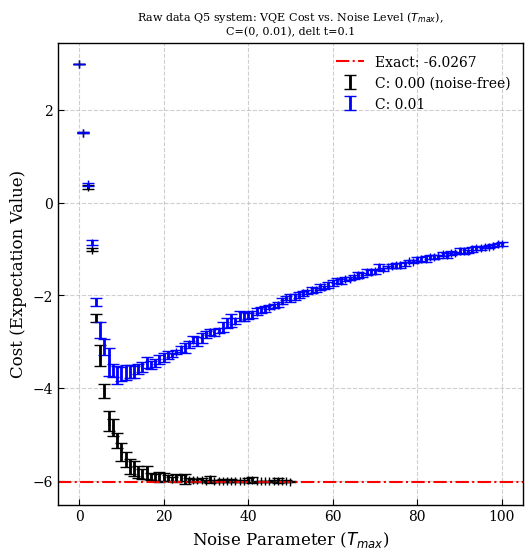

In [12]:
# Extracting components
vqe_means_c0_01 = data_records["c0.01"]["processed"]["vqe_means"]
vqe_stds_c0_01 = data_records["c0.01"]["processed"]["vqe_stds"]
noise_levels_c0_01 = data_records["c0.01"]["processed"]["t_max"]
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='black', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.00 (noise-free)')
plt.errorbar(noise_levels_c0_01, vqe_means_c0_01, yerr=vqe_stds_c0_01, fmt='|', color='blue', 
             ecolor='blue', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.01')
plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$),\nC=(0, 0.01), delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
# plt.savefig('raw_data_trend.png')
plt.show()

#### $\gamma$ from large $T_{max} = [50, 100]$

$$f_{\text{noisy}}(t) = B \cdot e^{-\gamma t}, \quad t \in [50, 100]$$

In [13]:
# =========================
# Data selection (large-t window)
# =========================
mask = 51
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][-mask:]
y = rec["processed"]["vqe_means"][-mask:]
sigma = rec["processed"]["vqe_stds"][-mask:]

# =========================
# Initial guesses and bounds
# Model: f(t) = B * exp(-gamma * t)
# Parameter order: [gamma, B]
# =========================
B_guess = BEST_A0_FROM_C0 + ZNE_c0_best
p0 = [
    0.05,      # gamma: slow decay at large-t
    B_guess,      # B: first point in large-t window
]

bounds = (
    [1e-6, -np.inf],   # gamma > 0, B free
    [1.0,   np.inf],   # gamma not too large (stiff), B free
)

# =========================
# Call the fitter
# =========================
result_fit_gamma_largeT = fit_gamma_largeT(
    t=t,
    y=y,
    sigma=sigma,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =========================
# Extract results
# =========================
popt = result_fit_gamma_largeT["output"]["popt"]
pcov = result_fit_gamma_largeT["output"]["pcov"]

gamma_fit, B_fit = popt

GAMMA_FROM_LARGE_T = gamma_fit
B_FROM_LARGE_T     = B_fit

# =========================
# Clean summary table
# =========================
print(f"\nLarge-T Exponential Fit: f(t) = B · exp(−γ t) with T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'gamma':>6} | {p0[0]:12.4e} | {gamma_fit:12.4e}")
print(f"{'B':>6} | {p0[1]:12.4e} | {B_fit:12.4e}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.0635e+04                                    2.28e+05    
       1              2         2.7113e+04      3.52e+03       2.93e+00       2.82e-02    
       2              3         2.7113e+04      1.68e-04       7.30e-01       2.81e-04    
       3              4         2.7113e+04      5.37e-03       1.13e-01       7.51e-02    
       4              5         2.6904e+04      2.09e+02       1.93e-01       9.58e+02    
       5              6         1.6465e+03      2.53e+04       6.91e-01       5.04e+03    
       6              7         7.6364e+02      8.83e+02       4.07e-01       6.44e+04    
       7              9         5.1415e+02      2.49e+02       3.67e-01       9.97e+02    
       8             10         2.3252e+02      2.82e+02       7.32e-01       1.43e+03    
       9             11         6.7217e+01      1.65e+02       7.38e-01       9.28e+02    

#### $(ZNE, A, T_0)$ from small $T_{max}=[0, 5]$

$$f_{\text{noisy}}(t) = ZNE + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \text{ where} \quad t \in [0, 5]$$

In [14]:
# =========================
# Data selection (large-t window)
# =========================
mask = 6
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][:mask]
y = rec["processed"]["vqe_means"][:mask]
sigma = rec["processed"]["vqe_stds"][:mask]

# Initial guess and bounds
p0 = [
    ZNE_GUESS_NOISELESS, # ZNE from noise less c=0
    A0_GUESS_NOISELESS,     # A from noiseless c=0
    T0_GUESS_NOISELESS,     # T0 from noiseless c=0
]

bounds = (
    [-10.0,   0.0,  0], # lower [ ZNE, A, T0 ]
    [ 0., 200.0, 10],   # upper [ ZNE, A, T0 ]
)

result_fit_in_smallT = fit_smallT_ZNE(
    t=t,
    y=y,
    sigma=sigma,
    n=BEST_n_FROM_C0,          # fixed exponent BEST_n=2
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =====================================================
# Clean parameter summary (initial vs fitted)
# =====================================================

popt = result_fit_in_smallT["output"]["popt"]
pcov = result_fit_in_smallT["output"]["pcov"]

ZNE_fit, A_fit, T0_fit = popt

ZNE_FROM_NOISY_SMALL_T = ZNE_fit
A_FROM_NOISY_SMALL_T   = A_fit
T0_FROM_NOISY_SMALL_T  = T0_fit

print(f"\nSmall-T Hill Fit:  f(t) = ZNE + A / (1 + (t/T0)^n) with n=2, T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'ZNE':>6} | {p0[0]:12.4f} | {ZNE_fit:12.4f}")
print(f"{'A':>6} | {p0[1]:12.4f} | {A_fit:12.4f}")
print(f"{'T0':>6} | {p0[2]:12.4f} | {T0_fit:12.4f}")


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.3506e+14                                    4.35e+15    
       1              2         6.0216e+12      4.29e+14       3.74e+00       4.52e+14    
       2              3         1.8372e+09      6.02e+12       1.82e+00       7.75e+12    
       3              4         1.2547e+03      1.84e+09       2.86e-01       2.45e+09    
       4              5         1.0653e+03      1.89e+02       2.72e-02       1.29e+03    
       5              6         2.9221e+02      7.73e+02       3.76e+00       4.47e+03    
       6              7         1.7771e+02      1.15e+02       6.31e-01       3.10e+02    
       7              8         1.4298e+02      3.47e+01       6.94e-01       3.30e+02    
       8              9         1.4163e+02      1.35e+00       1.22e-01       1.68e+01    
       9             10         1.4161e+02      2.15e-02       1.73e-02       1.53e+00    

---

In [15]:
print("All fitted parameters:")
print("****************************")
print(f"GAMMA_FROM_LARGE_T = {GAMMA_FROM_LARGE_T}")
print(f"B_FROM_LARGE_T = {B_FROM_LARGE_T}")
print(f"ZNE_FROM_NOISY_SMALL_T = {ZNE_FROM_NOISY_SMALL_T}")
print(f"A_FROM_NOISY_SMALL_T = {A_FROM_NOISY_SMALL_T}")
print(f"T0_FROM_NOISY_SMALL_T = {T0_FROM_NOISY_SMALL_T}")
print("****************************")   
print("End of fitted parameters.")

All fitted parameters:
****************************
GAMMA_FROM_LARGE_T = 0.016757638541062304
B_FROM_LARGE_T = -4.758846539294926
ZNE_FROM_NOISY_SMALL_T = -2.0177814739005315
A_FROM_NOISY_SMALL_T = 5.017781548473394
T0_FROM_NOISY_SMALL_T = 1.5547854398013081
****************************
End of fitted parameters.


---

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right], \quad q=0.7 \text{ for } C=0.01$$

In [16]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}, q=0.7$"

#### Whole system fitting in $T_{max}=[0, 50]$


Fit Results (n=2):
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   5.1099e-02 |   1.3092e-03 | 2.56e-02
   ZNE |  -2.0178e+00 |  -4.8818e+00 |   7.0869e-02 | 1.45e-02
     A |   5.0178e+00 |   7.8818e+00 |   7.0869e-02 | 8.99e-03
    T0 |   1.5548e+00 |   2.2520e+00 |   1.7980e-02 | 7.98e-03


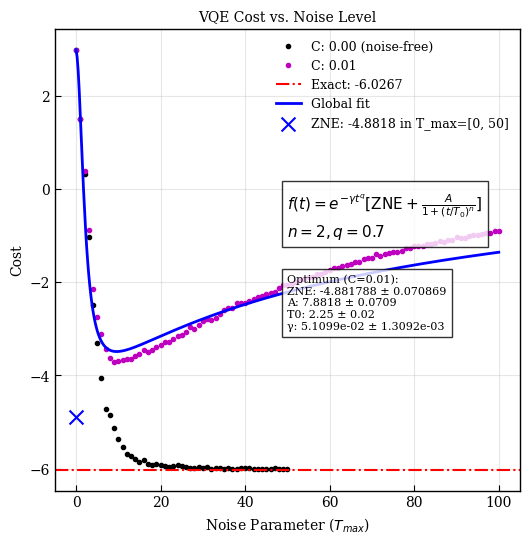

In [17]:
# --- Configuration & Parameters ---
mask_idx = 51
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0
q=0.7
# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimum (C=0.01):\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.35, optimum_val_str, transform=plt.gca().transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.8))

plt.title("VQE Cost vs. Noise Level", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

#### Whole system fitting in $T_{max}=[0, 100]$


Fit Results (n=2):
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   7.2291e-02 |   5.2656e-04 | 7.28e-03
   ZNE |  -2.0178e+00 |  -6.0536e+00 |   5.1227e-02 | 8.46e-03
     A |   5.0178e+00 |   9.0536e+00 |   5.1227e-02 | 5.66e-03
    T0 |   1.5548e+00 |   2.5267e+00 |   1.4468e-02 | 5.73e-03


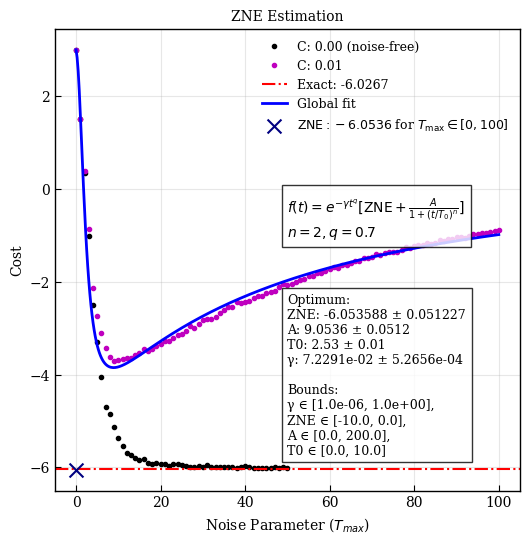

In [18]:
# --- Configuration & Parameters ---
mask_idx = 101
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(
    0, ZNE_fit, 
    color="#000080", marker="x", s=100, zorder=5, 
    label=rf"$\text{{ZNE}}: {ZNE_fit:.4f}$ for $T_{{\max}} \in [0, {mask_idx-1}]$"
)

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimum:\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}\n\n"
    f"Bounds:\nγ ∈ [{bounds[0][0]:.1e}, {bounds[1][0]:.1e}], \nZNE ∈ [{bounds[0][1]:.1f}, {bounds[1][1]:.1f}], \nA ∈ [{bounds[0][2]:.1f}, {bounds[1][2]:.1f}], \nT0 ∈ [{bounds[0][3]:.1f}, {bounds[1][3]:.1f}]"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.08, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.title("ZNE Estimation", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

---

#### Optimizing $q$ test

Fitting parameters $(\gamma, ZNE, A, T_0, q)$

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right]$$

In [19]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}$"

<>:87: DeprecationWarning: invalid escape sequence '\g'
<>:87: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/973428429.py:87: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(ZNE, A, T_0, \gamma, q)$", fontsize=10)



Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.2291e-02 |   5.1099e-02 |   2.4200e-02 | 4.74e-01
   ZNE |  -6.0536e+00 |  -4.8818e+00 |   3.7925e-01 | 7.77e-02
     A |   9.0536e+00 |   7.8818e+00 |   3.7925e-01 | 4.81e-02
    T0 |   2.5267e+00 |   2.2520e+00 |   1.0565e-01 | 4.69e-02
     q |   8.0000e-01 |   7.0000e-01 |   9.7458e-02 | 1.39e-01


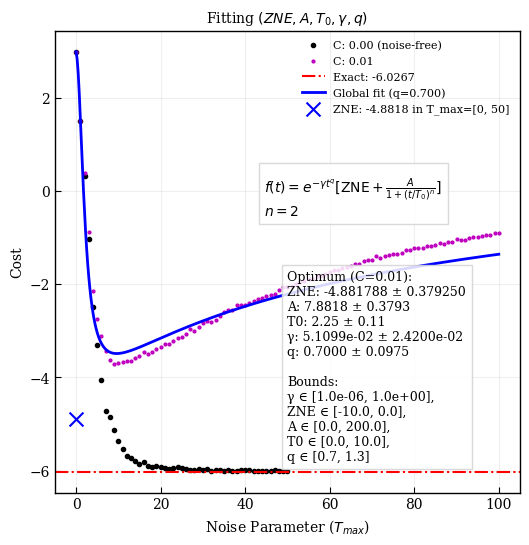

In [20]:
# --- Configuration & Parameters ---
mask_idx = 51
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, ZNE, A, T0, q]
# p0 uses your carefully crafted variables with q initialized at 1.0
p0 = [
    gamma_fit, ZNE_fit, A_fit, T0_fit,
    0.8
]

bounds = (
    [1e-6, -10.0, 0.0, 0, 0.7], # Lower
    [1.0, 0.0, 200.0, 10, 1.3]   # Upper (constrained q to +10%)
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
# Note: Using your updated function name fit_fq_noisy
result_global = fit_fq_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors from covariance matrix
perr = np.sqrt(np.diag(pcov))

# Unpacking results
gamma_fit, ZNE_fit, A_fit, T0_fit, q_fit = popt
gamma_err, ZNE_err, A_err, T0_err, q_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params_names = ['gamma', 'ZNE', 'A', 'T0', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
# Cleaned up model to work correctly with *popt unpacking
def f_noisy_model(t, g, z, a, t0, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
# This now correctly passes (t_grid, gamma, ZNE, A, T0, q_fit)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"Global fit (q={q_fit:.3f})")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
optimum_val_str = (
    f"Optimum (C=0.01):\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q: {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\nγ ∈ [{bounds[0][0]:.1e}, {bounds[1][0]:.1e}], \nZNE ∈ [{bounds[0][1]:.1f}, {bounds[1][1]:.1f}], \nA ∈ [{bounds[0][2]:.1f}, {bounds[1][2]:.1f}], \nT0 ∈ [{bounds[0][3]:.1f}, {bounds[1][3]:.1f}], \nq ∈ [{bounds[0][4]:.1f}, {bounds[1][4]:.1f}]"
)

# Placed boxes in a clear area (middle-right)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(0.5, 0.07, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))

plt.title("Fitting $(ZNE, A, T_0, \gamma, q)$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()

---

#### Whole system re-fitting in $T_{max}=[10, 40]$ using optimums in $T_{max}=[0, 100]$



Fit Results for Window [10:41] (n=2):
 Param |      Initial |       Fitted | Rel. Error
--------------------------------------------------------------
 gamma |   5.1099e-02 |   1.8518e-02 | 1.83e-01
   ZNE |  -4.8818e+00 |  -5.1454e+00 | 1.57e-01
     A |   7.8818e+00 |   1.4417e+00 | 8.83e-01
    T0 |   2.2520e+00 |   1.0000e+01 | 1.52e+00


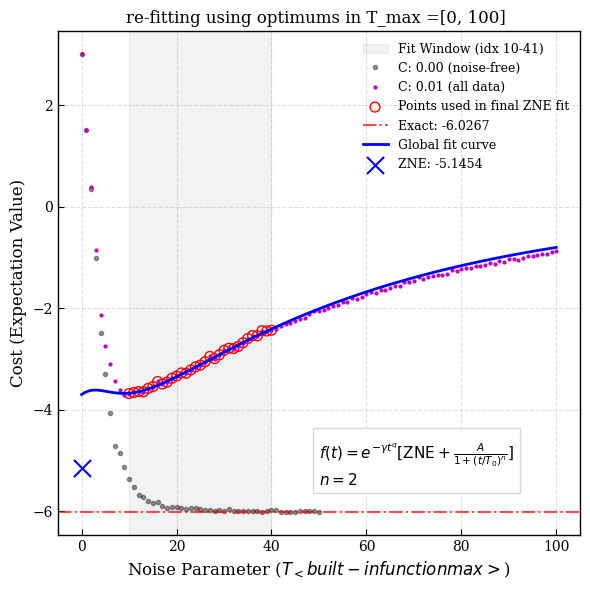

In [21]:
# =====================================================
# 1. Configuration & Parameters
# =====================================================
mask_idx = 41              # Upper bound index
start_idx = 10             # Lower bound index
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses: Using your previous fit results as the starting point
# [gamma, ZNE, A, T0]
p0 = [GAMMA_FROM_LARGE_T, ZNE_FROM_NOISY_SMALL_T, A_FROM_NOISY_SMALL_T, T0_FROM_NOISY_SMALL_T]
p0_from_entire_range = [gamma_fit, ZNE_fit, A_fit, T0_fit]
bounds = ([1e-6, -10.0, 0.0, 0], [1, 0., 200.0, 10])

# =====================================================
# 2. Data Extraction (Slicing the window)
# =====================================================
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][start_idx:mask_idx]
y_data = rec["processed"]["vqe_means"][start_idx:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][start_idx:mask_idx]

# =====================================================
# 3. Execution: Global Fit
# =====================================================
result_global = fit_f_noisy(
    t=t_data, 
    y=y_data, 
    sigma=sigma_data, 
    n=n_exponent,
    p0=p0_from_entire_range, 
    bounds=bounds, 
    method="trf", 
    ftol=1e-12, 
    xtol=1e-12, 
    gtol=1e-12,
    verbose=0
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]
gamma_fit, ZNE_fit, A_fit, T0_fit = popt

# --- Print Summary Table ---
print(f"\nFit Results for Window [{start_idx}:{mask_idx}] (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Rel. Error'}")
print("-" * 62)
params_names = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params_names):
    rel_err = np.sqrt(pcov[i,i]) / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0_from_entire_range[i]:12.4e} | {popt[i]:12.4e} | {rel_err:.2e}")

# =====================================================
# 4. Visualization
# =====================================================
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * t) * (z + a / (1.0 + (t / t0) ** n))

# Generate smooth curve for plotting
t_grid = np.linspace(0, max(noise_levels_c0_01), 400)
y_fit_curve = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# A. Highlight the "Masked" Data Range
t_min_window = rec["processed"]["t_max"][start_idx]
t_max_window = rec["processed"]["t_max"][mask_idx-1]
plt.axvspan(t_min_window, t_max_window, color='gray', alpha=0.1, label=f'Fit Window (idx {start_idx}-{mask_idx})')

# B. Plot all data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.4, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label="C: 0.01 (all data)")

# C. Highlight specific points used in this fit
plt.scatter(t_data, y_data, facecolors='none', edgecolors='red', s=50, linewidth=1, label='Points used in final ZNE fit')

# D. Plot exact solution and ZNE result
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", alpha=0.7, label=f"Exact: {EXACT_SOLUTION:.4f}")
plt.plot(t_grid, y_fit_curve, color="blue", lw=2, label="Global fit curve")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=150, zorder=5, label=f"ZNE: {ZNE_fit:.4f}")

# E. Annotation & Styling
eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.1, eq_text, transform=plt.gca().transAxes, fontsize=11, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray'))
plt.title(f"re-fitting using optimums in T_max =[0, 100] ", fontsize=12)
plt.xlabel(f"Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=9, framealpha=1)

plt.tight_layout()
plt.show()

In [22]:
lsf_fit_gamma_largeT = {
    "name": "fit_gamma_largeT",
    "model": "exp(-gamma t) * B",
    "result": result_fit_gamma_largeT,
}

lsf_fit_in_smallT = {
    "name": "fit_in_smallT",
    "model": "ZNE + A / (1 + (t/T0)^n)",
    "result": result_fit_in_smallT,
}

lsf_fit_global = {
    "name": "fit_global",
    "model": "exp(-gamma t) * (ZNE + A / (1 + (t/T0)^n))",
    "result": result_global,
}
gamma_noisy_opt = lsf_fit_global["result"]["output"]["popt"][0]
ZNE_noisy_opt = lsf_fit_global["result"]["output"]["popt"][1]
A_noisy_opt = lsf_fit_global["result"]["output"]["popt"][2]
T0_noisy_opt = lsf_fit_global["result"]["output"]["popt"][3]

print("\nFinal optimized parameters from global fit:")
print(f"  gamma: {gamma_noisy_opt:.6e}")
print(f"  ZNE  : {ZNE_noisy_opt:.6f}")
print(f"  A    : {A_noisy_opt:.6f}")
print(f"  T0   : {T0_noisy_opt:.6f}")


Final optimized parameters from global fit:
  gamma: 1.851798e-02
  ZNE  : -5.145381
  A    : 1.441737
  T0   : 10.000000


---

### Fitting $\gamma, q$ with fixed parameters (ZNE, A, T0, n)

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right]$$


Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.0042e-01 |   3.3838e-03 | 3.37e-02
     q |   8.0000e-01 |   6.0001e-01 |   9.6406e-03 | 1.61e-02


<>:107: DeprecationWarning: invalid escape sequence '\g'
<>:107: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/3136892767.py:107: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)


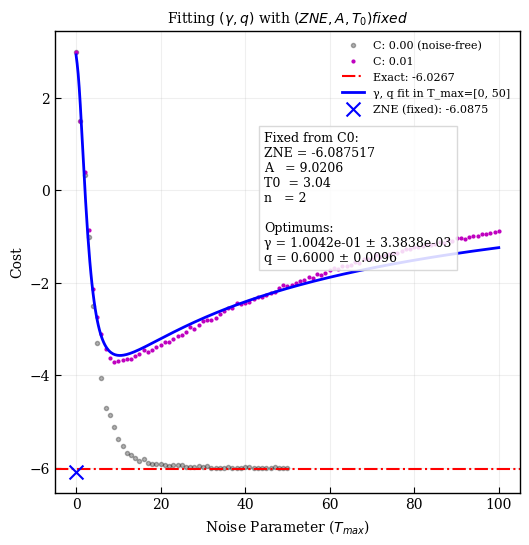

In [23]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:107: DeprecationWarning: invalid escape sequence '\g'
<>:107: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/640543766.py:107: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   9.4408e-02 |   2.0694e-03 | 2.19e-02
     q |   8.0000e-01 |   6.3662e-01 |   5.2855e-03 | 8.30e-03


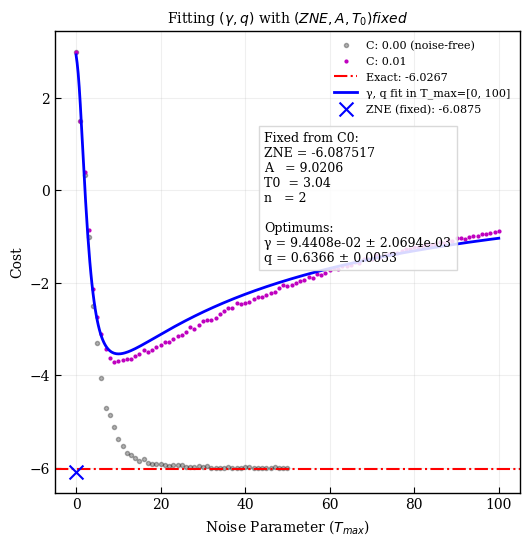

In [24]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:110: DeprecationWarning: invalid escape sequence '\g'
<>:110: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/3734806377.py:110: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.3790e-01 |   4.4817e-03 | 3.25e-02
     q |   8.0000e-01 |   5.0000e-01 |   1.0901e-02 | 2.18e-02


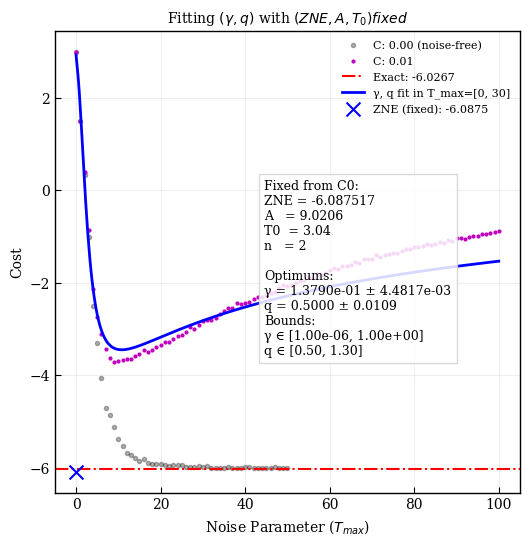

In [25]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:110: DeprecationWarning: invalid escape sequence '\g'
<>:110: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/3869428551.py:110: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.4262e-01 |   3.9282e-03 | 2.75e-02
     q |   8.0000e-01 |   5.0000e-01 |   7.9413e-03 | 1.59e-02


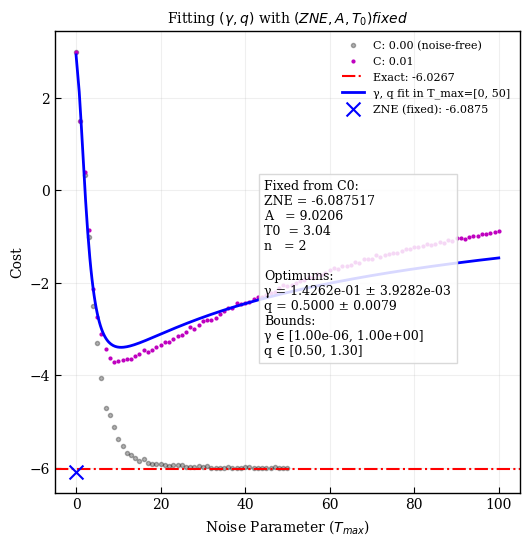

In [26]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:110: DeprecationWarning: invalid escape sequence '\g'
<>:110: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/3456849318.py:110: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   9.4408e-02 |   2.0694e-03 | 2.19e-02
     q |   8.0000e-01 |   6.3662e-01 |   5.2855e-03 | 8.30e-03


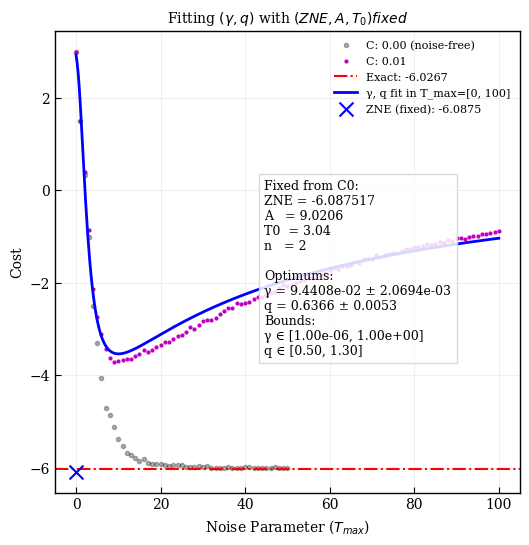

In [27]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


Dtailed pottting

<>:122: DeprecationWarning: invalid escape sequence '\g'
<>:122: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/346543183.py:122: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.3790e-01 |   4.4817e-03 | 3.25e-02
     q |   8.0000e-01 |   5.0000e-01 |   1.0901e-02 | 2.18e-02

Reduced chi-square = 33630032047.9030 (dof = 29)


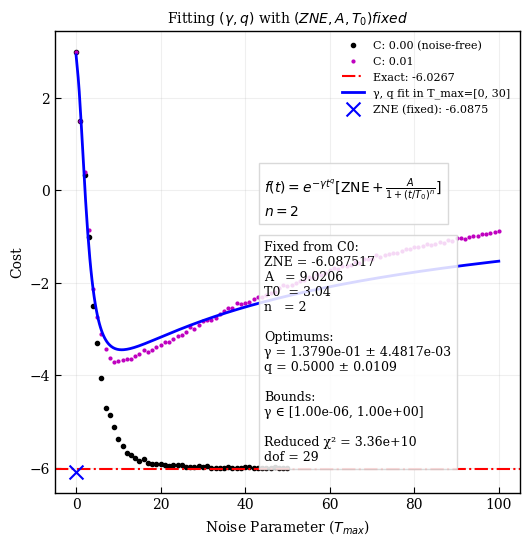

In [28]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:122: DeprecationWarning: invalid escape sequence '\g'
<>:122: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/1905598108.py:122: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.4262e-01 |   3.9282e-03 | 2.75e-02
     q |   8.0000e-01 |   5.0000e-01 |   7.9413e-03 | 1.59e-02

Reduced chi-square = 19903488355.9619 (dof = 49)


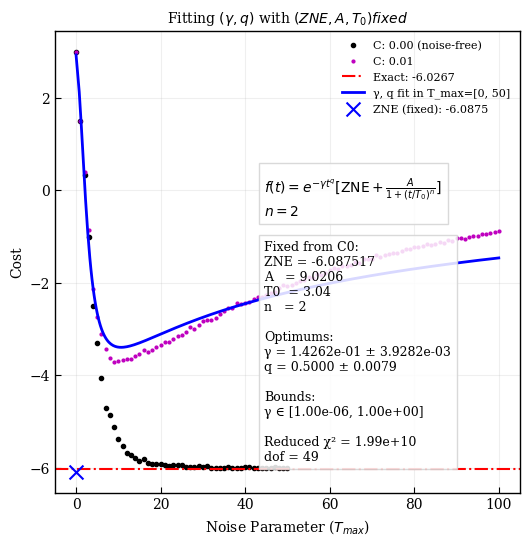

In [29]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:122: DeprecationWarning: invalid escape sequence '\g'
<>:122: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/1773505093.py:122: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   9.4408e-02 |   2.0694e-03 | 2.19e-02
     q |   8.0000e-01 |   6.3662e-01 |   5.2855e-03 | 8.30e-03

Reduced chi-square = 9851221520.7459 (dof = 99)


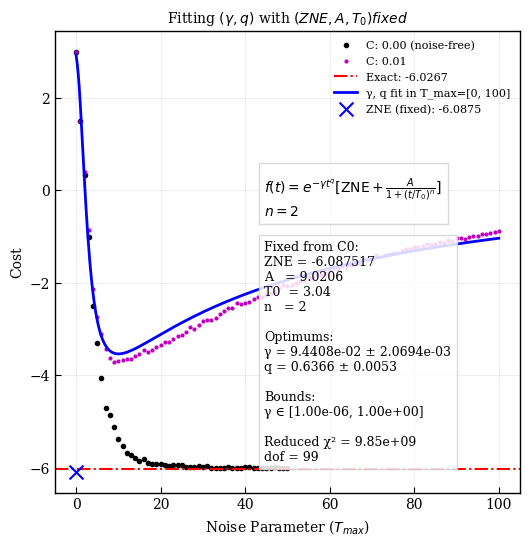

In [30]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


setting std = [1] and reduced xi

<>:123: DeprecationWarning: invalid escape sequence '\g'
<>:123: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/1682683136.py:123: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.0362e-01 |   8.4242e-02 | 8.13e-01
     q |   8.0000e-01 |   5.6897e-01 |   2.7441e-01 | 4.82e-01

Reduced chi-square = 0.0134 (dof = 29)


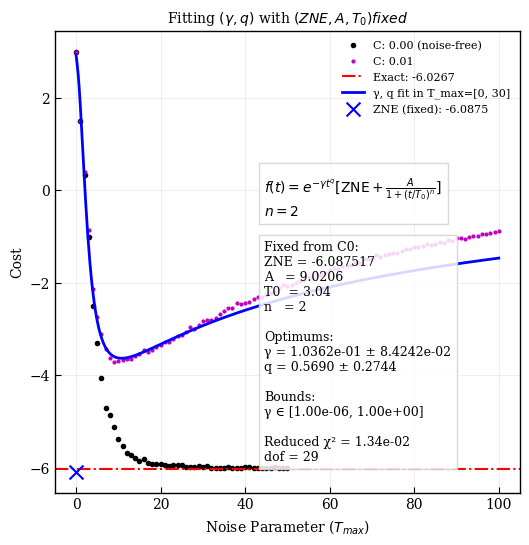

In [31]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:123: DeprecationWarning: invalid escape sequence '\g'
<>:123: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/1209643613.py:123: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   8.4262e-02 |   4.5837e-02 | 5.44e-01
     q |   8.0000e-01 |   6.4336e-01 |   1.6036e-01 | 2.49e-01

Reduced chi-square = 0.0103 (dof = 49)


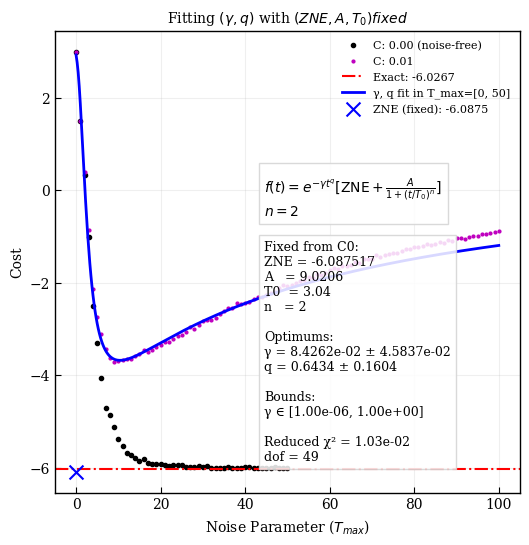

In [32]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


<>:123: DeprecationWarning: invalid escape sequence '\g'
<>:123: DeprecationWarning: invalid escape sequence '\g'
/tmp/ipykernel_14711/3598784556.py:123: DeprecationWarning: invalid escape sequence '\g'
  plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   6.4877e-02 |   2.2928e-02 | 3.53e-01
     q |   8.0000e-01 |   7.2473e-01 |   9.0470e-02 | 1.25e-01

Reduced chi-square = 0.0091 (dof = 99)


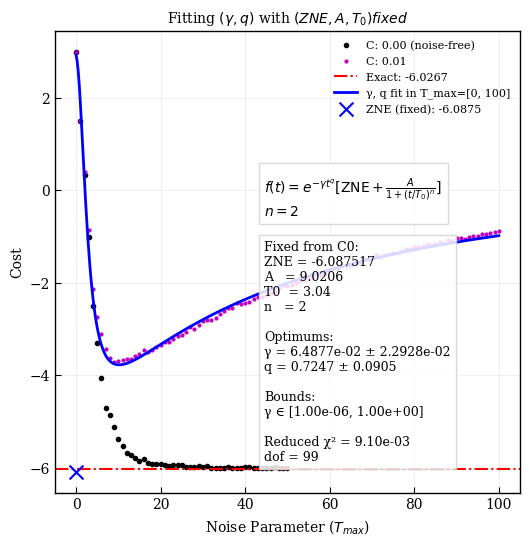

In [33]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


---

> Could you calculate:
> $$R(T_{\max}, C) := -\log \left( \frac{E_{\text{noisy}}(T_{\max}, C)}{E_{\text{ideal}}(T_{\max})} \right)$$
> 
> If the ratio of these values for different noise levels $C_1$ and $C_2$ is constant:
> $$\frac{R(T, C_1)}{R(T, C_2)} \approx \text{const}(C_1, C_2)$$
> 
> That is, if $\frac{R(T, C_1)}{R(T, C_2)}$ is almost constant with $T$, then we are seeing something physical.

In [34]:
vqe_means_by_c = {}
vqe_stds_by_c = {}
t_vals_by_c = {}

data_root = Path("data")

for c_dir in sorted(data_root.glob("c*")):
    # skip non-directories just in case
    if not c_dir.is_dir():
        continue

    # extract numeric C value: "c0.022" -> 0.022
    c = float(c_dir.name[1:])

    record = data_records[c_dir.name]["processed"]

    vqe_means_by_c[c] = record["vqe_means"]
    vqe_stds_by_c[c] = record["vqe_stds"]
    t_vals_by_c[c] = record["t_max"]


Checking

In [35]:
check_c_temp = "c0.2"
data_temp_cost = data_records[check_c_temp]["processed"]["vqe_means"]
data_temp_t_max = data_records[check_c_temp]["processed"]["t_max"]

print(f"Noise Level: {check_c_temp} | Points: {len(data_temp_cost)}")
print(f"{'T_max':<10} | {'VQE Mean (Cost)':<20}")
print("-" * 35)

# Use a loop to print row by row
for t, cost in zip(data_temp_t_max, data_temp_cost):
    print(f"{t:<10.2f} | {cost:<20.8f}")

# Cleanup
del check_c_temp, data_temp_cost, data_temp_t_max

Noise Level: c0.2 | Points: 101
T_max      | VQE Mean (Cost)     
-----------------------------------
0.00       | 3.00000007          
1.00       | 1.50536879          
2.00       | 0.39544436          
3.00       | -0.71499514         
4.00       | -1.76103049         
5.00       | -2.32538516         
6.00       | -2.55312699         
7.00       | -2.65848495         
8.00       | -2.82183826         
9.00       | -2.73483691         
10.00      | -2.59626251         
11.00      | -2.63251889         
12.00      | -2.56671757         
13.00      | -2.48431533         
14.00      | -2.43973990         
15.00      | -2.38254342         
16.00      | -2.37179632         
17.00      | -2.30702082         
18.00      | -2.25969944         
19.00      | -2.22819681         
20.00      | -2.13795226         
21.00      | -2.07950116         
22.00      | -2.06896734         
23.00      | -1.99807858         
24.00      | -1.97150207         
25.00      | -1.88255206         
26.00      | -

In [36]:
# --- Backward compatibility aliases ---

vqe_means_c0    = vqe_means_by_c[0]
vqe_stds_c0     = vqe_stds_by_c[0]
noise_levels_c0 = t_vals_by_c[0]

vqe_means_c0_01    = vqe_means_by_c[0.01]
vqe_stds_c0_01     = vqe_stds_by_c[0.01]
noise_levels_c0_01 = t_vals_by_c[0.01]

vqe_means_c0_05    = vqe_means_by_c[0.05]
vqe_stds_c0_05     = vqe_stds_by_c[0.05]
noise_levels_c0_05 = t_vals_by_c[0.05]

vqe_means_c0_1     = vqe_means_by_c[0.1]
vqe_stds_c0_1      = vqe_stds_by_c[0.1]
noise_levels_c0_1  = t_vals_by_c[0.1]

vqe_means_c0_2     = vqe_means_by_c[0.2]
vqe_stds_c0_2      = vqe_stds_by_c[0.2]
noise_levels_c0_2  = t_vals_by_c[0.2]

vqe_means_c0_5     = vqe_means_by_c[0.5]
vqe_stds_c0_5      = vqe_stds_by_c[0.5]
noise_levels_c0_5  = t_vals_by_c[0.5]


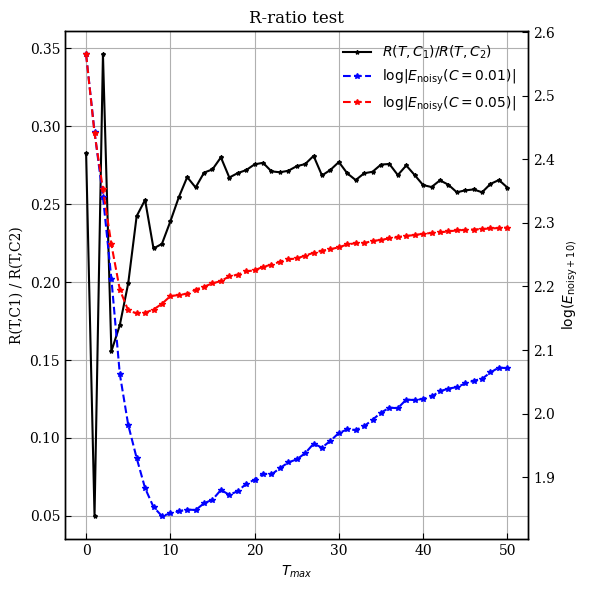

In [37]:
# --- Containers ---
R_ratio_vals = []
E_noisy_c_1 = []
E_noisy_c_2 = []

# --- Main loop (no physics changed) ---
for E_ideal, E_c1, E_c2 in zip(
        vqe_means_by_c[0],
        vqe_means_by_c[0.01],
        vqe_means_by_c[0.05]
    ):
    R1 = -np.log(E_c1 / E_ideal)
    R2 = -np.log(E_c2 / E_ideal)

    R_ratio_vals.append(R1 / R2)
    E_noisy_c_1.append(np.log((10+E_c1)))
    E_noisy_c_2.append(np.log((10+E_c2)))

# --- Convert to arrays ---
R_ratio_vals = np.array(R_ratio_vals)
E_noisy_c_1 = np.array(E_noisy_c_1)
E_noisy_c_2 = np.array(E_noisy_c_2)

# --- Fix length mismatch (CRITICAL) ---
N = len(R_ratio_vals)
T_plot = noise_levels_c0[:N]

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(6, 6))

# Left axis: R ratio
ax1.plot(
    T_plot,
    R_ratio_vals,
    '*-',
    color='black',
    markersize=3,
    label=r"$R(T,C_1)/R(T,C_2)$"
)
ax1.set_xlabel("$T_{max}$")
ax1.set_ylabel("R(T,C1) / R(T,C2)", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True)

# Right axis: log energies
ax2 = ax1.twinx()
ax2.plot(
    T_plot,
    E_noisy_c_1[:N],
    '*--',
    color='blue',
    markersize=4,
    label=r"$\log |E_{\mathrm{noisy}}(C=0.01)|$"
)

ax2.plot(
    T_plot,
    E_noisy_c_2[:N],
    '*--',
    color='red',
    markersize=4,
    label=r"$\log |E_{\mathrm{noisy}}(C=0.05)|$"
)

ax2.set_ylabel(r"$\log (E_{\mathrm{noisy} + 10)}$", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# --- Legends (both axes) ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="best")

plt.title("R-ratio test")
plt.tight_layout()
plt.show()


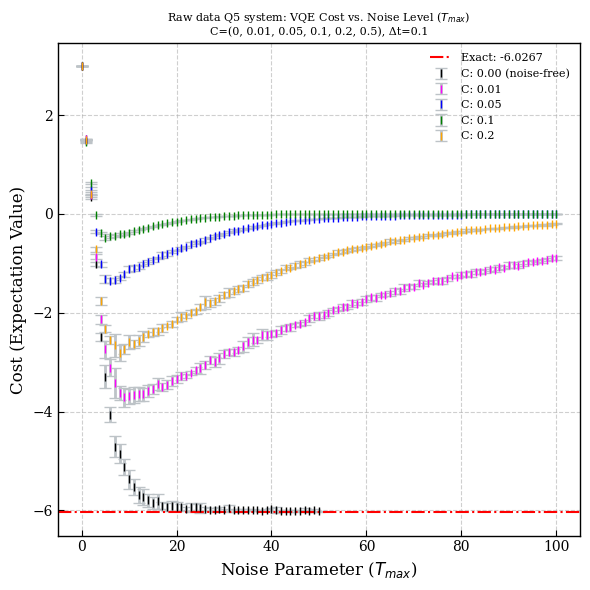

In [38]:
plt.figure(figsize=(6, 6))

# --- Noise-free ---
plt.errorbar(
    noise_levels_c0,
    vqe_means_c0,
    yerr=vqe_stds_c0,
    fmt='|',
    color='black',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.00 (noise-free)'
)

# --- C = 0.01 ---
plt.errorbar(
    noise_levels_c0_01,
    vqe_means_c0_01,
    yerr=vqe_stds_c0_01,
    fmt='|',
    color='magenta',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.01'
)

# --- C = 0.05 ---
plt.errorbar(
    noise_levels_c0_05,
    vqe_means_c0_05,
    yerr=vqe_stds_c0_05,
    fmt='|',
    color='blue',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.05'
)

# --- C = 0.1 ---
plt.errorbar(
    noise_levels_c0_1,
    vqe_means_c0_1,
    yerr=vqe_stds_c0_1,
    fmt='|',
    color='green',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.1'
)

# --- C = 0.2 ---
plt.errorbar(
    noise_levels_c0_2,
    vqe_means_c0_2,
    yerr=vqe_stds_c0_2,
    fmt='|',
    color='orange',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.2'
)


# --- Exact solution line ---
plt.axhline(
    y=EXACT_SOLUTION,
    color='red',
    linestyle='-.',
    label=f'Exact: {EXACT_SOLUTION:.4f}'
)

# --- Aesthetics ---
plt.title(
    "Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$)\n"
    "C=(0, 0.01, 0.05, 0.1, 0.2, 0.5), Δt=0.1",
    fontsize=8
)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [39]:
# Extract T
T = np.array(data_records["c0.01"]["processed"]["t_max"])

# Means
E_c001 = np.array(data_records["c0.01"]["processed"]["vqe_means"])
E_c005 = np.array(data_records["c0.05"]["processed"]["vqe_means"])
E_c01  = np.array(data_records["c0.1"]["processed"]["vqe_means"])
E_c02  = np.array(data_records["c0.2"]["processed"]["vqe_means"])

# Standard deviations
std_c001 = np.array(data_records["c0.01"]["processed"]["vqe_stds"])
std_c005 = np.array(data_records["c0.05"]["processed"]["vqe_stds"])
std_c01  = np.array(data_records["c0.1"]["processed"]["vqe_stds"])
std_c02  = np.array(data_records["c0.2"]["processed"]["vqe_stds"])

def print_delta_with_std(E1, E2, std1, label):
    print("\n==============================")
    print(label)
    print("==============================")
    for i in range(len(T)):
        delta_E = E1[i] - E2[i]
        print(
            f"T={T[i]:.4f} | "
            f"ΔE={delta_E:.6e} | "
            f"σ(C1)={std1[i]:.6e}"
        )

# Comparisons (C1 − C2, and σ of C1)
print_delta_with_std(E_c001, E_c005, std_c001, "C=0.01 − C=0.05")
print_delta_with_std(E_c005, E_c01,  std_c005, "C=0.05 − C=0.1")
print_delta_with_std(E_c01,  E_c02,  std_c01,  "C=0.1 − C=0.2")



C=0.01 − C=0.05
T=0.0000 | ΔE=1.822865e-08 | σ(C1)=6.780163e-08
T=1.0000 | ΔE=2.498258e-02 | σ(C1)=8.549300e-03
T=2.0000 | ΔE=-1.220346e-01 | σ(C1)=4.262030e-02
T=3.0000 | ΔE=-5.059148e-01 | σ(C1)=5.004688e-02
T=4.0000 | ΔE=-1.115793e+00 | σ(C1)=8.629454e-02
T=5.0000 | ΔE=-1.432069e+00 | σ(C1)=1.762276e-01
T=6.0000 | ΔE=-1.760677e+00 | σ(C1)=1.791298e-01
T=7.0000 | ΔE=-2.088425e+00 | σ(C1)=3.024837e-01
T=8.0000 | ΔE=-2.323215e+00 | σ(C1)=1.480480e-01
T=9.0000 | ΔE=-2.493267e+00 | σ(C1)=1.943022e-01
T=10.0000 | ΔE=-2.573052e+00 | σ(C1)=1.516316e-01
T=11.0000 | ΔE=-2.567809e+00 | σ(C1)=1.568470e-01
T=12.0000 | ΔE=-2.568786e+00 | σ(C1)=1.431708e-01
T=13.0000 | ΔE=-2.631140e+00 | σ(C1)=1.271287e-01
T=14.0000 | ΔE=-2.605976e+00 | σ(C1)=1.132452e-01
T=15.0000 | ΔE=-2.615080e+00 | σ(C1)=1.052322e-01
T=16.0000 | ΔE=-2.549176e+00 | σ(C1)=1.241302e-01
T=17.0000 | ΔE=-2.666059e+00 | σ(C1)=8.348572e-02
T=18.0000 | ΔE=-2.653686e+00 | σ(C1)=8.933093e-02
T=19.0000 | ΔE=-2.623945e+00 | σ(C1)=1.036259

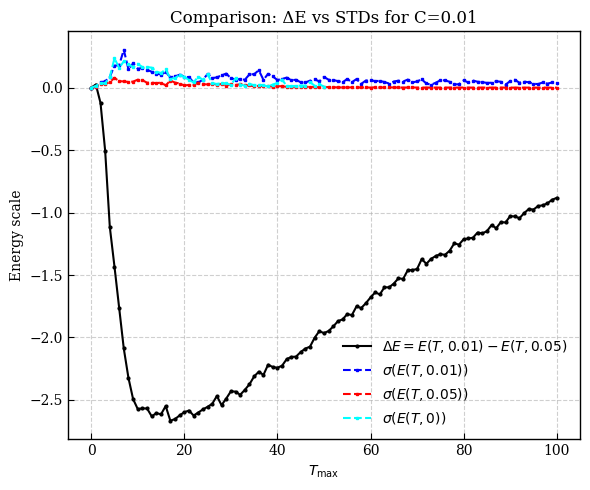

In [40]:
# --- Extract data ---
T = np.array(data_records["c0.01"]["processed"]["t_max"])

E_c001 = np.array(data_records["c0.01"]["processed"]["vqe_means"])
E_c005 = np.array(data_records["c0.05"]["processed"]["vqe_means"])
std_c001 = np.array(data_records["c0.01"]["processed"]["vqe_stds"])
std_c005 = np.array(data_records["c0.05"]["processed"]["vqe_stds"])
std_c0 = np.array(data_records["c0"]["processed"]["vqe_stds"])
T_0 = np.array(data_records["c0"]["processed"]["t_max"])
# --- Compute Delta E ---
delta_E = E_c001 - E_c005

# --- Ensure same length ---
N = min(len(T), len(delta_E), len(std_c001))
T_plot = T[:N]
delta_E = delta_E[:N]
std_c001 = std_c001[:N]

# --- Plot ---
plt.figure(figsize=(6, 5))

plt.plot(
    T_plot,
    delta_E,
    'o-',
    color='black',
    markersize=2,
    label=r'$\Delta E = E(T,0.01) - E(T,0.05)$'
)

plt.plot(
    T_plot,
    std_c001,
    's--',
    color='blue',
    markersize=2,
    label=r'$\sigma(E(T,0.01))$'
)
plt.plot(
    T_plot,
    std_c005,
    's--',
    color='red',
    markersize=2,
    label=r'$\sigma(E(T,0.05))$'
)
plt.plot(
    T_0,
    std_c0,
    's--',
    color='cyan',
    markersize=2,
    label=r'$\sigma(E(T,0))$'
)

plt.xlabel(r"$T_{\max}$")
plt.ylabel("Energy scale")
plt.title("Comparison: ΔE vs STDs for C=0.01")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


---

Polynomial fitting of 
$R(T,C)=F0(T) + C・F1(T)+ C^2 ・F2(T)+C^3・F3(T)$


In [41]:
# =========================
# User controls
# =========================
mask_start = 3
mask_end   = 50
poly_degree = 3

C_values = np.array([0.01, 0.05, 0.1, 0.2])

# =========================
# Apply masks
# =========================
E_c_raw = [
    vqe_means_c0_01[mask_start:mask_end],
    vqe_means_c0_05[mask_start:mask_end],
    vqe_means_c0_1[mask_start:mask_end],
    vqe_means_c0_2[mask_start:mask_end]
]
E_ideal = vqe_means_c0
E_ideal_cut = E_ideal[mask_start:mask_end]
T_values = noise_levels_c0_01[mask_start:mask_end]

E_c = np.array(E_c_raw)

# =========================
# Compute R(T,C)
# =========================
R = -np.log(np.abs(E_c / E_ideal_cut))

# =========================
# Polynomial fit in C
# =========================
n_T = len(T_values)
coeffs_T = np.zeros((n_T, poly_degree + 1))

for i in range(n_T):
    y = R[:, i]
    coeffs = np.polyfit(C_values, y, poly_degree)
    coeffs_T[i] = coeffs[::-1]   # [F0, F1, F2, ...]

# =========================
# Print results
# =========================
header = "T"
for k in range(poly_degree + 1):
    header += f"    F{k}(T)"
print(header)

for i, T in enumerate(T_values):
    row = f"{T:.6f}"
    for k in range(poly_degree + 1):
        row += f"    {coeffs_T[i, k]: .6e}"
    print(row)


T    F0(T)    F1(T)    F2(T)    F3(T)
3.000000     4.401211e-01    -4.056836e+01     1.337153e+03    -5.682684e+03
4.000000     3.574668e-02     9.865535e+00     2.079100e+02    -1.247286e+03
5.000000     6.990867e-02     9.334075e+00     2.191455e+02    -1.294247e+03
6.000000     1.337955e-01     1.111326e+01     2.358865e+02    -1.415944e+03
7.000000     1.423225e-01     1.569249e+01     1.987172e+02    -1.332172e+03
8.000000     8.624152e-02     1.892494e+01     1.803660e+02    -1.318061e+03
9.000000     6.252900e-02     2.511395e+01     1.004226e+02    -1.059287e+03
10.000000     7.478775e-02     2.972897e+01     5.127189e+01    -9.181327e+02
11.000000     1.272038e-01     2.757636e+01     1.011755e+02    -1.118390e+03
12.000000     1.646895e-01     2.694707e+01     1.208639e+02    -1.199077e+03
13.000000     1.495400e-01     2.906947e+01     1.078994e+02    -1.180571e+03
14.000000     1.775816e-01     2.933183e+01     1.160028e+02    -1.227312e+03
15.000000     1.890385e-01     3.

>Could you change the degree and see how the remaining square error changes depending on degree.

In [42]:
# =========================
# User controls
# =========================
mask_start = 3
mask_end   = 50
max_degree = 3

C_values = np.array([0.01, 0.05, 0.1, 0.2])

# =========================
# Apply masks
# =========================
E_c_raw = [
    vqe_means_c0_01[mask_start:mask_end],
    vqe_means_c0_05[mask_start:mask_end],
    vqe_means_c0_1[mask_start:mask_end],
    vqe_means_c0_2[mask_start:mask_end]
]

E_ideal_cut = vqe_means_c0[mask_start:mask_end]

E_c = np.array(E_c_raw)  # shape (nC, nT)

# =========================
# Compute R(T,C)
# =========================
R = -np.log(np.abs(E_c / E_ideal_cut))

# =========================
# Degree scan
# =========================
print("Polynomial degree vs residual error")
print("-----------------------------------")

for deg in range(1, max_degree + 1):
    rss_total = 0.0

    for t_idx in range(R.shape[1]):
        y = R[:, t_idx]

        coeffs = np.polyfit(C_values, y, deg)
        y_fit = np.polyval(coeffs, C_values)

        residuals = y - y_fit
        rss_total += np.sum(residuals**2)

    print(f"Degree {deg}: RSS = {rss_total:.6e}")


Polynomial degree vs residual error
-----------------------------------
Degree 1: RSS = 4.879212e+02
Degree 2: RSS = 1.830214e+01
Degree 3: RSS = 2.675059e-27


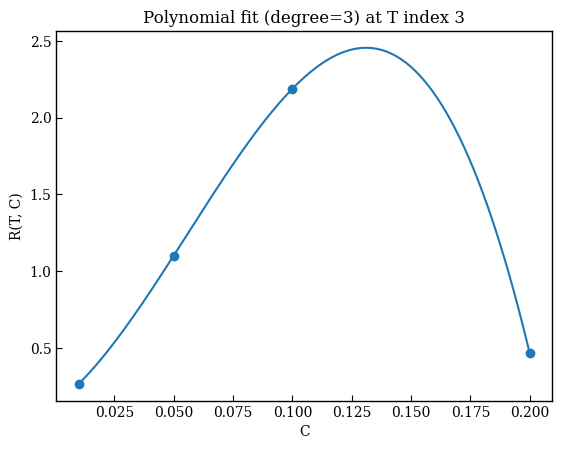

In [43]:
# =========================
# User choice
# =========================
poly_degree = 3
t_index = 3   # choose which T to visualize

# =========================
# Data at selected T
# =========================
y = R[:, t_index]          # R vs C at fixed T
C_vals = C_values

# Polynomial fit
coeffs = np.polyfit(C_vals, y, poly_degree)

# Smooth curve for plotting
C_smooth = np.linspace(min(C_vals), max(C_vals), 200)
y_fit = np.polyval(coeffs, C_smooth)

# =========================
# Plot
# =========================
plt.figure()
plt.scatter(C_vals, y)
plt.plot(C_smooth, y_fit)

plt.xlabel("C")
plt.ylabel("R(T, C)")
plt.title(f"Polynomial fit (degree={poly_degree}) at T index {t_index}")
plt.show()


---

Richardson ZNE

In [44]:
# 1. Apply the mask: T between 3 and 20
# (Assuming vqe_means_c0_01 and noise_levels_c0_01 are defined in your environment)
noise_arr = np.array(noise_levels_c0_01)
means_arr = np.array(vqe_means_c0_01)

mask = (noise_arr >= 50) & (noise_arr <= 70)
masked_T = noise_arr[mask]
masked_means = means_arr[mask]

window_size = 3
print(f"C = 0.01 | T range: {masked_T[0]:.2f} to {masked_T[-1]:.2f} | Total points: {len(masked_T)}\n")
print(f"{'Window':<10} | {'Input T [points used]':<45} | {'ZNE Value':<12}")
print("-" * 85)

# 3. Slide the window and apply ZNE
results = []

for i in range(len(masked_T) - window_size + 1):
    # Extract current window
    current_T = masked_T[i : i + window_size]
    current_means = masked_means[i : i + window_size]
    
    try:
        # Perform ZNE using your logic from riczne.py
        # Note: RichardsonZne sorts the noise internally
        res = RichardsonZne(list(current_means), list(current_T))
        zne_val = res['extrapolated_val']
        
        # Formatting for display
        t_list_str = str([round(t, 2) for t in current_T])
        window_label = f"{i} to {i + window_size - 1}"
       
        print(f"{window_label:<10} | {t_list_str:<45} | {zne_val:<12.6f}")
        
        results.append(res)
        
    except Exception as e:
        print(f"Error in window {i}: {e}")

C = 0.01 | T range: 50.00 to 70.00 | Total points: 21

Window     | Input T [points used]                         | ZNE Value   
-------------------------------------------------------------------------------------
0 to 2     | [50, 51, 52]                                  | 19.905687   
1 to 3     | [51, 52, 53]                                  | -2.151046   
2 to 4     | [52, 53, 54]                                  | -34.370123  
3 to 5     | [53, 54, 55]                                  | 33.306047   
4 to 6     | [54, 55, 56]                                  | -78.780169  
5 to 7     | [55, 56, 57]                                  | 113.411789  
6 to 8     | [56, 57, 58]                                  | -136.481922 
7 to 9     | [57, 58, 59]                                  | 86.384841   
8 to 10    | [58, 59, 60]                                  | 0.602875    
9 to 11    | [59, 60, 61]                                  | -9.290986   
10 to 12   | [60, 61, 62]                    

In [45]:
# 1. Apply the mask: T between 3 and 20
# (Assuming vqe_means_c0_01 and noise_levels_c0_01 are defined in your environment)
noise_arr = np.array(noise_levels_c0_05)
means_arr = np.array(vqe_means_c0_05)

mask = (noise_arr >= 3) & (noise_arr <= 20)
masked_T = noise_arr[mask]
masked_means = means_arr[mask]

window_size = 2
print(f"C = 0.05 | T range: {masked_T[0]:.2f} to {masked_T[-1]:.2f} | Total points: {len(masked_T)}\n")
print(f"{'Window':<10} | {'Input T [points used]':<45} | {'ZNE Value':<12}")
print("-" * 85)

# 3. Slide the window and apply ZNE
results = []

for i in range(len(masked_T) - window_size + 1):
    # Extract current window
    current_T = masked_T[i : i + window_size]
    current_means = masked_means[i : i + window_size]
    
    try:
        # Perform ZNE using your logic from riczne.py
        # Note: RichardsonZne sorts the noise internally
        res = RichardsonZne(list(current_means), list(current_T))
        zne_val = res['extrapolated_val']
        
        # Formatting for display
        t_list_str = str([round(t, 2) for t in current_T])
        window_label = f"{i} to {i + window_size - 1}"
       
        print(f"{window_label:<10} | {t_list_str:<45} | {zne_val:<12.6f}")
        
        results.append(res)
        
    except Exception as e:
        print(f"Error in window {i}: {e}")

C = 0.05 | T range: 3.00 to 20.00 | Total points: 18

Window     | Input T [points used]                         | ZNE Value   
-------------------------------------------------------------------------------------
0 to 1     | [3, 4]                                        | 1.630592    
1 to 2     | [4, 5]                                        | 0.137686    
2 to 3     | [5, 6]                                        | -1.112009   
3 to 4     | [6, 7]                                        | -1.404243   
4 to 5     | [7, 8]                                        | -1.640387   
5 to 6     | [8, 9]                                        | -1.930612   
6 to 7     | [9, 10]                                       | -2.174377   
7 to 8     | [10, 11]                                      | -1.273438   
8 to 9     | [11, 12]                                      | -1.296216   
9 to 10    | [12, 13]                                      | -1.765290   
10 to 11   | [13, 14]                         

---

Unifromly sampled
$C= [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.200]$

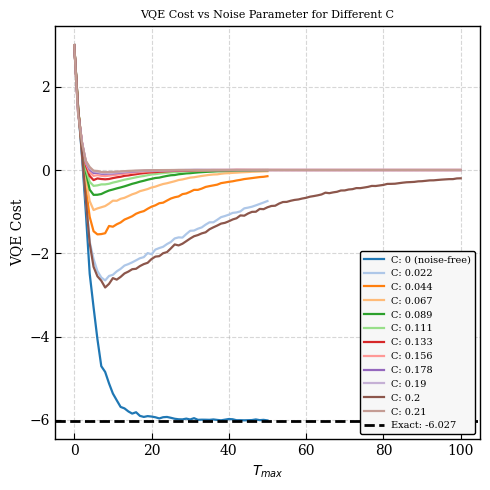

In [46]:
plt.figure(figsize=(5, 5))

# Filter for the specific target values of C
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
               0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
Cs = [c for c in target_vals if c in vqe_means_by_c]

# Use tab20 for >10 curves (high contrast, discrete)
colors = plt.cm.tab20.colors[:len(Cs)]

for c, color in zip(Cs, colors):
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    plt.plot(
        t_vals_by_c[c],
        vqe_means_by_c[c],
        linewidth=1.6,
        alpha=1.0,
        color=color,
        label=label
    )

# Exact line (black is better than red for papers)
plt.axhline(
    y=EXACT_SOLUTION,
    linestyle='--',
    linewidth=2.0,
    color='black',
    label=f'Exact: {EXACT_SOLUTION:.3f}'
)

plt.xlabel("$T_{max}$")
plt.ylabel("VQE Cost")
plt.title("VQE Cost vs Noise Parameter for Different C", fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)

plt.tight_layout()
plt.show()


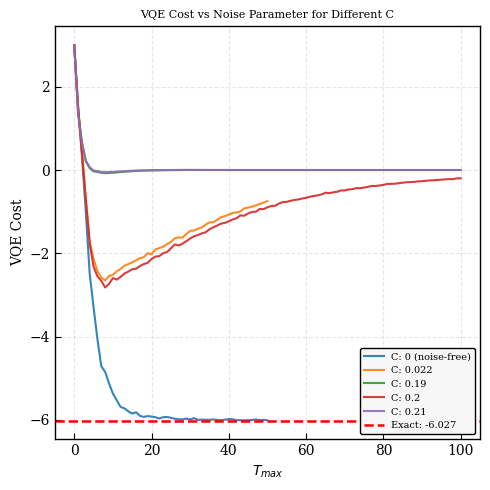

In [47]:
# --- Fixed Mapping for VQE Cost vs Tmax ---
plt.figure(figsize=(5, 5))

# Use strict matching to find the actual keys in the dictionary
target_summary = [0.0, 0.022, 0.190, 0.2, 0.210]
Cs_verified = []
for val in target_summary:
    match = [k for k in vqe_means_by_c.keys() if np.isclose(k, val, atol=1e-5)]
    if match: Cs_verified.append(match[0])

# Colors from Inferno
colors = cm.tab10.colors[:len(Cs_verified)]

for c, color in zip(Cs_verified, colors):
    # Using target_summary value for clean labels
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    plt.plot(
        t_vals_by_c[c],
        vqe_means_by_c[c],
        linewidth=1.5,
        alpha=0.9,
        color=color,
        label=label
    )

plt.axhline(y=EXACT_SOLUTION, linestyle='--', linewidth=1.8, color='red', label=f'Exact: {EXACT_SOLUTION:.3f}')

plt.xlabel("$T_{max}$")
plt.ylabel("VQE Cost")
plt.title("VQE Cost vs Noise Parameter for Different C", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5, color='#d1d1d1') # Fixed visibility

plt.legend(loc="lower right", fontsize=7, frameon=True, edgecolor='black', facecolor='#f7f7f7', framealpha=1)
plt.tight_layout()
plt.show()

---

#### Polynomial Fitting of $R(T, C)$

Since $R(T, C=0) = 0$ for all $T$,  
the constant term must vanish in the polynomial expansion.

Therefore, we impose $F_0(T) = 0$, and write

$$
R(T, C) = C\,F_1(T) + C^2 F_2(T) + C^3 F_3(T) + C^4 F_4(T) + \cdots
$$

This enforces the physical constraint that the noise response
vanishes when $C = 0$.


In [48]:
degrees = [1, 2, 3]

fix_T   = 3
T_start = 3
T_end   = 50

# --------------------------------------------------
# 1. Check that fix_T is inside the selected range
# --------------------------------------------------
if fix_T < T_start or fix_T > T_end:
    raise ValueError("fix_T is outside selected T range")

# --------------------------------------------------
# 2. Select energy values in T range
# --------------------------------------------------
selected_vqe_E = {}

for C, full_energy_array in vqe_means_by_c.items():
    selected_vqe_E[C] = full_energy_array[T_start:T_end + 1]

# --------------------------------------------------
# 3. Convert fix_T to local index
# --------------------------------------------------
local_T = fix_T - T_start
# --------------------------------------------------
# 4. Compute R(C, fix_T)
# --------------------------------------------------
E_ideal = selected_vqe_E[0.0][local_T]

C_values = []
R_values = []

for C, energy_array in selected_vqe_E.items():

    E_noisy = energy_array[local_T]
    ratio = E_noisy / E_ideal

    if ratio > 0:
        C_values.append(C)
        R_values.append(-np.log(ratio))


C_values = np.array(C_values)
R_values = np.array(R_values)
# --------------------------------------------------
# 5. Remove C = 0 before fitting
# --------------------------------------------------
fit_mask = C_values > 0

C_fit = C_values[fit_mask]
R_fit = R_values[fit_mask]
# --------------------------------------------------
# 6. Polynomial fitting (no constant term)
# --------------------------------------------------
fitted_coefficients = {}

for degree in degrees:

    if len(C_fit) <= degree:
        continue

    X = np.column_stack([
        C_fit**k for k in range(1, degree + 1)
    ])

    coeffs, _, _, _ = np.linalg.lstsq(X, R_fit, rcond=None)

    fitted_coefficients[degree] = coeffs
# --------------------------------------------------
# 7. Print results
# --------------------------------------------------
for degree, coeffs in fitted_coefficients.items():

    print(f"\nDegree {degree} fit at T = {fix_T}")

    for k, value in enumerate(coeffs, start=1):
        print(f"F{k}(T={fix_T}) = {value:.6e}")



Degree 1 fit at T = 3
F1(T=3) = 1.410072e+01

Degree 2 fit at T = 3
F1(T=3) = 4.798220e+01
F2(T=3) = -2.233795e+02

Degree 3 fit at T = 3
F1(T=3) = -1.612367e+01
F2(T=3) = 9.771890e+02
F3(T=3) = -4.437050e+03


Ratio sign checking for a given $T$

C = 0.0, ratio = 1.0
C = 0.022, ratio = 0.6793398483552094
C = 0.044, ratio = 0.4227118748337867
C = 0.067, ratio = 0.21513809394257027
C = 0.089, ratio = 0.04802341385972439
C = 0.111, ratio = -0.032366885075752305
C = 0.133, ratio = -0.11287415630586256
C = 0.156, ratio = -0.1652904439159109
C = 0.178, ratio = -0.19517608683420246
C = 0.19, ratio = -0.20701970992292068
C = 0.2, ratio = 0.7039301863454583
C = 0.21, ratio = -0.2169683492076825


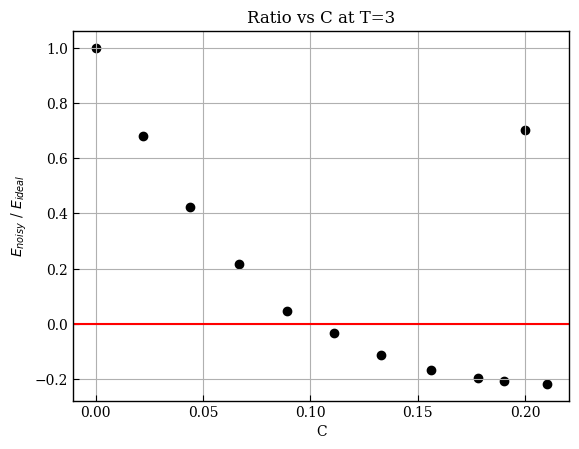

In [49]:
T = 3
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
E_ideal = vqe_means_by_c[0.0][T]
C_list = []
ratio_list = []
for c in target_vals:

    if c in vqe_means_by_c:

        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal

        print(f"C = {c}, ratio = {ratio}")

        C_list.append(c)
        ratio_list.append(ratio)

C_array = np.array(C_list)
ratio_array = np.array(ratio_list)

plt.figure()
plt.scatter(C_array, ratio_array, color="black")
plt.axhline(y=0, color="red")   # horizontal zero line
plt.xlabel("C")
plt.ylabel("$E_{noisy}$ / $E_{ideal}$")
plt.title(f"Ratio vs C at T={T}")
plt.grid(True)
plt.show()


Ratio E_noise(T=5, C=0.0) / E_ideal(T=5) = 1.0
Ratio E_noise(T=5, C=0.022) / E_ideal(T=5) = 0.6489928285548111
Ratio E_noise(T=5, C=0.044) / E_ideal(T=5) = 0.4462570898501802
Ratio E_noise(T=5, C=0.067) / E_ideal(T=5) = 0.2917053028064383
Ratio E_noise(T=5, C=0.089) / E_ideal(T=5) = 0.18107090229680564
Ratio E_noise(T=5, C=0.111) / E_ideal(T=5) = 0.11562950153657414
Ratio E_noise(T=5, C=0.133) / E_ideal(T=5) = 0.07342605792364516
Ratio E_noise(T=5, C=0.156) / E_ideal(T=5) = 0.042789844076760654
Ratio E_noise(T=5, C=0.178) / E_ideal(T=5) = 0.021794891059236234
Ratio E_noise(T=5, C=0.19) / E_ideal(T=5) = 0.01035856417387301
Ratio E_noise(T=5, C=0.2) / E_ideal(T=5) = 0.7056974507032857
Ratio E_noise(T=5, C=0.21) / E_ideal(T=5) = 0.0046350444698395835
************************
F1(T=5) = 1.672781e+01
************************
F2(T=5) = 5.380167e+01
************************
F3(T=5) = -2.368555e+02


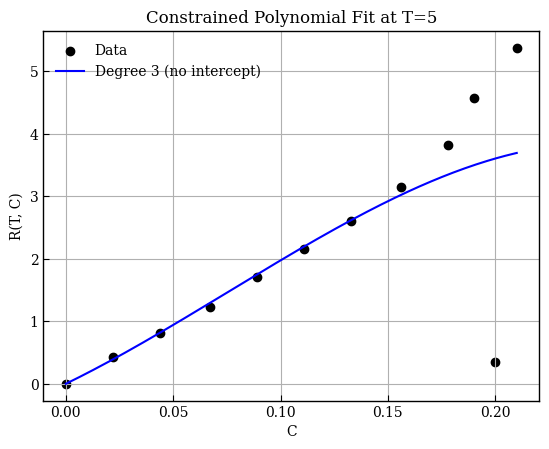

In [50]:
T = 5
T_min = 3
T_max = 50
degrees = 3
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]

if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

def compute_R(c):
    """Return R(T, c) = -log(E_noisy / E_ideal)."""

    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal

    print(f"Ratio E_noise(T={T}, C={c}) / E_ideal(T={T}) = {ratio}")
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        print("Log -ve val error")
        print("T =", T)
        print("C =", c)
        print("E_noisy =", E_noisy)
        print("E_ideal =", E_ideal)
        print("ratio =", ratio)
        print("-----------------------------")
        return np.nan

# ======================
# Select C values present in data
# ======================
C_list = []

for c in target_vals:
    if c in vqe_means_by_c:
        C_list.append(c)

C = np.array(C_list)

# Compute R values
R_list = []

for c in C:
    R_list.append(compute_R(c))

R = np.array(R_list)

# ======================
# Use valid data and exclude C=0
# ======================
mask = (C > 0) & np.isfinite(R)

C_fit = C[mask]
R_fit = R[mask]

# ======================
# Build design matrix (no constant term)
# ======================
X_columns = []

for k in range(1, degrees + 1):
    X_columns.append(C_fit ** k)

X = np.column_stack(X_columns)

# ======================
# Least squares solve
# ======================
F, residuals, rank, singular_values = np.linalg.lstsq(X, R_fit, rcond=None)

# ======================
# Print coefficients
# ======================
for k in range(1, degrees + 1):
    print("************************")
    print(f"F{k}(T={T}) = {F[k-1]:.6e}")

# ======================
# Plot
# ======================
plt.figure()

plt.scatter(C, R, color="black", label="Data")

C_smooth = np.linspace(0, C.max(), 200)
R_smooth = np.zeros_like(C_smooth)

for k in range(1, degrees + 1):
    R_smooth = R_smooth + F[k-1] * (C_smooth ** k)

plt.plot(C_smooth, R_smooth, color="blue",
         label=f"Degree {degrees} (no intercept)")

plt.xlabel("C")
plt.ylabel("R(T, C)")
plt.title(f"Constrained Polynomial Fit at T={T}")
plt.grid(True)
plt.legend()
plt.show()

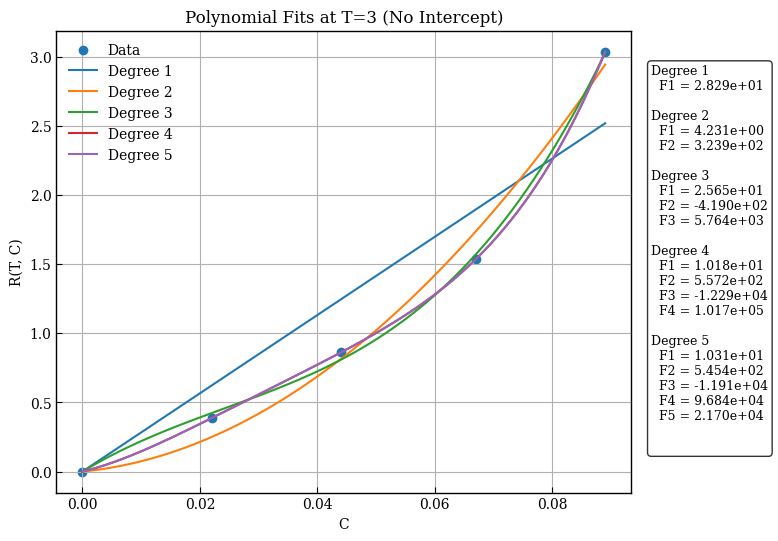

In [51]:
# ======================
# User settings
# ======================
T = 3
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]
if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        return np.nan

# ======================
# Collect valid C values
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

# Exclude C=0 and invalid values
mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)  # leave space for textbox

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300)

coeff_text = ""  # store coefficient summary text

for deg in degrees:

    # Build design matrix (no intercept)
    X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

    # Least squares
    F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients in text
    coeff_text += f"Degree {deg}\n"
    for k in range(deg):
        coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
    R_smooth = X_smooth @ F

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()


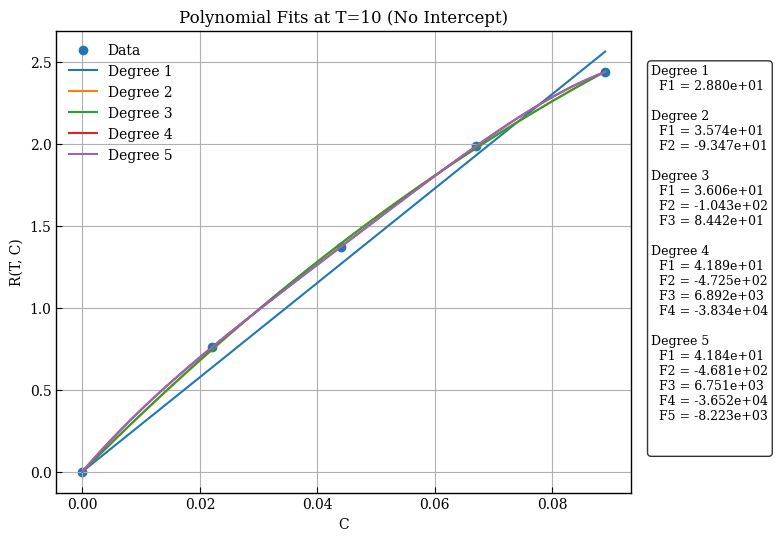

In [52]:
# ======================
# User settings
# ======================
T = 10
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]
if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        return np.nan

# ======================
# Collect valid C values
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

# Exclude C=0 and invalid values
mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)  # leave space for textbox

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300)

coeff_text = ""  # store coefficient summary text

for deg in degrees:

    # Build design matrix (no intercept)
    X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

    # Least squares
    F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients in text
    coeff_text += f"Degree {deg}\n"
    for k in range(deg):
        coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
    R_smooth = X_smooth @ F

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()


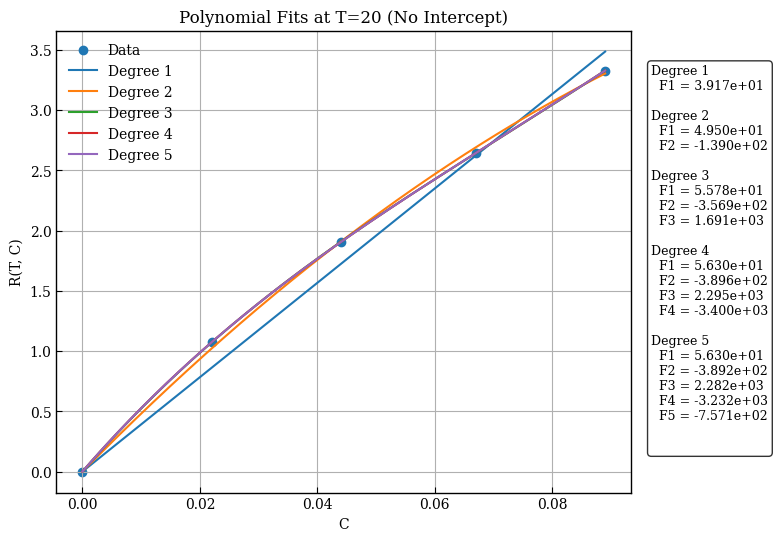

In [53]:
# ======================
# User settings
# ======================
T = 20
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]
if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        return np.nan

# ======================
# Collect valid C values
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

# Exclude C=0 and invalid values
mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)  # leave space for textbox

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300)

coeff_text = ""  # store coefficient summary text

for deg in degrees:

    # Build design matrix (no intercept)
    X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

    # Least squares
    F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients in text
    coeff_text += f"Degree {deg}\n"
    for k in range(deg):
        coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
    R_smooth = X_smooth @ F

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()


Using scikit-learn

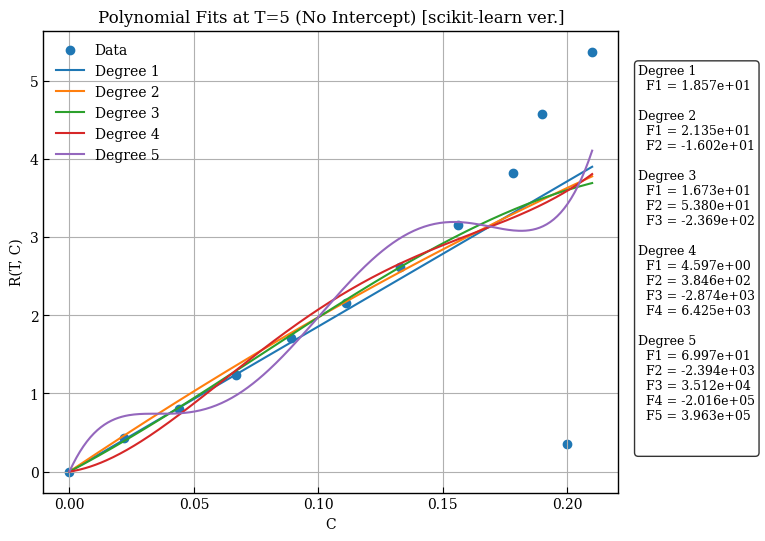

In [54]:
T = 5
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]

if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    return -np.log(ratio) if ratio > 0 else np.nan

# ======================
# Collect valid data
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# Reshape for sklearn
C_fit_reshaped = C_fit.reshape(-1, 1)

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300).reshape(-1, 1)

coeff_text = ""

# ======================
# Loop over degrees
# ======================
for deg in degrees:

    # Generate polynomial features (NO bias term)
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly = poly.fit_transform(C_fit_reshaped)

    # Linear regression with NO intercept
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, R_fit)

    F = model.coef_

    # Store coefficients
    coeff_text += f"Degree {deg}\n"
    for i, coef in enumerate(F):
        coeff_text += f"  F{i+1} = {coef:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = poly.transform(C_smooth)
    R_smooth = model.predict(X_smooth)

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept) [scikit-learn ver.]")
ax.grid(True)
ax.legend()

# ======================
# Coefficient textbox
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

> OK, So, Degree 2 may be enough. Let us assume Degree 2 and reconstruct F1(t) and F2(t). We further try to fit F1(T) and F2(T)
> Then, we can approximately get a form of function R(T,C)

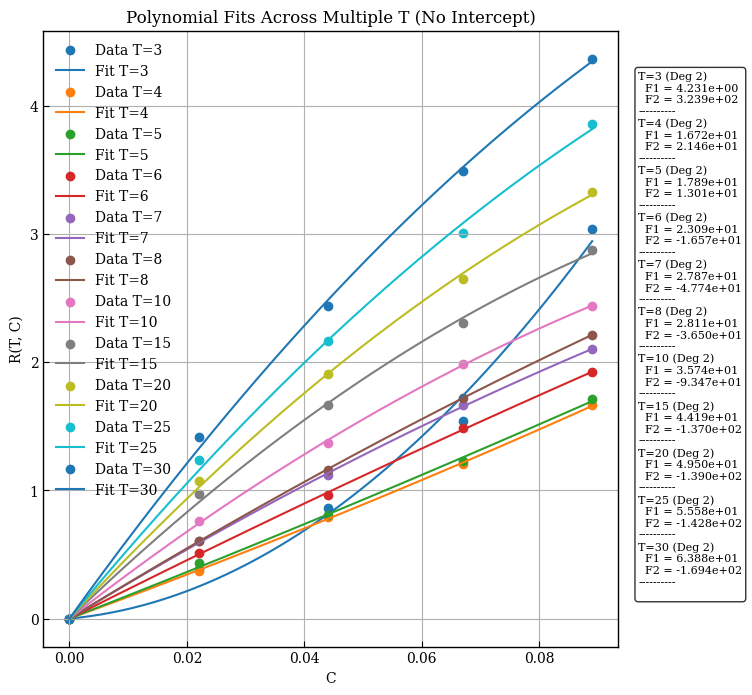

In [55]:
# ======================
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30] # List of T values to iterate through
T_min = 3
T_max = 50
degrees = [2] # Fixed degree

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)  # leave space for textbox

coeff_text = ""  # store coefficient summary text for all T

for T in T_list:
    if T < T_min or T > T_max:
        print(f"Skipping T={T}: outside range")
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    # ======================
    # Compute R(T, C)
    # ======================
    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        
        if ratio > 0:
            return -np.log(ratio)
        else:
            return np.nan

    # ======================
    # Collect valid C values
    # ======================
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([compute_R(c) for c in C])

    # Exclude C=0 and invalid values
    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    ax.scatter(C, R, label=f"Data T={T}")

    C_smooth = np.linspace(0, C.max(), 300)

    for deg in degrees:
        # Build design matrix (no intercept)
        X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

        # Least squares
        F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

        # Store coefficients in text
        coeff_text += f"T={T} (Deg {deg})\n"
        for k in range(deg):
            coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
        coeff_text += "-"*10 + "\n"

        # Smooth curve
        X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
        R_smooth = X_smooth @ F

        ax.plot(C_smooth, R_smooth, label=f"Fit T={T}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

> T=3 looks anomouls too.
> let us remove T=3.
> By using T>3, let us implement polynomial fitting F1(T) and F2(T) (edited)

Skipping T=3: outside range


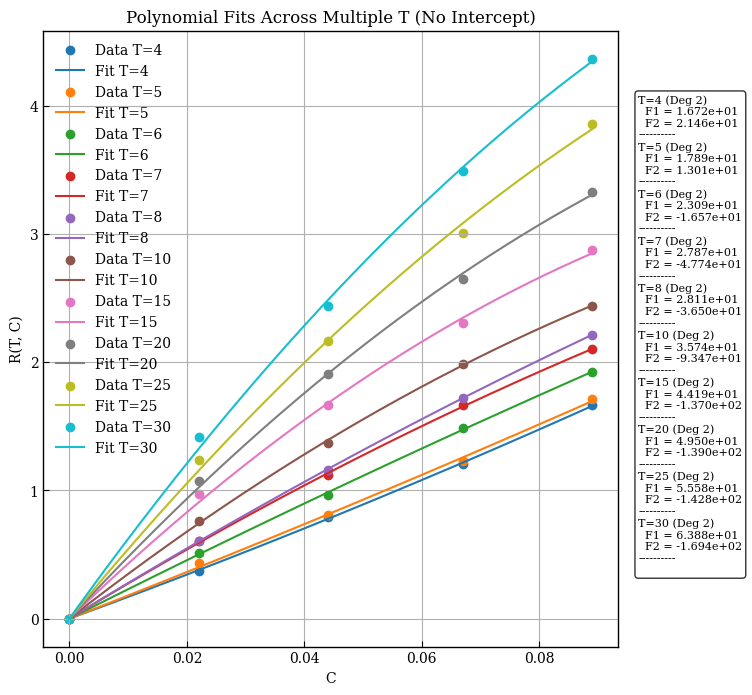

In [56]:
# ======================
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30] # List of T values to iterate through
T_min = 4
T_max = 50
degrees = [2] # Fixed degree

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)  # leave space for textbox

coeff_text = ""  # store coefficient summary text for all T

for T in T_list:
    if T < T_min or T > T_max:
        print(f"Skipping T={T}: outside range")
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    # ======================
    # Compute R(T, C)
    # ======================
    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        
        if ratio > 0:
            return -np.log(ratio)
        else:
            return np.nan

    # ======================
    # Collect valid C values
    # ======================
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([compute_R(c) for c in C])

    # Exclude C=0 and invalid values
    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    ax.scatter(C, R, label=f"Data T={T}")

    C_smooth = np.linspace(0, C.max(), 300)

    for deg in degrees:
        # Build design matrix (no intercept)
        X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

        # Least squares
        F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

        # Store coefficients in text
        coeff_text += f"T={T} (Deg {deg})\n"
        for k in range(deg):
            coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
        coeff_text += "-"*10 + "\n"

        # Smooth curve
        X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
        R_smooth = X_smooth @ F

        ax.plot(C_smooth, R_smooth, label=f"Fit T={T}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

> From these data, you can further fit:
> 
> $$F_1(T) = F_{10} + F_{11}T + F_{12}T^2$$
> $$F_2(T) = F_{20} + F_{21}T + F_{22}T^2$$
> 
> and find the coefficients $F_{10}, F_{11}, F_{12}, F_{20}, F_{21}, \text{and } F_{22}$.
> 
> I would like you to plot $F_1(T)$ and $F_2(T)$ where:
> * **Plot 1:** y-axis is $F_1(T)$ and x-axis is $T$.
> * **Plot 2:** y-axis is $F_2(T)$ and x-axis is $T$.
>
>

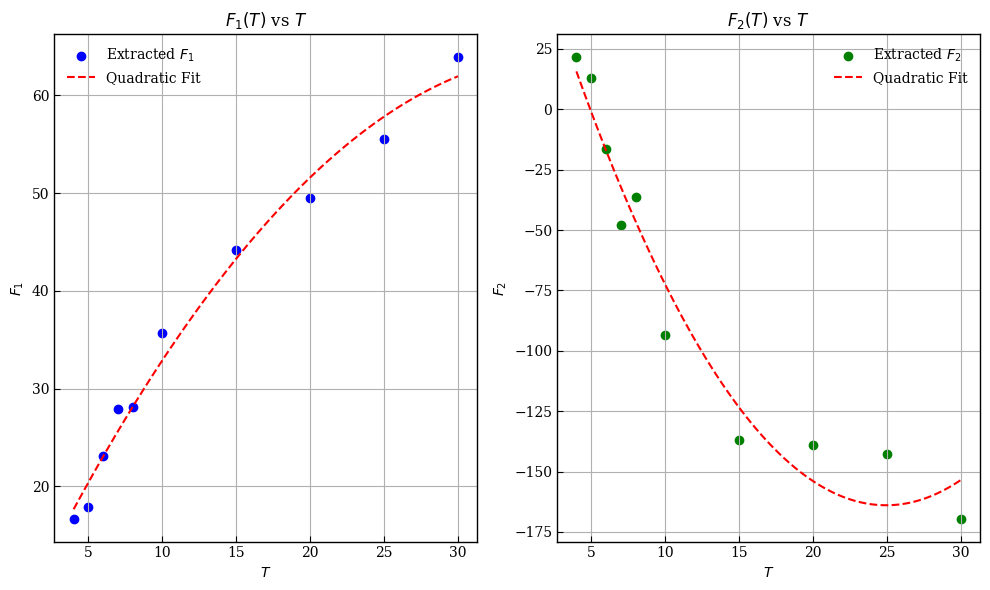

F1 coefficients: F10=5.8391e+00, F11=3.1243e+00, F12=-4.1792e-02
F2 coefficients: F20=9.0816e+01, F21=-2.0422e+01, F22=4.0929e-01


In [57]:
# ======================
# User settings
# ======================
T_list = [4, 5, 6, 7, 8, 10, 15, 20, 25, 30]
T_min = 4
T_max = 50
degree = 2 # Degree for R(C) fit
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# Data structures to store coefficients for the secondary fit
F1_list = []
F2_list = []
valid_T = []

# ======================
# First Stage: Fit R(C) for each T
# ======================
for T in T_list:
    if T < T_min or T > T_max:
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        return -np.log(ratio) if ratio > 0 else np.nan

    C_list = np.array([c for c in target_vals if c in vqe_means_by_c])
    R = np.array([compute_R(c) for c in C_list])

    mask = (C_list > 0) & np.isfinite(R)
    C_fit, R_fit = C_list[mask], R[mask]

    # Least squares for R = F1*C + F2*C^2 (No intercept)
    X = np.vander(C_fit, N=degree+1, increasing=True)[:, 1:]
    F, _, _, _ = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients
    valid_T.append(T)
    F1_list.append(F[0])
    F2_list.append(F[1])

# Convert to numpy arrays
valid_T = np.array(valid_T)
F1_vals = np.array(F1_list)
F2_vals = np.array(F2_list)

# ======================
# Second Stage: Fit F1(T) and F2(T)
# F(T) = F_0 + F_1*T + F_2*T^2
# ======================
# np.polyfit returns coefficients in descending order: [F_i2, F_i1, F_i0]
coeffs_F1 = np.polyfit(valid_T, F1_vals, 2)
F12, F11, F10 = coeffs_F1

coeffs_F2 = np.polyfit(valid_T, F2_vals, 2)
F22, F21, F20 = coeffs_F2

# ======================
# Plotting F1(T) and F2(T)
# ======================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
T_smooth = np.linspace(valid_T.min(), valid_T.max(), 100)

# F1(T) Plot
ax1.scatter(valid_T, F1_vals, color='blue', label='Extracted $F_1$')
ax1.plot(T_smooth, np.polyval(coeffs_F1, T_smooth), 'r--', label='Quadratic Fit')
ax1.set_title('$F_1(T)$ vs $T$')
ax1.set_xlabel('$T$')
ax1.set_ylabel('$F_1$')
ax1.legend()
ax1.grid(True)

# F2(T) Plot
ax2.scatter(valid_T, F2_vals, color='green', label='Extracted $F_2$')
ax2.plot(T_smooth, np.polyval(coeffs_F2, T_smooth), 'r--', label='Quadratic Fit')
ax2.set_title('$F_2(T)$ vs $T$')
ax2.set_xlabel('$T$')
ax2.set_ylabel('$F_2$')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ======================
# Output Coefficients
# ======================
print(f"F1 coefficients: F10={F10:.4e}, F11={F11:.4e}, F12={F12:.4e}")
print(f"F2 coefficients: F20={F20:.4e}, F21={F21:.4e}, F22={F22:.4e}")

Skipping T=3: outside range


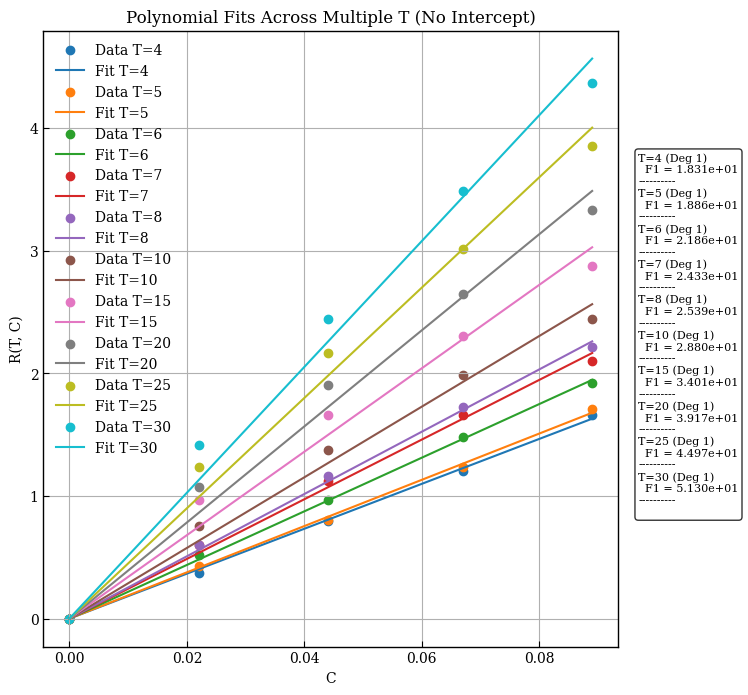

In [58]:
# ======================# 4. CONSTRUCT TEXT OUTPUT
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30] # List of T values to iterate through
T_min = 4
T_max = 50
degrees = [1] # Fixed degree

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)  # leave space for textbox

coeff_text = ""  # store coefficient summary text for all T

for T in T_list:
    if T < T_min or T > T_max:
        print(f"Skipping T={T}: outside range")
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    # ======================
    # Compute R(T, C)
    # ======================
    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        
        if ratio > 0:
            return -np.log(ratio)
        else:
            return np.nan

    # ======================
    # Collect valid C values
    # ======================
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([compute_R(c) for c in C])

    # Exclude C=0 and invalid values
    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    ax.scatter(C, R, label=f"Data T={T}")

    C_smooth = np.linspace(0, C.max(), 300)

    for deg in degrees:
        # Build design matrix (no intercept)
        X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

        # Least squares
        F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

        # Store coefficients in text
        coeff_text += f"T={T} (Deg {deg})\n"
        for k in range(deg):
            coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
        coeff_text += "-"*10 + "\n"

        # Smooth curve
        X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
        R_smooth = X_smooth @ F

        ax.plot(C_smooth, R_smooth, label=f"Fit T={T}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

>Could you plot
> T versus F1(T) in the above first order fitting?


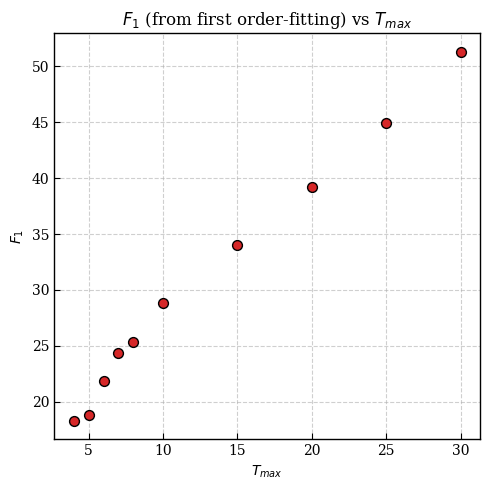

In [59]:
# 1. Initialize lists to capture data for the second plot
T_results = []
F1_results = []

# ======================
# Main Loop (Modified to store results)
# ======================
for T in T_list:
    if T < T_min or T > T_max:
        continue

    # (Assuming E_ideal and compute_R are defined as in your original script)
    E_ideal = vqe_means_by_c[0.0][T]
    
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([(-np.log(vqe_means_by_c[c][T] / E_ideal) if vqe_means_by_c[c][T]/E_ideal > 0 else np.nan) for c in C])

    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    # Build design matrix (no intercept) for Degree 1
    X = np.vander(C_fit, N=2, increasing=True)[:, 1:]
    F, _, _, _ = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store values for the new plot
    T_results.append(T)
    F1_results.append(F[0])
# Assuming T_results and F1_results were populated in your loop
plt.figure(figsize=(5, 5))

# Plot only the scatter points
plt.scatter(T_results, F1_results, color='tab:red', s=50, edgecolors='black', zorder=3)

# Labels and Formatting
plt.title("$F_1$ (from first order-fitting) vs $T_{max}$")
plt.xlabel("$T_{max}$")
plt.ylabel("$F_1$")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---

# Total-Z observable

Simulation using a different observable:

$$H_\text{Obs} = \sum_i Z_i$$

Loading simulation data for $H_\text{Obs}$

In [60]:
data_records_obs_totalz = load_all_experiments("data-totalz")

Grouping data

In [61]:
vqe_means_by_c_totalZ = {}
vqe_stds_by_c_totalZ = {}
t_vals_by_c_totalZ = {}
EXACT_SOLUTION_totalZ = data_records_obs_totalz["c0"]["processed"]["exact_solution"]
data_root = Path("data-totalz")

for c_dir in sorted(data_root.glob("c*")):
    # skip non-directories just in case
    if not c_dir.is_dir():
        continue

    # extract numeric C value: "c0.022" -> 0.022
    c = float(c_dir.name[1:])
    #print(f"Dir: c_dir.name")
    record = data_records_obs_totalz[c_dir.name]["processed"]

    vqe_means_by_c_totalZ[c] = record["vqe_means"]
    vqe_stds_by_c_totalZ[c] = record["vqe_stds"]
    t_vals_by_c_totalZ[c] = record["t_max"]
print(f"Exact solution with totalZ: {EXACT_SOLUTION_totalZ}")

Exact solution with totalZ: -5.0


Plotting VQE costs vs $T_{max}$ across different values of $C$

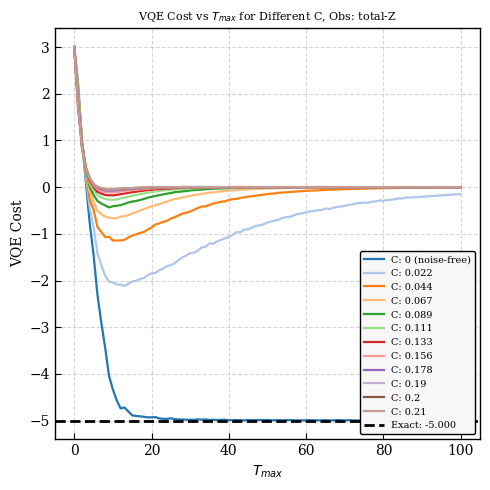

In [62]:
plt.figure(figsize=(5, 5))

# Filter for the specific target values of C
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
               0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
Cs = [c for c in target_vals if c in vqe_means_by_c_totalZ]

# Use tab20 for >10 curves (high contrast, discrete)
colors = plt.cm.tab20.colors[:len(Cs)]

for c, color in zip(Cs, colors):
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    plt.plot(
        t_vals_by_c_totalZ[c],
        vqe_means_by_c_totalZ[c],
        linewidth=1.6,
        alpha=1.0,
        color=color,
        label=label
    )

# Exact line (black is better than red for papers)
plt.axhline(
    y=EXACT_SOLUTION_totalZ,
    linestyle='--',
    linewidth=2.0,
    color='black',
    label=f'Exact: {EXACT_SOLUTION_totalZ:.3f}'
)

plt.xlabel("$T_{max}$")
plt.ylabel("VQE Cost")
plt.title("VQE Cost vs $T_{max}$ for Different C, Obs: total-Z", fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)

plt.tight_layout()
plt.show()


C=0.067: non-positive ratio at
  T = [ 82.  83.  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.
  96.  97.  98.  99. 100.]
  ratio = [-0.00027124 -0.00055478 -0.00050673 -0.00046194 -0.00042097 -0.00038443
 -0.0003543  -0.00032243 -0.00029471 -0.00026926 -0.00024699 -0.00022639
 -0.00020631 -0.00018792 -0.00017216 -0.0001564  -0.00014416 -0.00013165
 -0.00011996]
C=0.089: non-positive ratio at
  T = [  4.  62.  63.  64.  65.  66.  67.  68.  69.  70.  71.  72.  73.  74.
  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.  86.  87.  88.
  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.  99. 100.]
  ratio = [-2.57905123e-03 -4.28362967e-04 -5.13335150e-04 -4.55781008e-04
 -4.05399314e-04 -3.58520626e-04 -3.19133126e-04 -2.83183327e-04
 -2.50322578e-04 -2.22769357e-04 -1.96570874e-04 -1.76454480e-04
 -1.55607454e-04 -1.37873160e-04 -1.22819912e-04 -1.09073069e-04
 -9.65446492e-05 -8.55697650e-05 -7.63408272e-05 -6.80346741e-05
 -6.02976213e-05 -5.33795034e-05 -4.73366492e-

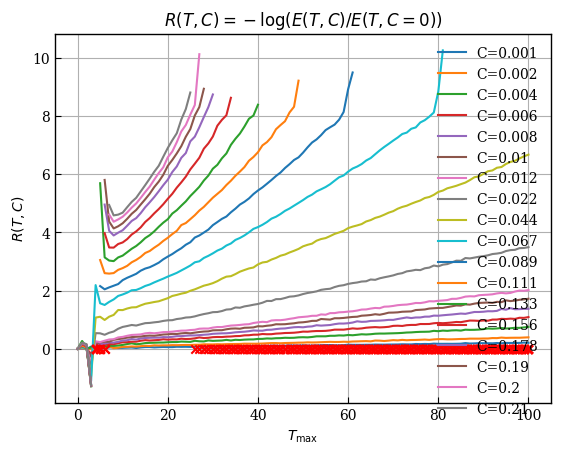

In [63]:
# Reference energy at C=0
E0 = np.array(vqe_means_by_c_totalZ[0.0], dtype=float)
T0 = np.array(t_vals_by_c_totalZ[0.0], dtype=float)

plt.figure()

for c in sorted(vqe_means_by_c_totalZ.keys()):
    if c == 0.0:
        continue

    E_c = np.array(vqe_means_by_c_totalZ[c], dtype=float)
    T_c = np.array(t_vals_by_c_totalZ[c], dtype=float)

    # Ensure time grids align
    if not np.allclose(T_c, T0):
        print(f"Warning: T grids differ for C={c}")
        continue

    ratio = E_c / E0

    # Masks
    positive_mask = ratio > 0
    nonpositive_mask = ratio <= 0

    # Report invalid points
    if np.any(nonpositive_mask):
        print(f"C={c}: non-positive ratio at")
        print("  T =", T_c[nonpositive_mask])
        print("  ratio =", ratio[nonpositive_mask])

    # Compute R only where valid
    R = np.full(ratio.shape, np.nan, dtype=float)
    R[positive_mask] = -np.log(ratio[positive_mask])

    # Plot valid curve
    plt.plot(T_c, R, label=f"C={c}")

    # Highlight invalid (ratio ≤ 0) points
    if np.any(nonpositive_mask):
        plt.scatter(
            T_c[nonpositive_mask],
            np.zeros_like(T_c[nonpositive_mask]),
            marker="x",
            color="red",
            zorder=3,
            label="ratio ≤ 0" if c == sorted(vqe_means_by_c_totalZ.keys())[1] else None
        )

plt.grid()
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,C=0))$")
plt.legend()
plt.show()

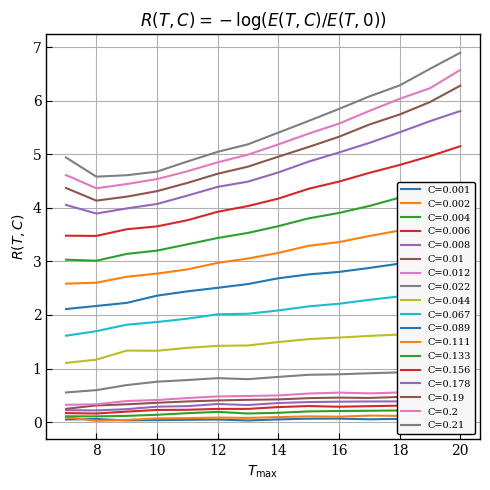

In [64]:
# ===============================
# User-defined T window
# ===============================
T_start = 7
T_end   = 20

# ===============================
# Reference data at C = 0
# ===============================
E0_all = np.array(vqe_means_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_by_c_totalZ[0.0], dtype=float)

plt.figure(figsize=(5, 5))

# ===============================
# Loop over C values
# ===============================
for c in sorted(vqe_means_by_c_totalZ.keys()):
    if c == 0.0:
        continue

    E_c_all = np.array(vqe_means_by_c_totalZ[c], dtype=float)
    T_c_all = np.array(t_vals_by_c_totalZ[c], dtype=float)

    # -------------------------------
    # Ensure T grids align
    # -------------------------------
    if not np.allclose(T_c_all, T0_all):
        print(f"Warning: T grids differ for C={c}")
        continue

    # -------------------------------
    # Select T window
    # -------------------------------
    window_mask = (T_c_all >= T_start) & (T_c_all <= T_end)

    if not np.any(window_mask):
        print(f"C={c}: no data in T window [{T_start}, {T_end}]")
        continue

    T_c = T_c_all[window_mask]
    E_c = E_c_all[window_mask]
    E0  = E0_all[window_mask]

    # -------------------------------
    # Compute ratio and R(T, C)
    # -------------------------------
    ratio = E_c / E0

    positive_mask    = ratio > 0
    nonpositive_mask = ratio <= 0

    if np.any(nonpositive_mask):
        print(f"C={c}: non-positive ratio detected")
        print("  T =", T_c[nonpositive_mask])
        print("  ratio =", ratio[nonpositive_mask])

    R = np.full(ratio.shape, np.nan, dtype=float)
    R[positive_mask] = -np.log(ratio[positive_mask])

    # -------------------------------
    # Plot
    # -------------------------------
    plt.plot(T_c, R, label=f"C={c}")

    # Highlight invalid points
    if np.any(nonpositive_mask):
        plt.scatter(
            T_c[nonpositive_mask],
            np.zeros_like(T_c[nonpositive_mask]),
            marker="x",
            color="red",
            zorder=3
        )

# ===============================
# Final plot formatting
# ===============================
plt.grid(True)
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,0))$")
plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)
plt.tight_layout()
plt.show()

> Could you compare between standard deviations and the difference of E_noisy and E_noiseless?
>
> My guess is that the difference between E_noisy and E_noiseless is so small in comparison to the standard deviation of E_noisy and E_noiseless for large T and small T.
>
> Such phenomenon cause this type of inconsistency
>
>
>In this case the difference is the difference between E_noisy and E_noiseless.
>Not, the difference between E_noisy(C1,T) and E_noisy(C2,T)

<>:85: DeprecationWarning: invalid escape sequence '\D'
<>:85: DeprecationWarning: invalid escape sequence '\D'
/tmp/ipykernel_14711/3561400057.py:85: DeprecationWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta E$")


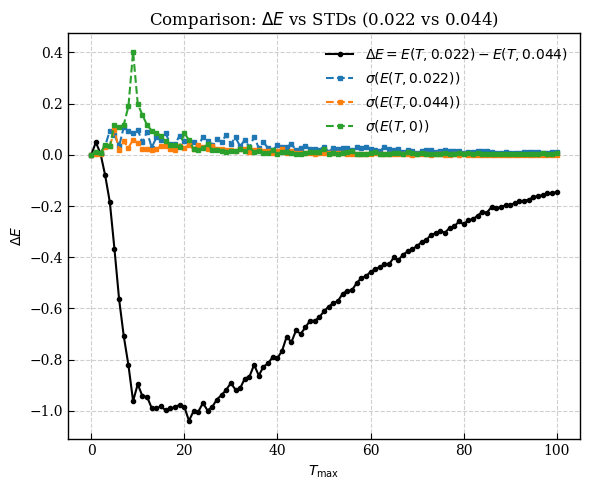

In [65]:
# ============================================================
# User choice: which C values to compare
# ============================================================
c1 = 0.022
c2 = 0.044

# ============================================================
# --- Extract data ---
# ============================================================
T = np.array(t_vals_by_c_totalZ[c1], dtype=float)

E_c1 = np.array(vqe_means_by_c_totalZ[c1], dtype=float)
E_c2 = np.array(vqe_means_by_c_totalZ[c2], dtype=float)

std_c1 = np.array(vqe_stds_by_c_totalZ[c1], dtype=float)
std_c2 = np.array(vqe_stds_by_c_totalZ[c2], dtype=float)

# Reference C = 0 (noiseless)
T_0 = np.array(t_vals_by_c_totalZ[0.0], dtype=float)
std_c0 = np.array(vqe_stds_by_c_totalZ[0.0], dtype=float)

# ============================================================
# --- Compute Delta E ---
# ============================================================
delta_E = E_c1 - E_c2

# ============================================================
# --- Ensure same length ---
# ============================================================
N = min(
    len(T),
    len(delta_E),
    len(std_c1),
    len(std_c2),
)

T_plot   = T[:N]
delta_E  = delta_E[:N]
std_c1   = std_c1[:N]
std_c2   = std_c2[:N]

# Match C=0 std length to T_plot if needed
std_c0 = std_c0[:min(len(std_c0), len(T_plot))]
T_0    = T_0[:len(std_c0)]

# ============================================================
# --- Plot ---
# ============================================================
plt.figure(figsize=(6, 5))

plt.plot(
    T_plot,
    delta_E,
    'o-',
    color='black',
    markersize=3,
    label=rf'$\Delta E = E(T,{c1}) - E(T,{c2})$'
)

plt.plot(
    T_plot,
    std_c1,
    's--',
    markersize=3,
    label=rf'$\sigma(E(T,{c1}))$'
)

plt.plot(
    T_plot,
    std_c2,
    's--',
    markersize=3,
    label=rf'$\sigma(E(T,{c2}))$'
)

plt.plot(
    T_0,
    std_c0,
    's--',
    markersize=3,
    label=r'$\sigma(E(T,0))$'
)

plt.xlabel(r"$T_{\max}$")
plt.ylabel("$\Delta E$")
plt.title(rf"Comparison: $\Delta E$ vs STDs ({c1} vs {c2})")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

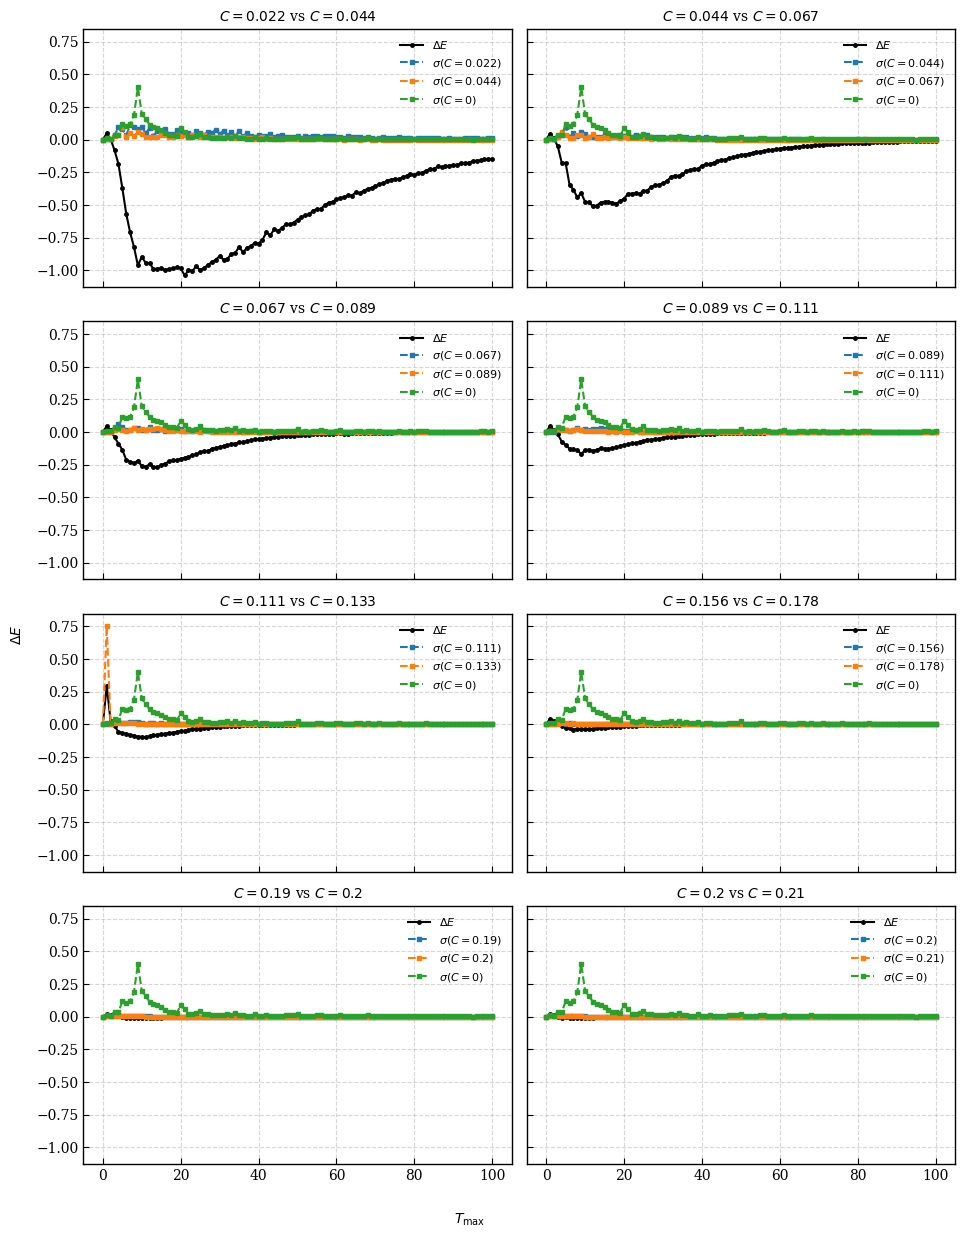

In [66]:
# ============================================================
# C pairs
# ============================================================
c_pairs = [
    (0.022, 0.044),
    (0.044, 0.067),
    (0.067, 0.089),
    (0.089, 0.111),
    (0.111, 0.133),
    (0.156, 0.178),
    (0.19, 0.2),
    (0.2, 0.210)
]

# ============================================================
# Layout: 2 columns, automatic rows
# ============================================================
n_plots = len(c_pairs)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 3.2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# ============================================================
# Reference C = 0
# ============================================================
T_0 = np.array(t_vals_by_c_totalZ[0.0], dtype=float)
std_c0_all = np.array(vqe_stds_by_c_totalZ[0.0], dtype=float)

# ============================================================
# Loop over C pairs
# ============================================================
for ax, (c1, c2) in zip(axes, c_pairs):

    T = np.array(t_vals_by_c_totalZ[c1], dtype=float)
    E_noise_less = np.array(vqe_means_by_c_totalZ[0.0], dtype=float)
    E_c1 = np.array(vqe_means_by_c_totalZ[c1], dtype=float)
    E_c2 = np.array(vqe_means_by_c_totalZ[c2], dtype=float)

    std_c1 = np.array(vqe_stds_by_c_totalZ[c1], dtype=float)
    std_c2 = np.array(vqe_stds_by_c_totalZ[c2], dtype=float)

    delta_E = E_c1 - E_c2

    N = min(len(T), len(delta_E), len(std_c1), len(std_c2))
    T_plot  = T[:N]
    delta_E = delta_E[:N]
    std_c1  = std_c1[:N]
    std_c2  = std_c2[:N]

    std_c0 = std_c0_all[:min(len(std_c0_all), len(T_plot))]
    T0_plot = T_0[:len(std_c0)]

    ax.plot(
        T_plot,
        delta_E,
        'o-',
        color='black',
        markersize=2.5,
        label=r'$\Delta E$'
    )

    ax.plot(
        T_plot,
        std_c1,
        's--',
        markersize=2.5,
        label=rf'$\sigma(C={c1})$'
    )

    ax.plot(
        T_plot,
        std_c2,
        's--',
        markersize=2.5,
        label=rf'$\sigma(C={c2})$'
    )

    ax.plot(
        T0_plot,
        std_c0,
        's--',
        markersize=2.5,
        label=r'$\sigma(C=0)$'
    )

    ax.set_title(rf"$C={c1}$ vs $C={c2}$", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

# ============================================================
# Hide unused axes (if any)
# ============================================================
for ax in axes[len(c_pairs):]:
    ax.axis("off")

# ============================================================
# Shared labels
# ============================================================
fig.text(0.5, 0.04, r"$T_{\max}$", ha="center")
fig.text(0.04, 0.5, r"$\Delta E$", va="center", rotation="vertical")

plt.tight_layout(rect=[0.06, 0.06, 1, 1])
plt.show()

> Sorry for the confusion about the sign issue.  
> The important quantity is ΔE_noisy / E_noisy (or equivalently E_noisy / ΔE_noisy).
>
> If E_noisy and ΔE_noisy are of the same order, the sign cannot be trusted.
>
> For small T, the issue was that  
> ΔE_noisy ≈ E_noisy − E_noiseless.
>
> For large T, the problem becomes  
> ΔE_noisy ≈ E_noisy.
>
> From your graph, E_noiseless < 0 for all large T.
>
> Hence, the sign problem occurs when E_noisy > 0.
>
> From physical intuition, this should never occur.
>
> Therefore, this is likely a numerical or statistical error.
>
> ΔE_noisy is standard deviation of E_noisy

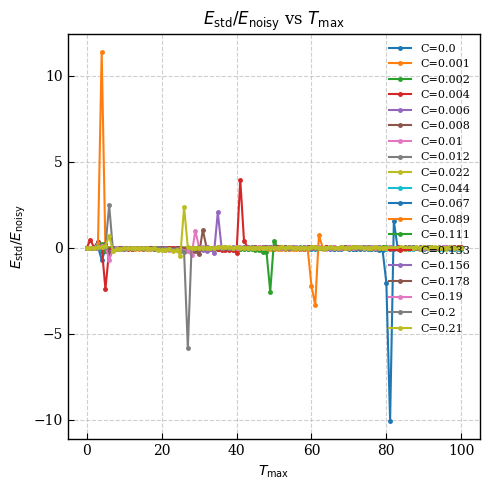

In [67]:
# ------------------------------------------------------------
# C values to plot
# ------------------------------------------------------------
C_values = [c for c in sorted(vqe_means_by_c_totalZ.keys())]

plt.figure(figsize=(5, 5))

# ------------------------------------------------------------
# Plot E_std / E_noisy vs T
# ------------------------------------------------------------
for c in C_values:
    T = np.array(t_vals_by_c_totalZ[c])
    E_noisy = np.array(vqe_means_by_c_totalZ[c])
    E_std = np.array(vqe_stds_by_c_totalZ[c])

    # ensure same length
    N = min(len(T), len(E_noisy), len(E_std))
    T = T[:N]
    E_noisy = E_noisy[:N]
    E_std = E_std[:N]

    ratio = E_std / E_noisy

    plt.plot(
        T,
        ratio,
        marker='o',
        markersize=2.5,
        label=f"C={c}"
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$E_{\mathrm{std}} / E_{\mathrm{noisy}}$")
plt.title(r"$E_{\mathrm{std}} / E_{\mathrm{noisy}}$ vs $T_{\max}$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

---

## Applying `E_THRESHOLD = -1e-5` to both `ising` and `total-Z`

> In the above document, it is written that the default value of `ftol` is 10⁻⁶.
>
> If you did not change this option, the precision of the optimization is 10⁻⁶.
>
> The value of E_noisy for C = 0.178 is much smaller than `ftol`.
>
> Therefore, this is a kind of numerical error.
>
> Intuitively speaking, we cannot trust optimization results that are smaller than 10⁻⁶.
>
> If the optimization result is smaller than 10⁻⁶, it simply means that the optimization code decides to stop because the value is sufficiently small.
> In some sense, the algorithm treats it as “zero.”
>
> For large T, let us use only the data for which  
> E_noisy < −10⁻⁵.
>
> Here, “large T” means values of T that are larger than the T at which E_noisy(T) takes its minimum.
>
> For each C, there exists a minimum value of E_noisy(T).
>
> For all T larger than this arg-minimum T, we do not use data points where  
> E_noisy > −10⁻⁵.
>
> After calculating R(T, C), please fit it as
>
> R(T, C) = C·F₁(T) + C²·F₂(T) + C³·F₃(T) + C⁴·F₄(T) + …
>
> It may be sufficient to perform only first- and second-order fitting:
>
> R(T, C) = C·F₁(T)
>
> or
>
> R(T, C) = C·F₁(T) + C²·F₂(T).
>
> Then, you can further fit F₁(T) and F₂(T).

In [68]:
# Data Containters dicts
# vqe_means_by_c_totalZ
# vqe_stds_by_c_totalZ
# t_vals_by_c_totalZ

`E_THRESHOLD = -1e-5`

In [69]:
# ============================================================
# Create NEW filtered containers
# ============================================================

vqe_means_filtered_by_c_totalZ = {}
vqe_stds_filtered_by_c_totalZ  = {}
t_vals_filtered_by_c_totalZ   = {}

E_THRESHOLD = -1e-5

# total-z
for c in vqe_means_by_c_totalZ.keys():

    # Convert to numpy arrays
    E   = np.array(vqe_means_by_c_totalZ[c], dtype=float)
    std = np.array(vqe_stds_by_c_totalZ[c], dtype=float)
    T   = np.array(t_vals_by_c_totalZ[c], dtype=float)

    # Sanity check: one-to-one correspondence
    assert len(E) == len(std) == len(T), f"Length mismatch at C={c}"

    # 1. Index of minimum E_noisy
    idx_min = np.argmin(E)

    # 2. Build mask
    mask = np.ones(len(E), dtype=bool)

    post_min = np.arange(len(E)) > idx_min
    mask[post_min] = E[post_min] <= E_THRESHOLD

    # 3. Store filtered results (NEW dicts)
    vqe_means_filtered_by_c_totalZ[c] = E[mask].tolist()
    vqe_stds_filtered_by_c_totalZ[c]  = std[mask].tolist()
    t_vals_filtered_by_c_totalZ[c]    = T[mask].tolist()


In [70]:
# For ising observable
vqe_means_filtered_by_c_ising = {}
vqe_stds_filtered_by_c_ising = {}
t_vals_filtered_by_c_ising = {}

E_THRESHOLD = -1e-5

# isng
for c in vqe_means_by_c.keys():

    # Convert to numpy arrays
    E   = np.array(vqe_means_by_c[c], dtype=float)
    std = np.array(vqe_stds_by_c[c], dtype=float)
    T   = np.array(t_vals_by_c[c], dtype=float)

    # Sanity check: one-to-one correspondence
    assert len(E) == len(std) == len(T), f"Length mismatch at C={c}"

    # 1. Index of minimum E_noisy
    idx_min = np.argmin(E)

    # 2. Build mask
    mask = np.ones(len(E), dtype=bool)

    post_min = np.arange(len(E)) > idx_min
    mask[post_min] = E[post_min] <= E_THRESHOLD

    # 3. Store filtered results (NEW dicts)
    vqe_means_filtered_by_c_ising[c] = E[mask].tolist()
    vqe_stds_filtered_by_c_ising[c]  = std[mask].tolist()
    t_vals_filtered_by_c_ising[c]    = T[mask].tolist()

---

`total-z`

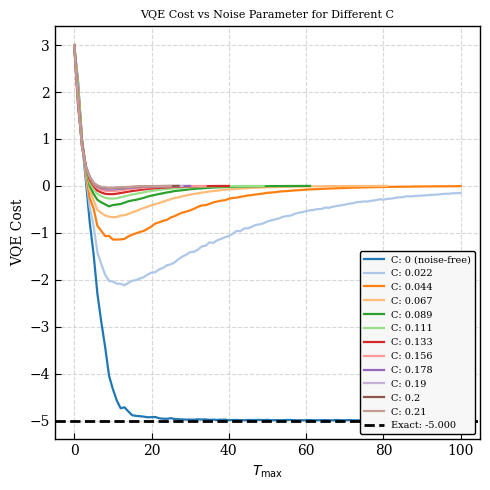

In [71]:
plt.figure(figsize=(5, 5))

# ============================================================
# Target C values (keep order)
# ============================================================
target_vals = [
    0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
    0.133, 0.156, 0.178, 0.190, 0.200, 0.210
]

# Keep only C values present in filtered data
Cs = [c for c in target_vals if c in vqe_means_filtered_by_c_totalZ]

# Colors (tab20 supports many curves clearly)
colors = plt.cm.tab20.colors[:len(Cs)]

# ============================================================
# Plot filtered VQE means
# ============================================================
for c, color in zip(Cs, colors):
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    plt.plot(
        t_vals_filtered_by_c_totalZ[c],
        vqe_means_filtered_by_c_totalZ[c],
        linewidth=1.6,
        alpha=1.0,
        color=color,
        label=label
    )

# ============================================================
# Exact solution
# ============================================================
plt.axhline(
    y=EXACT_SOLUTION_totalZ,
    linestyle='--',
    linewidth=2.0,
    color='black',
    label=f'Exact: {EXACT_SOLUTION_totalZ:.3f}'
)

# ============================================================
# Styling
# ============================================================
plt.xlabel(r"$T_{\max}$")
plt.ylabel("VQE Cost")
plt.title("VQE Cost vs Noise Parameter for Different C", fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)

plt.tight_layout()
plt.show()

$R(T,C)$ using filtered data

C=0.089: -negative ratio detected
  T = [4.]
  ratio = [-0.00257905]
C=0.111: -negative ratio detected
  T = [4.]
  ratio = [-0.09697923]
C=0.133: -negative ratio detected
  T = [4.]
  ratio = [-0.16964366]
C=0.156: -negative ratio detected
  T = [4. 5.]
  ratio = [-0.22648262 -0.02163218]
C=0.178: -negative ratio detected
  T = [4. 5.]
  ratio = [-0.24184254 -0.04015072]
C=0.19: -negative ratio detected
  T = [4. 5.]
  ratio = [-0.2498173  -0.04057784]
C=0.2: -negative ratio detected
  T = [4. 5. 6.]
  ratio = [-0.24049995 -0.04336946 -0.00087492]
C=0.21: -negative ratio detected
  T = [4. 5. 6.]
  ratio = [-0.25086816 -0.04723895 -0.00381089]


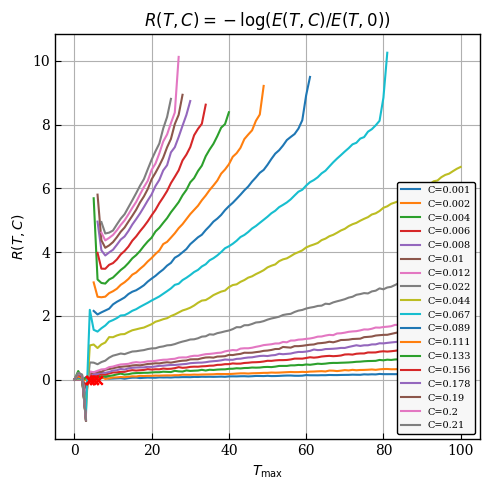

In [72]:
# ===============================
# User-defined T window
# ===============================
T_start = 0
T_end   = 100

# ===============================
# Reference data at C = 0 (filtered)
# ===============================
E0_all = np.array(vqe_means_filtered_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_filtered_by_c_totalZ[0.0], dtype=float)

plt.figure(figsize=(5, 5))

# ===============================
# Loop over C values (filtered)
# ===============================
for c in sorted(vqe_means_filtered_by_c_totalZ.keys()):
    if c == 0.0:
        continue

    E_c_all = np.array(vqe_means_filtered_by_c_totalZ[c], dtype=float)
    T_c_all = np.array(t_vals_filtered_by_c_totalZ[c], dtype=float)

    # -------------------------------
    # Ensure T grids align (after filtering)
    # -------------------------------
    N = min(len(T_c_all), len(T0_all))
    T_c_all = T_c_all[:N]
    E_c_all = E_c_all[:N]
    E0_all_cut = E0_all[:N]
    T0_all_cut = T0_all[:N]

    if not np.allclose(T_c_all, T0_all_cut):
        print(f"Warning: T grids differ for C={c}")
        continue

    # -------------------------------
    # Select T window
    # -------------------------------
    window_mask = (T_c_all >= T_start) & (T_c_all <= T_end)# 4. CONSTRUCT TEXT OUTPUT

    if not np.any(window_mask):
        print(f"C={c}: no data in T window [{T_start}, {T_end}]")
        continue

    T_c = T_c_all[window_mask]
    E_c = E_c_all[window_mask]
    E0  = E0_all_cut[window_mask]

    # -------------------------------
    # Compute ratio and R(T, C)
    # -------------------------------
    ratio = E_c / E0

    positive_mask    = ratio > 0
    nonpositive_mask = ratio <= 0

    if np.any(nonpositive_mask):
        print(f"C={c}: -negative ratio detected")
        print("  T =", T_c[nonpositive_mask])
        print("  ratio =", ratio[nonpositive_mask])

    R = np.full(ratio.shape, np.nan, dtype=float)
    R[positive_mask] = -np.log(ratio[positive_mask])

    # -------------------------------
    # Plot
    # -------------------------------
    plt.plot(T_c, R, label=f"C={c}")

    if np.any(nonpositive_mask):
        plt.scatter(
            T_c[nonpositive_mask],
            np.zeros_like(T_c[nonpositive_mask]),
            marker="x",
            color="red",
            zorder=3
        )

# ===============================
# Final plot formatting
# ===============================
plt.grid(True)
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,0))$")
plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)
plt.tight_layout()# 4. CONSTRUCT TEXT OUTPUT
plt.show()

---

## Sign filter to both `ising` and `total-z`

Another filter where E_noisy and E_C0 have same sign.

>We need to remove the data with which E_noisy and E_noiseless have the different sign.
>Intuitively, it is due to statistical or numerical error.

In [73]:
# ============================================================
# Second-stage filter: enforce same sign as C=0
# ============================================================

# total-z
vqe_means_sign_filtered_by_c_totalZ = {}
vqe_stds_sign_filtered_by_c_totalZ  = {}
t_vals_sign_filtered_by_c_totalZ   = {}


# Reference (C = 0)
E0_all = np.array(vqe_means_filtered_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_filtered_by_c_totalZ[0.0], dtype=float)

for c in vqe_means_filtered_by_c_totalZ.keys():

    E  = np.array(vqe_means_filtered_by_c_totalZ[c], dtype=float)
    std = np.array(vqe_stds_filtered_by_c_totalZ[c], dtype=float)
    T  = np.array(t_vals_filtered_by_c_totalZ[c], dtype=float)

    # Align lengths safely
    N = min(len(E), len(E0_all))
    E   = E[:N]
    std = std[:N]
    T   = T[:N]
    E0  = E0_all[:N]

    # ------------------------------------------------
    # Sign-consistency filter
    # ------------------------------------------------
    same_sign_mask = np.sign(E) == np.sign(E0)

    # Store NEW containers
    vqe_means_sign_filtered_by_c_totalZ[c] = E[same_sign_mask].tolist()
    vqe_stds_sign_filtered_by_c_totalZ[c]  = std[same_sign_mask].tolist()
    t_vals_sign_filtered_by_c_totalZ[c]    = T[same_sign_mask].tolist()

In [74]:
# isng
vqe_means_sign_filtered_by_c_ising = {}
vqe_stds_sign_filtered_by_c_ising = {}
t_vals_sign_filtered_by_c_ising = {}

# Reference (C = 0)
E0_all_ising = np.array(vqe_means_filtered_by_c_ising[0.0], dtype=float)
T0_all_ising = np.array(t_vals_filtered_by_c_ising[0.0], dtype=float)

for c in vqe_means_filtered_by_c_ising.keys():

    E  = np.array(vqe_means_filtered_by_c_ising[c], dtype=float)
    std = np.array(vqe_stds_filtered_by_c_ising[c], dtype=float)
    T  = np.array(t_vals_filtered_by_c_ising[c], dtype=float)

    # Align lengths safely
    N = min(len(E), len(E0_all_ising))
    E   = E[:N]
    std = std[:N]
    T   = T[:N]
    E0  = E0_all_ising[:N]

    # ------------------------------------------------
    # Sign-consistency filter
    # ------------------------------------------------
    same_sign_mask = np.sign(E) == np.sign(E0)

    # Store NEW containers
    vqe_means_sign_filtered_by_c_ising[c] = E[same_sign_mask].tolist()
    vqe_stds_sign_filtered_by_c_ising[c]  = std[same_sign_mask].tolist()
    t_vals_sign_filtered_by_c_ising[c]    = T[same_sign_mask].tolist()

---

In [75]:
assert len(vqe_means_sign_filtered_by_c_totalZ) == len(vqe_stds_sign_filtered_by_c_totalZ) == len(t_vals_sign_filtered_by_c_totalZ)

In [76]:
assert len(vqe_means_sign_filtered_by_c_ising) == len(vqe_stds_sign_filtered_by_c_ising) == len(t_vals_sign_filtered_by_c_ising)

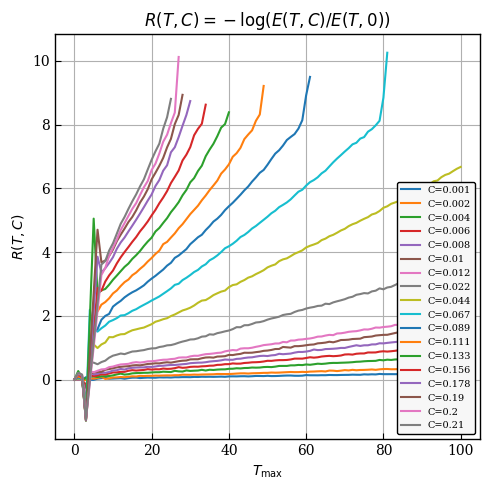

In [77]:
# ===============================
# User-defined T window
# ===============================
T_start = 0
T_end   = 100

# ===============================
# Containers to STORE R(T,C)
# ===============================
R_by_c_totalZ = {}
T_by_c_for_R_totalZ = {}

# ===============================
# Reference data at C = 0 (sign-filtered)
# ===============================
E0_all = np.array(vqe_means_sign_filtered_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_sign_filtered_by_c_totalZ[0.0], dtype=float)

plt.figure(figsize=(5, 5))

# ===============================
# Loop over C values
# ===============================
for c in sorted(vqe_means_sign_filtered_by_c_totalZ.keys()):
    if c == 0.0:
        continue

    E_c_all = np.array(vqe_means_sign_filtered_by_c_totalZ[c], dtype=float)
    T_c_all = np.array(t_vals_sign_filtered_by_c_totalZ[c], dtype=float)

    # -------------------------------
    # Align safely
    # -------------------------------
    N = min(len(T_c_all), len(T0_all))
    T_c_all = T_c_all[:N]
    E_c_all = E_c_all[:N]
    E0_cut  = E0_all[:N]

    # -------------------------------
    # Select T window
    # -------------------------------
    window_mask = (T_c_all >= T_start) & (T_c_all <= T_end)
    if not np.any(window_mask):
        continue

    T_c = T_c_all[window_mask]
    E_c = E_c_all[window_mask]
    E0  = E0_cut[window_mask]

    # -------------------------------
    # Compute R(T,C) ONCE
    # -------------------------------
    R = -np.log(E_c / E0)

    # -------------------------------
    # STORE for later fitting
    # -------------------------------
    R_by_c_totalZ[c] = R
    T_by_c_for_R_totalZ[c] = T_c

    # -------------------------------
    # Plot
    # -------------------------------
    plt.plot(T_c, R, label=f"C={c}")

# ===============================
# Final plot formatting
# ===============================
plt.grid(True)
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,0))$")
plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)
plt.tight_layout()
plt.show()

Fitting of $R(T, C)$

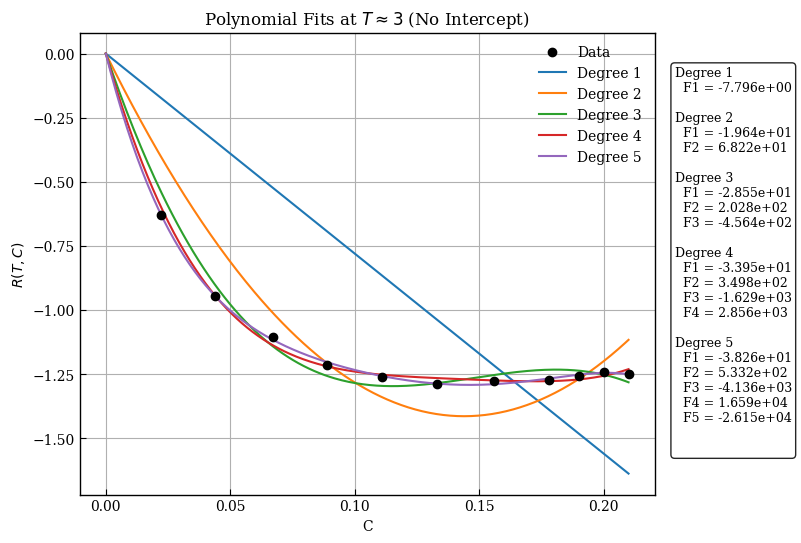

In [78]:
# ======================
# User settings
# ======================
T_target = 3      # physical T value
degrees = [1, 2, 3, 4, 5]

target_vals = [
    0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
    0.133, 0.156, 0.178, 0.190, 0.200, 0.210
]

# ======================
# Collect R(T_target, C)
# ======================
C_list = []
R_list = []

for c in target_vals:
    if c == 0.0:
        continue
    if c not in R_by_c_totalZ:
        continue

    T_vals = np.array(T_by_c_for_R_totalZ[c], dtype=float)
    R_vals = np.array(R_by_c_totalZ[c], dtype=float)

    # Find closest T to T_target
    idx = np.argmin(np.abs(T_vals - T_target))

    C_list.append(c)
    R_list.append(R_vals[idx])

C = np.array(C_list, dtype=float)
R = np.array(R_list, dtype=float)

# Keep finite values only
mask = np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)

ax.scatter(C_fit, R_fit, color="black", label="Data", zorder=3)

C_smooth = np.linspace(0, C_fit.max(), 300)
coeff_text = ""

# ======================
# Polynomial fits (no intercept)
# ======================
for deg in degrees:

    # Design matrix (no constant term)
    X = np.vander(C_fit, N=deg + 1, increasing=True)[:, 1:]

    # Least squares
    F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients
    coeff_text += f"Degree {deg}\n"
    for k in range(deg):
        coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = np.vander(C_smooth, N=deg + 1, increasing=True)[:, 1:]
    R_smooth = X_smooth @ F

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel(r"$R(T, C)$")
ax.set_title(rf"Polynomial Fits at $T \approx {T_target}$ (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Coefficient text box
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.show()

Using Scikit-learn

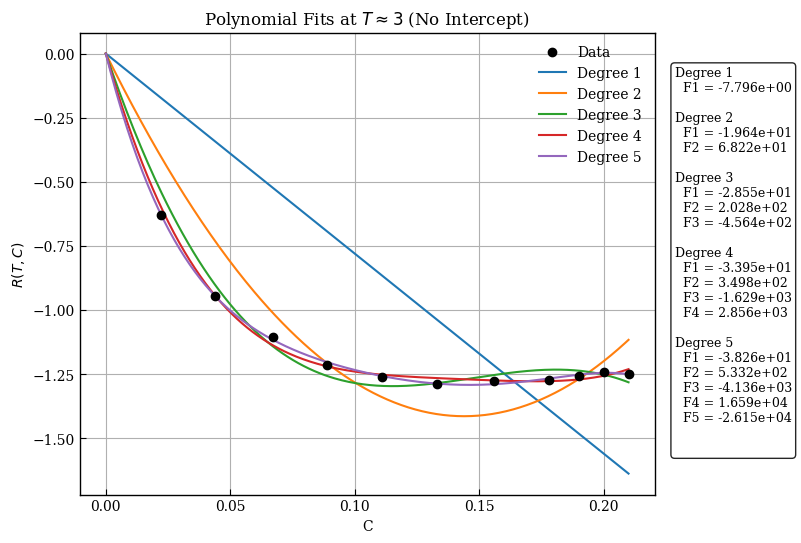

In [79]:
# ======================
# User settings
# ======================
T_target = 3      # physical T value
degrees = [1, 2, 3, 4, 5]

target_vals = [
    0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
    0.133, 0.156, 0.178, 0.190, 0.200, 0.210
]

# ======================
# Collect R(T_target, C)
# ======================
C_list = []
R_list = []

for c in target_vals:
    if c == 0.0:
        continue
    if c not in R_by_c_totalZ:
        continue

    T_vals = np.asarray(T_by_c_for_R_totalZ[c], dtype=float)
    R_vals = np.asarray(R_by_c_totalZ[c], dtype=float)

    # Closest physical T
    idx = np.argmin(np.abs(T_vals - T_target))

    C_list.append(c)
    R_list.append(R_vals[idx])

C = np.asarray(C_list).reshape(-1, 1)
R = np.asarray(R_list)

# Keep finite values only
mask = np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)

ax.scatter(C_fit, R_fit, color="black", label="Data", zorder=3)

C_smooth = np.linspace(0, C_fit.max(), 300).reshape(-1, 1)
coeff_text = ""

# ======================
# Polynomial fits (NO intercept)
# ======================
for deg in degrees:

    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_fit = poly.fit_transform(C_fit)
    X_smooth = poly.transform(C_smooth)

    model = LinearRegression(fit_intercept=False)
    model.fit(X_fit, R_fit)

    R_smooth = model.predict(X_smooth)

    # Store coefficients
    coeff_text += f"Degree {deg}\n"
    for k, coef in enumerate(model.coef_, start=1):
        coeff_text += f"  F{k} = {coef:.3e}\n"
    coeff_text += "\n"

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel(r"$R(T, C)$")
ax.set_title(rf"Polynomial Fits at $T \approx {T_target}$ (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Coefficient text box
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.show()

---

## $R(T,C)$ Fitting formula

Fitting $R(T,C)$ at various $T$

#### Polynomial Fitting of $R(T, C)$

Since $R(T, C=0) = 0$ for all $T$,  
the constant term must vanish in the polynomial expansion.

Therefore, we impose $F_0(T) = 0$, and write

$$
R(T, C) = C\,F_1(T) + C^2 F_2(T) + C^3 F_3(T) + C^4 F_4(T) + \cdots
$$

This enforces the physical constraint that the noise response
vanishes when $C = 0$.

> From these data, you can further fit:
> 
> $$F_1(T) = F_{10} + F_{11}T + F_{12}T^2$$
> $$F_2(T) = F_{20} + F_{21}T + F_{22}T^2$$
> 
> and find the coefficients $F_{10}, F_{11}, F_{12}, F_{20}, F_{21}, \text{and } F_{22}$.
> 
> I would like you to plot $F_1(T)$ and $F_2(T)$ where:
> * **Plot 1:** y-axis is $F_1(T)$ and x-axis is $T$.
> * **Plot 2:** y-axis is $F_2(T)$ and x-axis is $T$.
>
>
>
>





> This is second degree in C and second degree in T.
>
> We can decrease the number of coefficients if we want.
>
> In general, by increasing the number of coefficients, the fitting may become more difficult.
>
> There may exist some optimal degree.
>
> If we choose second degree in C and second degree in T, there are six coefficients in R(T,C).
>
> This may be too large, but I do not know—let us try.
>
> So, we should always keep in mind that we can decrease the number of coefficients.



> (1) First, we fit R(T,C) for different values of T using a polynomial of degree 2 in C.  
> This gives us F₁(T) and F₂(T) for various T.
>
> (2) Then, we further fit F₁(T) and F₂(T) as functions of T. Possible choices are:
>
> F₁(T) = F₁₀ + F₁₁ T + F₁₂ T²  
> F₂(T) = F₂₀ + F₂₁ T + F₂₂ T²
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T  
> F₂(T) = F₂₀ + F₂₁ T + F₂₂ T²
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T + F₁₂ T²  
> F₂(T) = F₂₀ + F₂₁ T
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T  
> F₂(T) = F₂₀ + F₂₁ T
>
> or
>
> F₁(T) = F₁₀  
> F₂(T) = F₂₀ + F₂₁ T
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T  
> F₂(T) = F₂₀


Order of $C=1$, $R(T, C) = C\,F_1(T) $

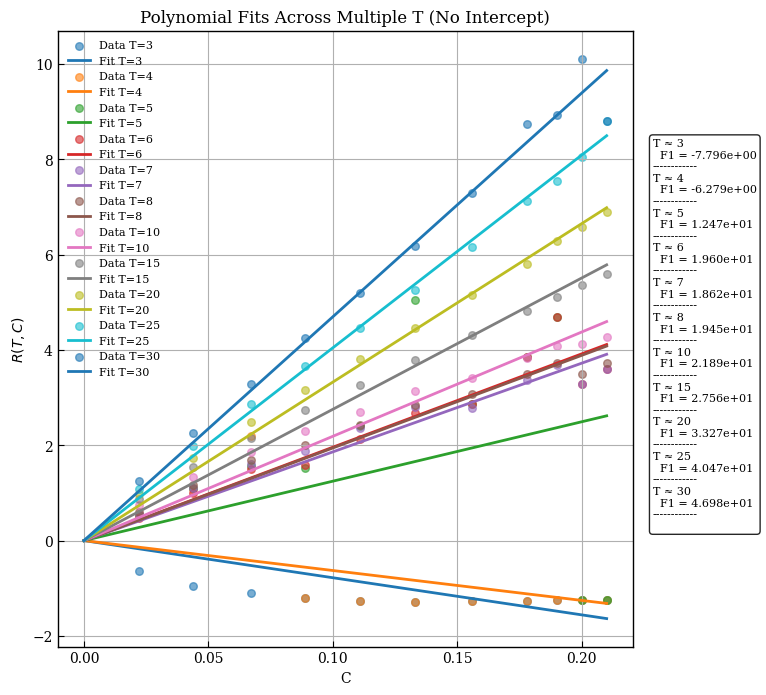

In [80]:
# ======================
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30]
T_min = 0
T_max = 100
degree = 1   # fixed degree

target_vals = [
    0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
    0.133, 0.156, 0.178, 0.190, 0.200, 0.210
]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)

coeff_text = ""
fit_coeffs_by_T = {}   # store coefficients programmatically

# ======================
# Loop over T values
# ======================
for T_target in T_list:

    if T_target < T_min or T_target > T_max:
        print(f"Skipping T={T_target}: outside range")
        continue

    C_list = []
    R_list = []

    for c in target_vals:
        if c == 0.0:
            continue
        if c not in R_by_c_totalZ:
            continue

        T_vals = np.asarray(T_by_c_for_R_totalZ[c], dtype=float)
        R_vals = np.asarray(R_by_c_totalZ[c], dtype=float)

        # Closest physical T
        idx = np.argmin(np.abs(T_vals - T_target))

        C_list.append(c)
        R_list.append(R_vals[idx])

    C = np.asarray(C_list).reshape(-1, 1)
    R = np.asarray(R_list)

    # Keep valid values only
    mask = np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    if len(C_fit) < degree + 1:
        print(f"Skipping T={T_target}: insufficient data")
        continue

    # Scatter data
    ax.scatter(C_fit, R_fit, s=30, label=f"Data T={T_target}", alpha=0.6)

    # ======================
    # Polynomial fit (NO intercept)
    # ======================
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_fit = poly.fit_transform(C_fit)

    model = LinearRegression(fit_intercept=False)
    model.fit(X_fit, R_fit)

    # Store coefficients
    fit_coeffs_by_T[T_target] = model.coef_

    coeff_text += f"T ≈ {T_target}\n"
    for k, coef in enumerate(model.coef_, start=1):
        coeff_text += f"  F{k} = {coef:.3e}\n"
    coeff_text += "-" * 12 + "\n"

    # Smooth curve
    C_smooth = np.linspace(0, C_fit.max(), 300).reshape(-1, 1)
    X_smooth = poly.transform(C_smooth)
    R_smooth = model.predict(X_smooth)

    ax.plot(C_smooth, R_smooth, lw=2, label=f"Fit T={T_target}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel(r"$R(T, C)$")
ax.set_title("Polynomial Fits Across Multiple T (No Intercept)")
ax.grid(True)
ax.legend(fontsize=8)

# ======================
# Coefficient text box
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.show()

Further fitting $F_1(T) = F_{10} + F_{11}T + F_{12}T^2$

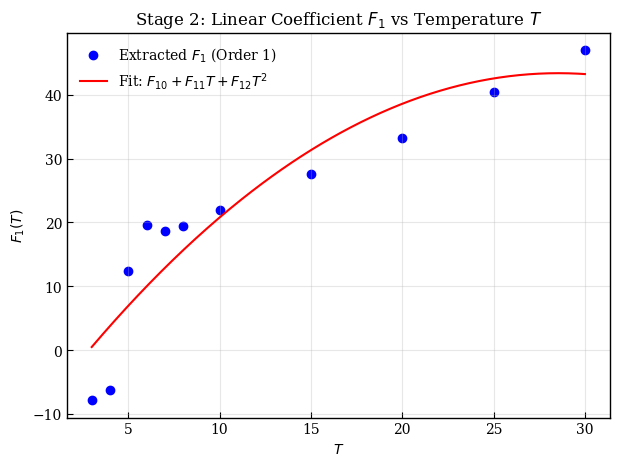

Final Coefficients for F1(T): F10=-1.0149e+01, F11=3.7504e+00, F12=-6.5708e-02


In [81]:
# ============================================================
# STAGE 2: Fitting F1(T) for the Order 1 Model
# ============================================================

# 1. Extract F1 values from the degree=1 dictionary
# (Note: model.coef_ only has one value [F1] when degree=1)
final_T_extracted = np.array(sorted(fit_coeffs_by_T.keys())).reshape(-1, 1)
final_F1_extracted = np.array([fit_coeffs_by_T[t][0] for t in sorted(fit_coeffs_by_T.keys())])

# 2. Setup the quadratic model for T (Order 2 in T)
final_poly_T = PolynomialFeatures(degree=2, include_bias=True)
final_X_T = final_poly_T.fit_transform(final_T_extracted)

# 3. Fit F1(T) = F10 + F11*T + F12*T^2
final_model_F1 = LinearRegression(fit_intercept=False).fit(final_X_T, final_F1_extracted)
F10, F11, F12 = final_model_F1.coef_

# 4. Plotting
final_T_smooth = np.linspace(final_T_extracted.min(), final_T_extracted.max(), 300).reshape(-1, 1)
final_F1_fit_curve = final_model_F1.predict(final_poly_T.transform(final_T_smooth))

plt.figure(figsize=(7, 5))
plt.scatter(final_T_extracted, final_F1_extracted, color='blue', label='Extracted $F_1$ (Order 1)')
plt.plot(final_T_smooth, final_F1_fit_curve, 'r-', label=f'Fit: $F_{{10}} + F_{{11}}T + F_{{12}}T^2$')
plt.xlabel('$T$')
plt.ylabel('$F_1(T)$')
plt.title('Stage 2: Linear Coefficient $F_1$ vs Temperature $T$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Coefficients for F1(T): F10={F10:.4e}, F11={F11:.4e}, F12={F12:.4e}")

---

Order of $C = 2$, Fitting $R(T,C)= F_1 \cdot C + F_2 \cdot C^2$

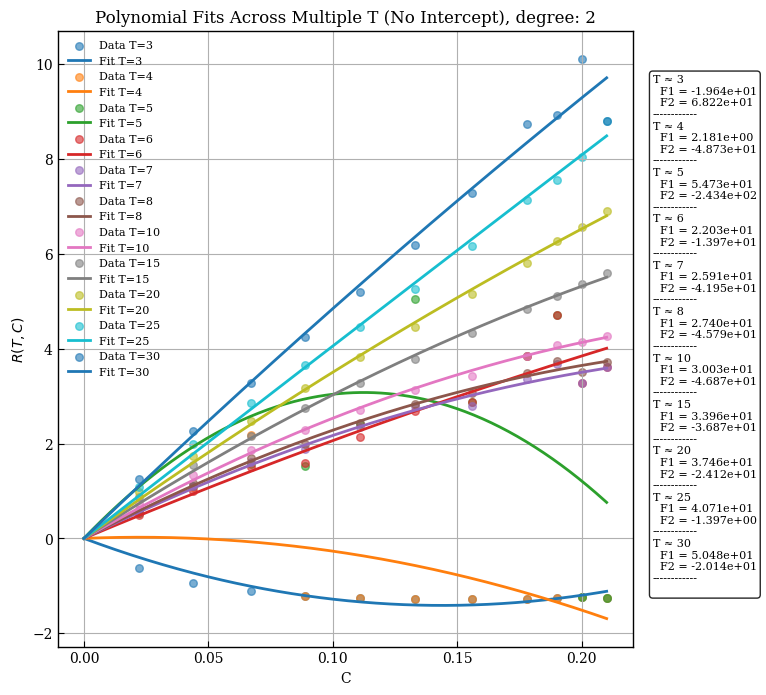

In [82]:
# ======================
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30]
T_min = 0
T_max = 100
degree = 2   # fixed degree

target_vals = [
    0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
    0.133, 0.156, 0.178, 0.190, 0.200, 0.210
]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)

coeff_text = ""
fit_coeffs_by_T = {}   # store coefficients programmatically

# ======================
# Loop over T values
# ======================
for T_target in T_list:

    if T_target < T_min or T_target > T_max:
        print(f"Skipping T={T_target}: outside range")
        continue

    C_list = []
    R_list = []

    for c in target_vals:
        if c == 0.0:
            continue
        if c not in R_by_c_totalZ:
            continue

        T_vals = np.asarray(T_by_c_for_R_totalZ[c], dtype=float)
        R_vals = np.asarray(R_by_c_totalZ[c], dtype=float)

        # Closest physical T
        idx = np.argmin(np.abs(T_vals - T_target))

        C_list.append(c)
        R_list.append(R_vals[idx])

    C = np.asarray(C_list).reshape(-1, 1)
    R = np.asarray(R_list)

    # Keep valid values only
    mask = np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    if len(C_fit) < degree + 1:
        print(f"Skipping T={T_target}: insufficient data")
        continue

    # Scatter data
    ax.scatter(C_fit, R_fit, s=30, label=f"Data T={T_target}", alpha=0.6)

    # ======================
    # Polynomial fit (NO intercept)
    # ======================
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_fit = poly.fit_transform(C_fit)

    model = LinearRegression(fit_intercept=False)
    model.fit(X_fit, R_fit)

    # Store coefficients
    fit_coeffs_by_T[T_target] = model.coef_

    coeff_text += f"T ≈ {T_target}\n"
    for k, coef in enumerate(model.coef_, start=1):
        coeff_text += f"  F{k} = {coef:.3e}\n"
    coeff_text += "-" * 12 + "\n"

    # Smooth curve
    C_smooth = np.linspace(0, C_fit.max(), 300).reshape(-1, 1)
    X_smooth = poly.transform(C_smooth)
    R_smooth = model.predict(X_smooth)

    ax.plot(C_smooth, R_smooth, lw=2, label=f"Fit T={T_target}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel(r"$R(T, C)$")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept), degree: {degree}")
ax.grid(True)
ax.legend(fontsize=8)

# ======================
# Coefficient text box
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.show()

Oder of $C = 2$


Fit 1: $F_1(T) = F_{10} + F_{11}T + F_{12}T^2$ (How the slope evolves).

Fit 2: $F_2(T) = F_{20} + F_{21}T + F_{22}T^2$ (How the curvature evolves).

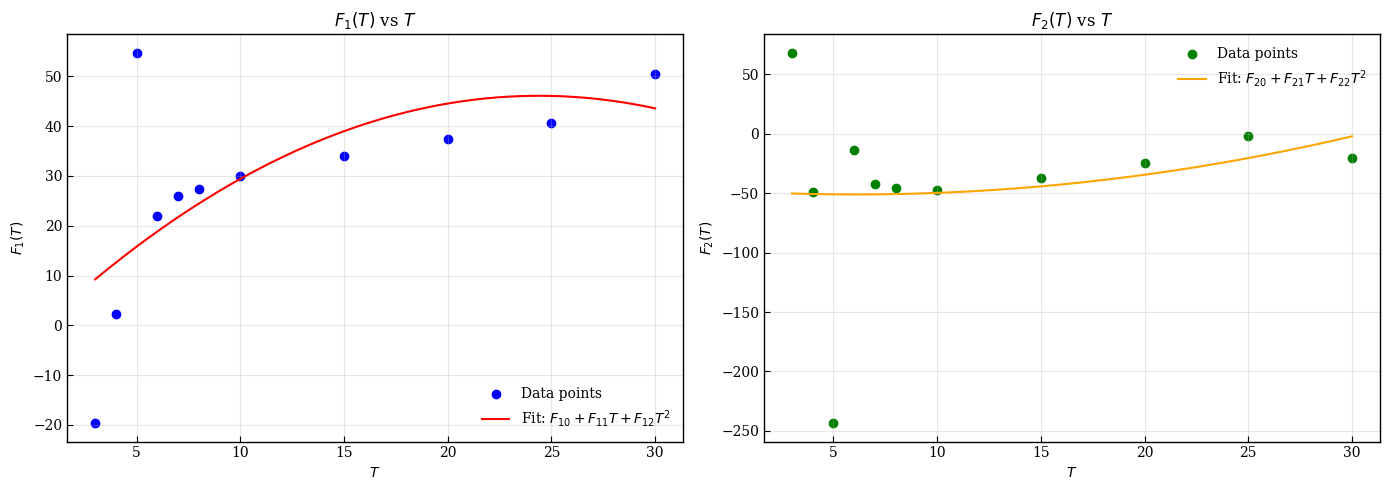

--- Resulting Coefficients ---
F10: -1.840274e+00, F11: 3.930375e+00, F12: -8.054008e-02
F20: -4.785776e+01, F21: -1.036435e+00, F22: 8.543616e-02


In [83]:
# ============================================================
# SECOND STAGE: Fitting F1(T) and F2(T)
# ============================================================

# 1. Extract the results from your previous dictionary
final_T_extracted = np.array(sorted(fit_coeffs_by_T.keys())).reshape(-1, 1)
final_F1_extracted = np.array([fit_coeffs_by_T[t][0] for t in sorted(fit_coeffs_by_T.keys())])
final_F2_extracted = np.array([fit_coeffs_by_T[t][1] for t in sorted(fit_coeffs_by_T.keys())])

# 2. Setup the quadratic model for T (including intercept)
final_poly_T = PolynomialFeatures(degree=2, include_bias=True)
final_X_T = final_poly_T.fit_transform(final_T_extracted)

# 3. Fit F1(T)
final_model_F1 = LinearRegression(fit_intercept=False).fit(final_X_T, final_F1_extracted)
F10, F11, F12 = final_model_F1.coef_

# 4. Fit F2(T)
final_model_F2 = LinearRegression(fit_intercept=False).fit(final_X_T, final_F2_extracted)
F20, F21, F22 = final_model_F2.coef_

# 5. Generate smooth data for plotting the curves
final_T_smooth = np.linspace(final_T_extracted.min(), final_T_extracted.max(), 300).reshape(-1, 1)
final_X_smooth = final_poly_T.transform(final_T_smooth)
final_F1_fit_curve = final_model_F1.predict(final_X_smooth)
final_F2_fit_curve = final_model_F2.predict(final_X_smooth)

# ============================================================
# PLOTTING
# ============================================================
fig, (final_ax1, final_ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1(T) vs T
final_ax1.scatter(final_T_extracted, final_F1_extracted, color='blue', label='Data points')
final_ax1.plot(final_T_smooth, final_F1_fit_curve, 'r-', label=f'Fit: $F_{{10}} + F_{{11}}T + F_{{12}}T^2$')
final_ax1.set_xlabel('$T$')
final_ax1.set_ylabel('$F_1(T)$')
final_ax1.set_title('$F_1(T)$ vs $T$')
final_ax1.legend()
final_ax1.grid(True, alpha=0.3)

# Plot 2: F2(T) vs T
final_ax2.scatter(final_T_extracted, final_F2_extracted, color='green', label='Data points')
final_ax2.plot(final_T_smooth, final_F2_fit_curve, 'orange', label=f'Fit: $F_{{20}} + F_{{21}}T + F_{{22}}T^2$')
final_ax2.set_xlabel('$T$')
final_ax2.set_ylabel('$F_2(T)$')
final_ax2.set_title('$F_2(T)$ vs $T$')
final_ax2.legend()
final_ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the found coefficients
print("--- Resulting Coefficients ---")
print(f"F10: {F10:.6e}, F11: {F11:.6e}, F12: {F12:.6e}")
print(f"F20: {F20:.6e}, F21: {F21:.6e}, F22: {F22:.6e}")

> Could you give me a polynomial plots of R(C,T) w.r.t. C for fixed T, for several other T?

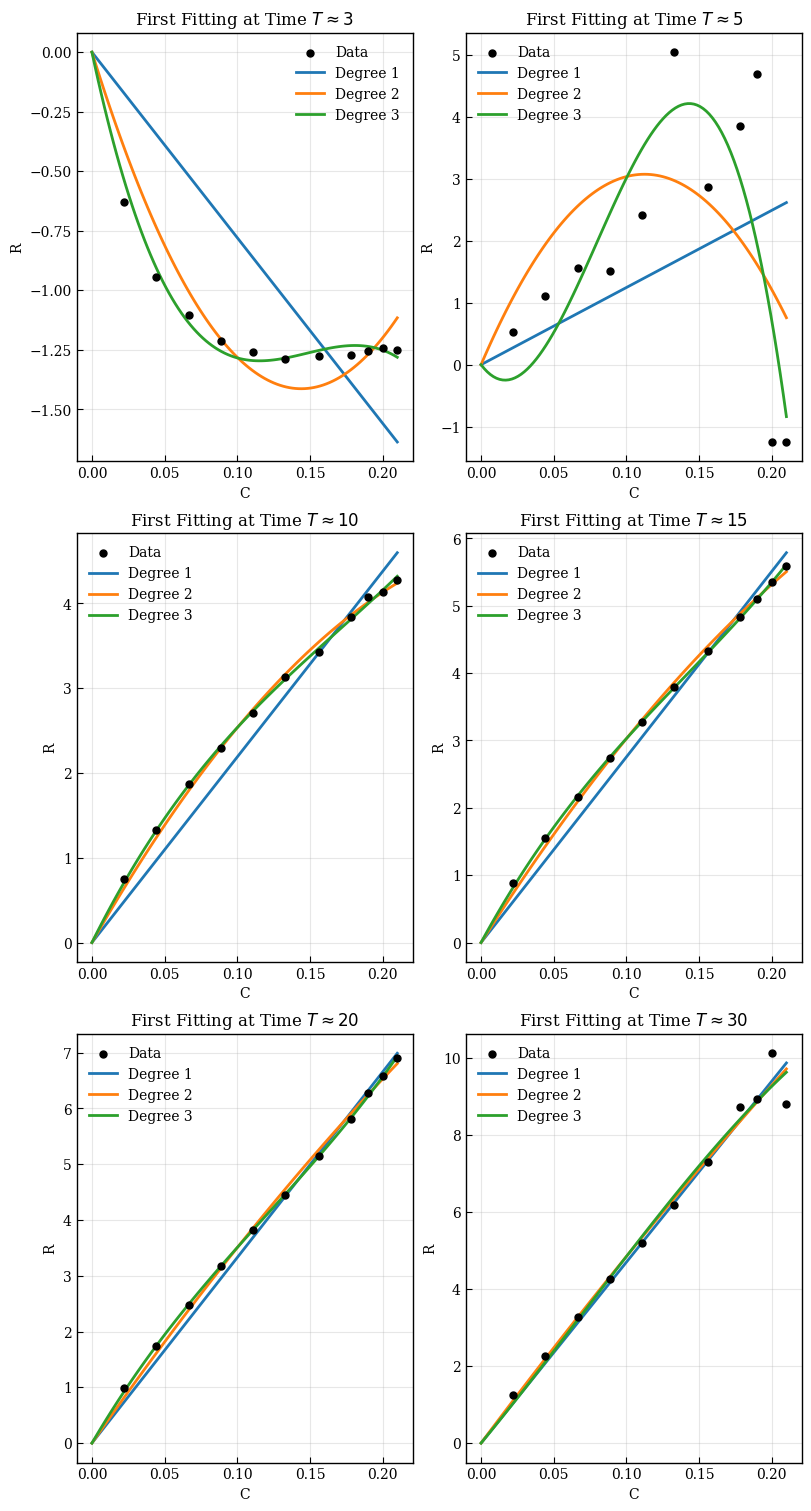

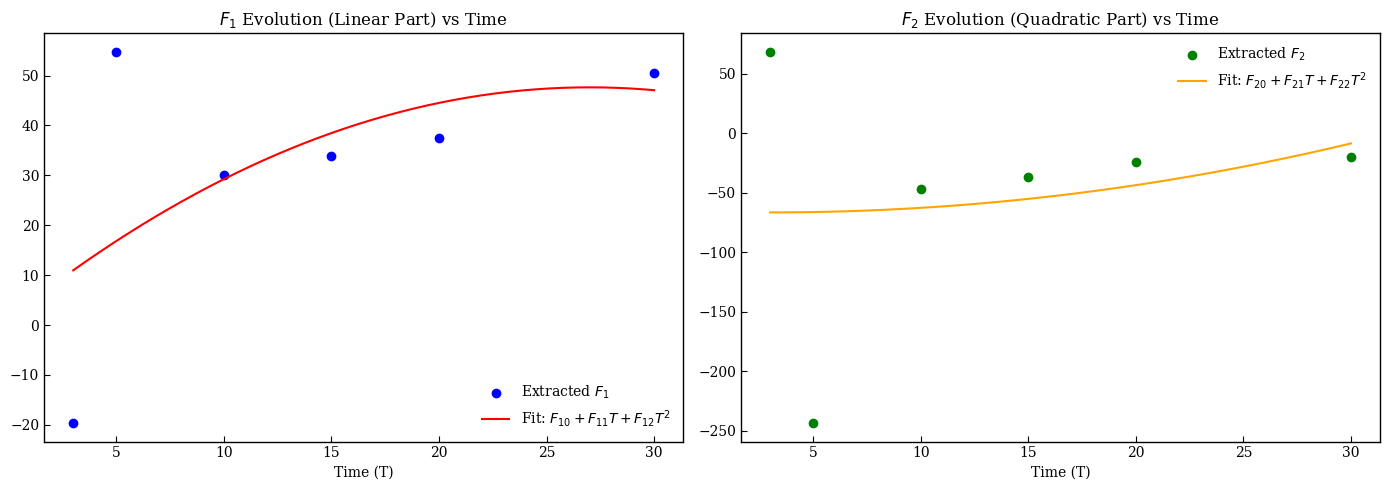

--- Master Coefficients ---
F1(T) = 1.2146e+00 + 3.4382e+00*T + -6.3670e-02*T^2
F2(T) = -6.5828e+01 + -4.9191e-01*T + 7.9924e-02*T^2


In [84]:
# ============================================================
# 0. CONTROL PARAMETERS
# ============================================================
T_list = [3, 5, 10, 15, 20, 30] # Specific Time snapshots to subplot
degrees = [1, 2, 3]                 # Degrees to compare in the snapshots
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]

# ============================================================
# 1. SUBPLOT VISUALIZATION (Stage 1 Comparisons)
# ====================== ======================================
n_plots = len(T_list)
ncols = 2
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

# Store Stage 1 coefficients for Stage 2 (using degree 2 for the global model)
fit_coeffs_by_T = {}

for i, T_target in enumerate(T_list):
    ax = axes[i]
    C_list, R_list = [], []

    for c in target_vals:
        if c == 0.0 or c not in R_by_c_totalZ: continue
        
        T_vals = np.asarray(T_by_c_for_R_totalZ[c], dtype=float)
        R_vals = np.asarray(R_by_c_totalZ[c], dtype=float)
        idx = np.argmin(np.abs(T_vals - T_target))
        
        C_list.append(c)
        R_list.append(R_vals[idx])

    C_fit = np.asarray(C_list).reshape(-1, 1)
    R_fit = np.asarray(R_list)
    ax.scatter(C_fit, R_fit, color="black", s=25, label="Data", zorder=3)
    
    C_smooth = np.linspace(0, C_fit.max(), 100).reshape(-1, 1)
    
    for deg in degrees:
        poly = PolynomialFeatures(degree=deg, include_bias=False)
        X_fit = poly.fit_transform(C_fit)
        model = LinearRegression(fit_intercept=False).fit(X_fit, R_fit)
        
        # Save deg=2 results specifically for the Stage 2 fitting later
        if deg == 2:
            fit_coeffs_by_T[T_target] = model.coef_
            
        R_pred = model.predict(poly.transform(C_smooth))
        ax.plot(C_smooth, R_pred, label=f"Degree {deg}", lw=2)

    # Use double backslash \\approx to avoid the Python escape error
    ax.set_title(f"First Fitting at Time $T \\approx {T_target}$")
    ax.set_xlabel("C")
    ax.set_ylabel("R")
    ax.grid(True, alpha=0.3)
    ax.legend()

# Hide unused axes
for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.show()

# ============================================================
# 2. STAGE 2: FURTHER FITTING (Global Evolution)
# ============================================================
# We use the F1 and F2 from the degree=2 fits stored above
final_T_extracted = np.array(sorted(fit_coeffs_by_T.keys())).reshape(-1, 1)
F1_data = np.array([fit_coeffs_by_T[t][0] for t in sorted(fit_coeffs_by_T.keys())])
F2_data = np.array([fit_coeffs_by_T[t][1] for t in sorted(fit_coeffs_by_T.keys())])

# Setup quadratic evolution for Time (T)
poly_T = PolynomialFeatures(degree=2, include_bias=True)
X_T = poly_T.fit_transform(final_T_extracted)

# Fit F1(T) and F2(T)
model_F1 = LinearRegression(fit_intercept=False).fit(X_T, F1_data)
model_F2 = LinearRegression(fit_intercept=False).fit(X_T, F2_data)

F10, F11, F12 = model_F1.coef_
F20, F21, F22 = model_F2.coef_

# ============================================================
# 3. GLOBAL PLOTS (F1 and F2 Trends)
# ============================================================


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
T_smooth = np.linspace(final_T_extracted.min(), final_T_extracted.max(), 300).reshape(-1, 1)
X_smooth_T = poly_T.transform(T_smooth)

# Plot F1 evolution
ax1.scatter(final_T_extracted, F1_data, color='blue', label='Extracted $F_1$')
ax1.plot(T_smooth, model_F1.predict(X_smooth_T), 'r-', label='Fit: $F_{10}+F_{11}T+F_{12}T^2$')
ax1.set_title('$F_1$ Evolution (Linear Part) vs Time')
ax1.set_xlabel('Time (T)')
ax1.legend()

# Plot F2 evolution
ax2.scatter(final_T_extracted, F2_data, color='green', label='Extracted $F_2$')
ax2.plot(T_smooth, model_F2.predict(X_smooth_T), 'orange', label='Fit: $F_{20}+F_{21}T+F_{22}T^2$')
ax2.set_title('$F_2$ Evolution (Quadratic Part) vs Time')
ax2.set_xlabel('Time (T)')
ax2.legend()

plt.tight_layout()
plt.show()

print("--- Master Coefficients ---")
print(f"F1(T) = {F10:.4e} + {F11:.4e}*T + {F12:.4e}*T^2")
print(f"F2(T) = {F20:.4e} + {F21:.4e}*T + {F22:.4e}*T^2")

---

>Could you expand this graph for the range T in [0,10]

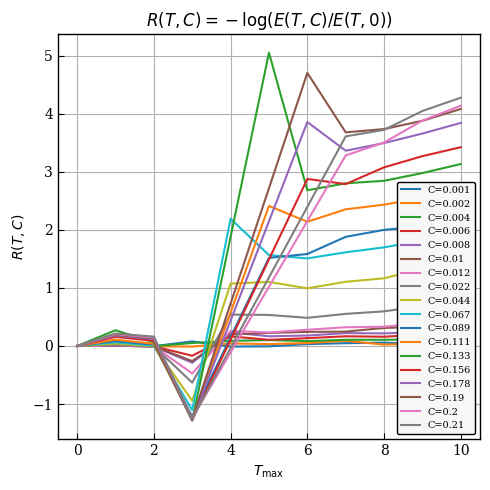

In [85]:
# ===============================
# User-defined T window
# ===============================
T_start = 0
T_end   = 10

# ===============================
# Containers to STORE R(T,C)
# ===============================
R_by_c_totalZ = {}
T_by_c_for_R_totalZ = {}

# ===============================
# Reference data at C = 0 (sign-filtered)
# ===============================
E0_all = np.array(vqe_means_sign_filtered_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_sign_filtered_by_c_totalZ[0.0], dtype=float)

plt.figure(figsize=(5, 5))

# ===============================
# Loop over C values
# ===============================
for c in sorted(vqe_means_sign_filtered_by_c_totalZ.keys()):
    if c == 0.0:
        continue

    E_c_all = np.array(vqe_means_sign_filtered_by_c_totalZ[c], dtype=float)
    T_c_all = np.array(t_vals_sign_filtered_by_c_totalZ[c], dtype=float)

    # -------------------------------
    # Align safely
    # -------------------------------
    N = min(len(T_c_all), len(T0_all))
    T_c_all = T_c_all[:N]
    E_c_all = E_c_all[:N]
    E0_cut  = E0_all[:N]

    # -------------------------------
    # Select T window
    # -------------------------------
    window_mask = (T_c_all >= T_start) & (T_c_all <= T_end)
    if not np.any(window_mask):
        continue

    T_c = T_c_all[window_mask]
    E_c = E_c_all[window_mask]
    E0  = E0_cut[window_mask]

    # -------------------------------
    # Compute R(T,C) ONCE
    # -------------------------------
    R = -np.log(E_c / E0)

    # -------------------------------
    # STORE for later fitting
    # -------------------------------
    R_by_c_totalZ[c] = R
    T_by_c_for_R_totalZ[c] = T_c

    # -------------------------------
    # Plot
    # -------------------------------
    plt.plot(T_c, R, label=f"C={c}")

# ===============================
# Final plot formatting
# ===============================
plt.grid(True)
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,0))$")
plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)
plt.tight_layout()
plt.show()

> Could you expand this graph for T in [0,6]

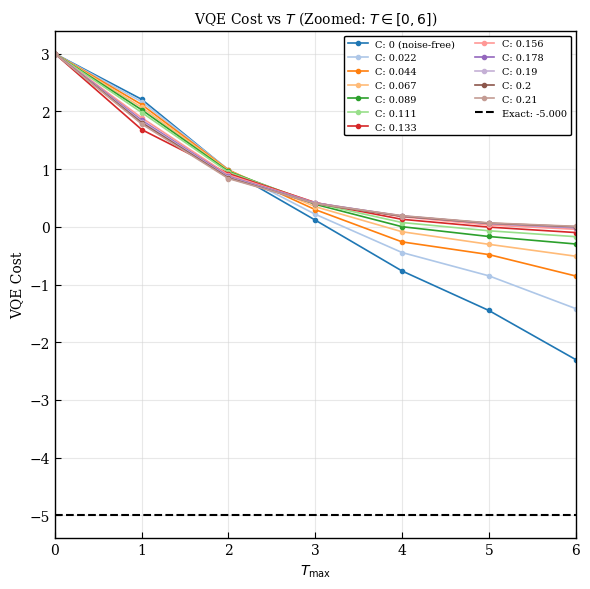

In [86]:
plt.figure(figsize=(6, 6))

# ============================================================
# Target C values
# ============================================================
target_vals = [
    0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
    0.133, 0.156, 0.178, 0.190, 0.200, 0.210
]

Cs = [c for c in target_vals if c in vqe_means_filtered_by_c_totalZ]
colors = plt.cm.tab20.colors[:len(Cs)]

# ============================================================
# Plot filtered VQE means
# ============================================================
for c, color in zip(Cs, colors):
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    
    # Simple line plot - no glowing or special effects
    plt.plot(
        t_vals_filtered_by_c_totalZ[c],
        vqe_means_filtered_by_c_totalZ[c],
        linewidth=1.2,
        alpha=1.0,
        color=color,
        label=label,
        marker='o',      # Added small markers to see data points
        markersize=3
    )

# ============================================================
# Exact solution
# ============================================================
plt.axhline(
    y=EXACT_SOLUTION_totalZ,
    linestyle='--',
    linewidth=1.5,
    color='black',
    label=f'Exact: {EXACT_SOLUTION_totalZ:.3f}',
    zorder=10
)

# ============================================================
# Styling & Zoom [0, 6]
# ============================================================
plt.xlim(0, 6)  # The Zoom command

# Optional: Auto-adjust Y limits based on the zoom window [0,6]
# This prevents the Y-axis from staying too large if the noise grows later
#plt.ylim(0.4, 0.8) # Adjust these values based on your specific VQE Cost range

plt.xlabel(r"$T_{\max}$")
plt.ylabel("VQE Cost")
plt.title(fr"VQE Cost vs $T$ (Zoomed: $T \in [0, 6]$)", fontsize=10)

plt.grid(True, linestyle='-', color='lightgray', alpha=0.5)

# Opaque legend with alpha=1
plt.legend(
    #loc="lower left",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='white',
    framealpha=1.0, # Fully opaque background
    ncol=2
)
plt.tight_layout()
plt.show()

---

> The behavior of polynomial fitting seems very sensitive with respect to T.
>
> Could you calculate the error bar (standard deviation) for R(T,C)?
>
> The standard deviation of R(T,C) may be calculated as follows:
>
> ΔR(T,C) = √[ (ΔE_noisy(T,C) / E_noisy(T,C))^2 + (ΔE_noiseless(T,C) / E_noiseless(T,C))^2 ]
>
> I am slightly wondering about the reliability of data for T = 3 and T = 5.
>
> Note: In the above formula, ΔE_noisy(T,C) and ΔE_noiseless(T,C) are the standard deviations of E_noisy and E_noiseless, respectively.
> Please note that the sum inside the square root:
>
> (ΔE_noisy(T,C)/E_noisy(T,C))^2 + (ΔE_noiseless(T,C)/E_noiseless(T,C))^2
>
> is entirely under the √.

$$\Delta R(T,C) = \sqrt{ \left( \frac{\Delta E_{noisy}(T,C)}{E_{noisy}(T,C)} \right)^2 + \left( \frac{\Delta E_{noiseless}(T,C)}{E_{noiseless}(T,C)} \right)^2 }$$

In [87]:
# Data Containters dicts
# vqe_means_by_c_totalZ
# vqe_stds_by_c_totalZ
# t_vals_by_c_totalZ

# Filtered
# vqe_means_sign_filtered_by_c_totalZ
# vqe_stds_sign_filtered_by_c_totalZ
# t_vals_sign_filtered_by_c_totalZ

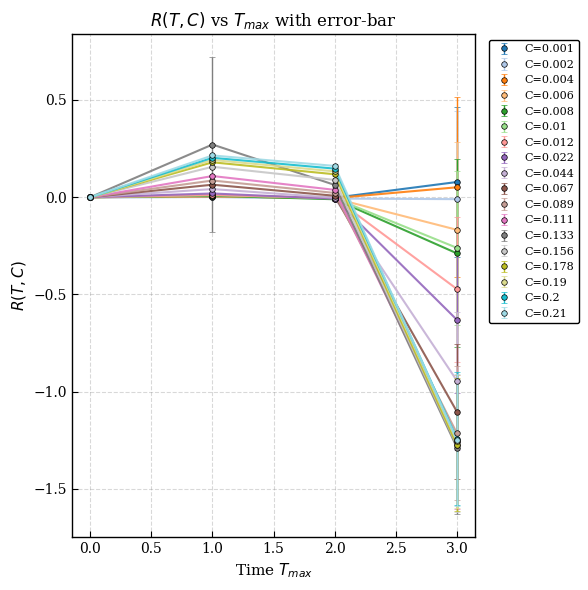

In [88]:
# ============================================================
# 1. DATA PREPARATION (Sign-Filtered)
# ============================================================
E0_all = np.array(vqe_means_sign_filtered_by_c_totalZ[0.0], dtype=float)
dE0_all = np.array(vqe_stds_sign_filtered_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_sign_filtered_by_c_totalZ[0.0], dtype=float)

target_Cs = sorted([c for c in vqe_means_sign_filtered_by_c_totalZ.keys() if c > 0])

# --- HIGH READABILITY COLOR PICKER ---
# tab20 provides 20 distinct, high-contrast colors. 
# If you have fewer than 10, 'tab10' is even bolder.
colors = plt.cm.tab20(np.linspace(0, 1, len(target_Cs)))

plt.figure(figsize=(6, 6))

# ============================================================
# 2. CALCULATION AND PLOTTING
# ============================================================
for i, c in enumerate(target_Cs):
    Ec_all = np.array(vqe_means_sign_filtered_by_c_totalZ[c], dtype=float)
    dEc_all = np.array(vqe_stds_sign_filtered_by_c_totalZ[c], dtype=float)
    Tc_all = np.array(t_vals_sign_filtered_by_c_totalZ[c], dtype=float)

    # Alignment
    N = min(len(Tc_all), len(T0_all))
    Tc, Ec, dEc = Tc_all[:N], Ec_all[:N], dEc_all[:N]
    E0, dE0 = E0_all[:N], dE0_all[:N]

    # Mask for positive log-safety
    mask = (Ec > 0) & (E0 > 0)
    
    # Calculate R and Delta R (Square root of relative variances)
    R = -np.log(Ec[mask] / E0[mask])
    Delta_R = np.sqrt((dEc[mask] / Ec[mask])**2 + (dE0[mask] / E0[mask])**2)
    
    T_plot = Tc[mask]

    # --- Plotting with High Contrast ---
    # 1. Main Line (Solid color)
    plt.plot(T_plot, R, color=colors[i], lw=1.5, alpha=0.9, zorder=2)
    
    # 2. Dotted Points (R)
    # 3. Error bars (Same color, subtle alpha)
    plt.errorbar(
        T_plot, R, yerr=Delta_R, 
        fmt='o', 
        color=colors[i], 
        markersize=4,        # Bigger dots for better visibility
        label=f"C={c:g}", 
        alpha=1.0, 
        capsize=2,           # Small caps help define the error range
        elinewidth=1,
        markeredgecolor='black', # Black edge makes dots "pop"
        markeredgewidth=0.5
    )

# ============================================================
# 3. STYLING
# ============================================================
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.xlabel(r"Time $T_{max}$", fontsize=11)
plt.ylabel(r"$R(T, C)$", fontsize=11)
plt.title(r"$R(T, C)$ vs $T_{max}$ with error-bar", fontsize=12)

# Legend: Opaque, Outside, Multi-column if necessary
plt.legend(
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    fontsize=8, 
    frameon=True, 
    edgecolor='black',
    facecolor='white',
    framealpha=1.0, 
    ncol=1
)

plt.tight_layout()
plt.show()

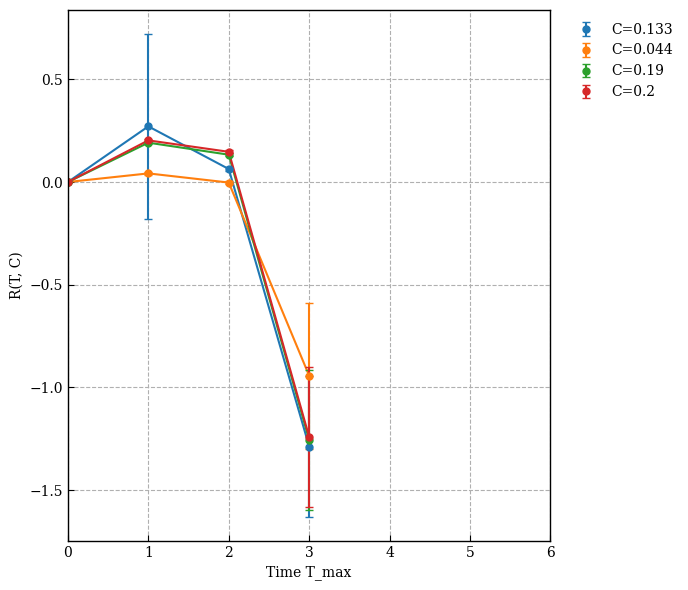

In [89]:
T_min = 0
T_max = 6
C_selection = [0.133, 0.044, 0.19, 0.2] # Set your target C values here

E0_all = np.array(vqe_means_sign_filtered_by_c_totalZ[0.0], dtype=float)
dE0_all = np.array(vqe_stds_sign_filtered_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_sign_filtered_by_c_totalZ[0.0], dtype=float)

available_Cs = sorted([c for c in vqe_means_sign_filtered_by_c_totalZ.keys() if c > 0])
plot_Cs = [c for c in C_selection if c in available_Cs] if C_selection else available_Cs

# Distinct colors list
colors = plt.cm.tab10.colors if len(plot_Cs) <= 10 else plt.cm.tab20.colors

plt.figure(figsize=(7, 6))

for i, c in enumerate(plot_Cs):
    color = colors[i % len(colors)] # Cycle colors if Cs > 20
    
    Ec_all = np.array(vqe_means_sign_filtered_by_c_totalZ[c], dtype=float)
    dEc_all = np.array(vqe_stds_sign_filtered_by_c_totalZ[c], dtype=float)
    Tc_all = np.array(t_vals_sign_filtered_by_c_totalZ[c], dtype=float)

    N = min(len(Tc_all), len(T0_all))
    Tc, Ec, dEc = Tc_all[:N], Ec_all[:N], dEc_all[:N]
    E0, dE0 = E0_all[:N], dE0_all[:N]

    mask = (Ec > 0) & (E0 > 0) & (Tc >= T_min) & (Tc <= T_max)
    
    if not np.any(mask):
        continue
    
    R = -np.log(Ec[mask] / E0[mask])
    Delta_R = np.sqrt((dEc[mask] / Ec[mask])**2 + (dE0[mask] / E0[mask])**2)
    
    plt.plot(Tc[mask], R, color=color, lw=1.5)
    plt.errorbar(Tc[mask], R, yerr=Delta_R, fmt='o', color=color, 
                 markersize=5, label=f"C={c}", capsize=3)

# Force axis to T_max even if data ends early
plt.xlim(T_min, T_max) 
plt.grid(True, linestyle='--')
plt.xlabel("Time T_max")
plt.ylabel("R(T, C)")
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

---

> Since  
> R(T,C) ≈ −log(E_noisy(T,C) / ZNE),
>
> exp(−R(T,C)) ≈ E_noisy(T,C) / ZNE.
>
> This means
>
> E_noisy(T,C) = ZNE · exp(−R(T,C)).
>
> If we can make a good function for fitting R(T,C),
>
> we may also fit E_noisy(T,C) by the same function with ZNE.

#### Polynomial Fitting of $R(T, C)$

Since $R(T, C=0) = 0$ for all $T$,  
the constant term must vanish in the polynomial expansion.

Therefore, we impose $F_0(T) = 0$, and write

$$
R(T, C) = C\,F_1(T) + C^2 F_2(T) + C^3 F_3(T) + C^4 F_4(T) + \cdots
$$

This enforces the physical constraint that the noise response
vanishes when $C = 0$.

> From these data, you can further fit:
> 
> $$F_1(T) = F_{10} + F_{11}T + F_{12}T^2$$
> $$F_2(T) = F_{20} + F_{21}T + F_{22}T^2$$
> 
> and find the coefficients $F_{10}, F_{11}, F_{12}, F_{20}, F_{21}, \text{and } F_{22}$.
> 
> I would like you to plot $F_1(T)$ and $F_2(T)$ where:
> * **Plot 1:** y-axis is $F_1(T)$ and x-axis is $T$.
> * **Plot 2:** y-axis is $F_2(T)$ and x-axis is $T$.
>
>
>
>





> This is second degree in C and second degree in T.
>
> We can decrease the number of coefficients if we want.
>
> In general, by increasing the number of coefficients, the fitting may become more difficult.
>
> There may exist some optimal degree.
>
> If we choose second degree in C and second degree in T, there are six coefficients in R(T,C).
>
> This may be too large, but I do not know—let us try.
>
> So, we should always keep in mind that we can decrease the number of coefficients.



> (1) First, we fit R(T,C) for different values of T using a polynomial of degree 2 in C.  
> This gives us F₁(T) and F₂(T) for various T.
>
> (2) Then, we further fit F₁(T) and F₂(T) as functions of T. Possible choices are:
>
> F₁(T) = F₁₀ + F₁₁ T + F₁₂ T²  
> F₂(T) = F₂₀ + F₂₁ T + F₂₂ T²
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T  
> F₂(T) = F₂₀ + F₂₁ T + F₂₂ T²
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T + F₁₂ T²  
> F₂(T) = F₂₀ + F₂₁ T
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T  
> F₂(T) = F₂₀ + F₂₁ T
>
> or
>
> F₁(T) = F₁₀  
> F₂(T) = F₂₀ + F₂₁ T
>
> or
>
> F₁(T) = F₁₀ + F₁₁ T  
> F₂(T) = F₂₀


---

## `nbutils.rtc_fitting.py`

Fitting of $R(T,C)$ and $F(T)$ are computed using `nbutils.rtc_fitting.py` module.

Filtered data

In [90]:
assert len(vqe_means_sign_filtered_by_c_totalZ)==len(vqe_stds_sign_filtered_by_c_totalZ)==len(t_vals_sign_filtered_by_c_totalZ)

**Data Integrity Verification**

Before proceeding to the hierarchical fitting (Stage 1 and Stage 2), we must verify the **internal consistency** of our filtered data containers. 

 **Validation Logic:**
For every concentration key $C$, the measurements ($R$), their uncertainties ($\sigma$), and the time-stamps ($T$) must have a **one-to-one correspondence**. This means that for any specific $C$:
* `len(vqe_means_sign_filtered_by_c_totalZ[C])`
* `len(vqe_stds_sign_filtered_by_c_totalZ[C])`
* `len(t_vals_sign_filtered_by_c_totalZ[C])`

**Must all be equal.** If these lengths differ, an `IndexError` will occur during Stage 1 because the arrays are no longer aligned along the same "Time" axis. Note that different $C$ keys can have different total lengths (due to filtering), but the internal lists for a specific $C$ must remain synchronized.

In [91]:
# List of all unique C values across the dictionaries
all_keys = vqe_means_sign_filtered_by_c_totalZ.keys()

for c in all_keys:
    len_means = len(vqe_means_sign_filtered_by_c_totalZ[c])
    len_stds = len(vqe_stds_sign_filtered_by_c_totalZ[c])
    len_tvals = len(t_vals_sign_filtered_by_c_totalZ[c])
    if not (len_means == len_stds == len_tvals):
        print(f"❌ Consistency Error at C={c}:")
        print(f"   - Means length: {len_means}")
        print(f"   - STDs length:  {len_stds}")
        print(f"   - T-vals length: {len_tvals}")
    else:
        # Optional: confirmation for every valid key
        # print(f"✅ C={c} is consistent (length {len_means})")
        pass

print("Check complete.")

Check complete.


In [92]:
R_by_c_totalZ

{0.001: array([ 4.54019567e-09,  1.20797271e-03, -2.72506087e-03,  7.82681644e-02,
        -9.93534500e-03, -5.59955977e-03,  3.21640881e-02,  4.79390449e-02,
         5.74941088e-02,  3.10321187e-02,  3.61292994e-02]),
 0.002: array([-9.56883168e-09,  3.58303925e-03, -6.96296188e-03, -9.93450315e-03,
         4.35424794e-02,  3.20877541e-02,  5.05650263e-02,  8.88198340e-02,
         2.38815801e-02,  4.06429775e-02,  6.84732590e-02]),
 0.004: array([ 1.27846496e-08,  4.30881587e-03, -4.44541308e-03,  5.10972707e-02,
         8.80973513e-02,  1.01586978e-01,  8.36249028e-02,  1.07443283e-01,
         1.06417067e-01,  1.15595149e-01,  1.35853521e-01]),
 0.006: array([-2.93245738e-09,  6.00780285e-03, -6.29695769e-03, -1.67635862e-01,
         1.65063918e-01,  1.06585135e-01,  1.34432965e-01,  1.66896735e-01,
         1.59569158e-01,  1.94805275e-01,  2.26252729e-01]),
 0.008: array([-5.47020983e-09,  7.70736570e-03, -1.04629986e-02, -2.88715610e-01,
         2.33380346e-01,  1.66996983e

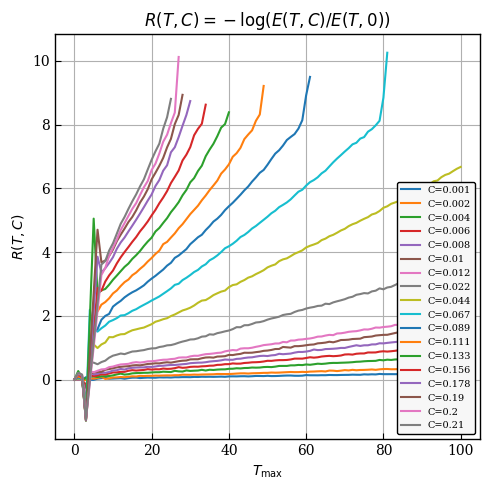

In [93]:
# ===============================
# User-defined T window
# ===============================
T_start = 0
T_end   = 100

# ===============================
# Containers to STORE R(T,C)
# ===============================
R_by_c_totalZ = {}
T_by_c_for_R_totalZ = {}

# ===============================
# Reference data at C = 0 (sign-filtered)
# ===============================
E0_all = np.array(vqe_means_sign_filtered_by_c_totalZ[0.0], dtype=float)
T0_all = np.array(t_vals_sign_filtered_by_c_totalZ[0.0], dtype=float)

plt.figure(figsize=(5, 5))

# ===============================
# Loop over C values
# ===============================
for c in sorted(vqe_means_sign_filtered_by_c_totalZ.keys()):
    if c == 0.0:
        continue

    E_c_all = np.array(vqe_means_sign_filtered_by_c_totalZ[c], dtype=float)
    T_c_all = np.array(t_vals_sign_filtered_by_c_totalZ[c], dtype=float)

    # -------------------------------
    # Align safely
    # -------------------------------
    N = min(len(T_c_all), len(T0_all))
    T_c_all = T_c_all[:N]
    E_c_all = E_c_all[:N]
    E0_cut  = E0_all[:N]

    # -------------------------------
    # Select T window
    # -------------------------------
    window_mask = (T_c_all >= T_start) & (T_c_all <= T_end)
    if not np.any(window_mask):
        continue

    T_c = T_c_all[window_mask]
    E_c = E_c_all[window_mask]
    E0  = E0_cut[window_mask]

    # -------------------------------
    # Compute R(T,C) ONCE
    # -------------------------------
    R = -np.log(E_c / E0)

    # -------------------------------
    # STORE for later fitting
    # -------------------------------
    R_by_c_totalZ[c] = R
    T_by_c_for_R_totalZ[c] = T_c

    # -------------------------------
    # Plot
    # -------------------------------
    plt.plot(T_c, R, label=f"C={c}")

# ===============================
# Final plot formatting
# ===============================
plt.grid(True)
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,0))$")
plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)
plt.tight_layout()
plt.show()

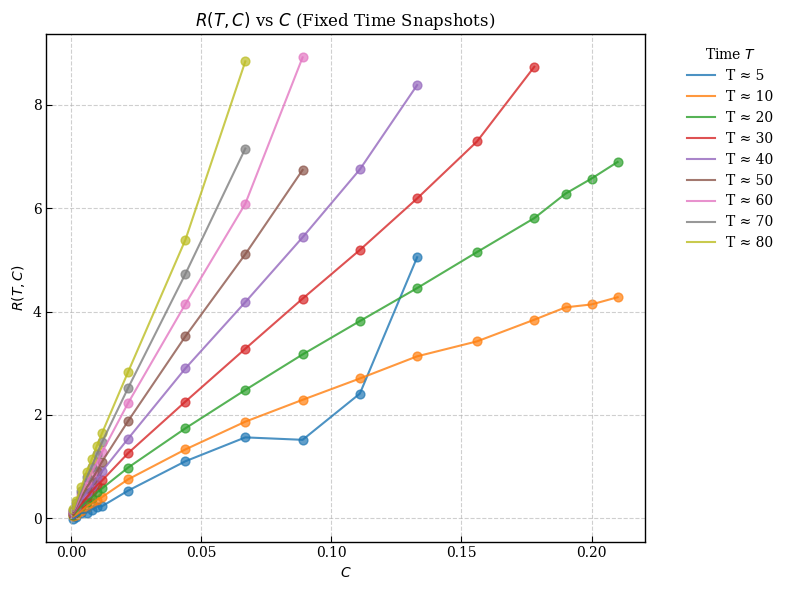

In [94]:
# ============================================================
# Plot R vs C for fixed T values
# ============================================================

# Define the T snapshots you want to visualize
T_snapshots = [5, 10, 20, 30, 40, 50, 60, 70, 80] 

plt.figure(figsize=(8, 6))

for t_target in T_snapshots:
    c_coords = []
    r_coords = []
    
    # Sort keys to ensure the line plot connects points in order
    for c in sorted(R_by_c_totalZ.keys()):
        t_arr = np.array(T_by_c_for_R_totalZ[c])
        r_arr = np.array(R_by_c_totalZ[c])
        
        # Find the index of the T value closest to our target snapshot
        idx = np.argmin(np.abs(t_arr - t_target))
        
        # Only include the point if the match is reasonably close (e.g., within 0.5 units)
        if np.abs(t_arr[idx] - t_target) < 0.5:
            c_coords.append(c)
            r_coords.append(r_arr[idx])
            
    if c_coords:
        # Plot points and a connecting line for each T snapshot
        plt.scatter(c_coords, r_coords, s=40, alpha=0.7)
        plt.plot(c_coords, r_coords, label=f"T ≈ {t_target}", lw=1.5, alpha=0.8)

# Formatting
plt.xlabel("$C$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T,C)$ vs $C$ (Fixed Time Snapshots)")
plt.legend(title="Time $T$", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

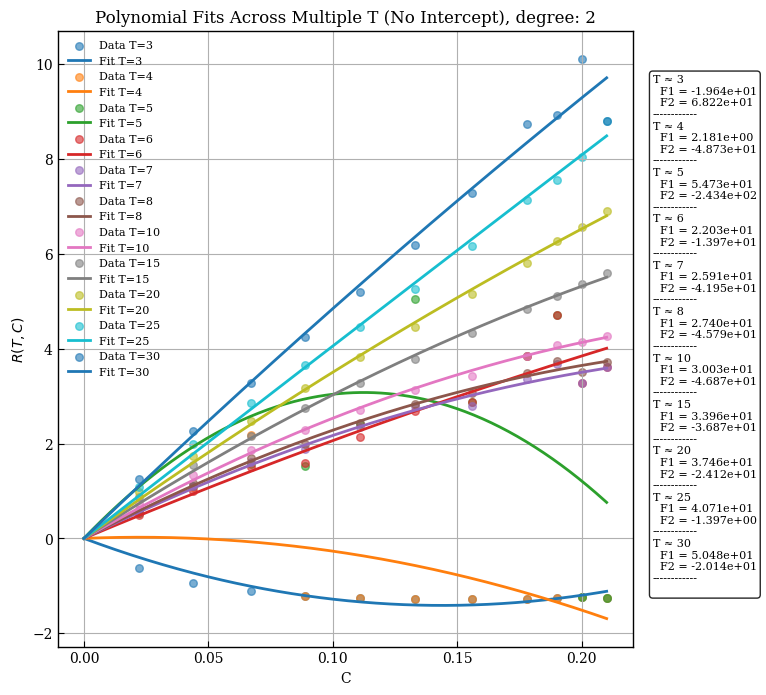

In [95]:
# ======================
# Selection
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30]
T_min = 0
T_max = 100
degree = 2 

target_vals = [
    0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
    0.133, 0.156, 0.178, 0.190, 0.200, 0.210
]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)

coeff_text = ""
fit_coeffs_by_T = {}

# ======================
# Loop over T values
# ======================
for T_target in T_list:

    if T_target < T_min or T_target > T_max:
        continue

    C_list = []
    R_list = []

    for c in target_vals:
        if c == 0.0:
            continue
        if c not in R_by_c_totalZ:
            continue

        T_vals = np.asarray(T_by_c_for_R_totalZ[c], dtype=float)
        R_vals = np.asarray(R_by_c_totalZ[c], dtype=float)

        idx = np.argmin(np.abs(T_vals - T_target))

        C_list.append(c)
        R_list.append(R_vals[idx])

    C_fit = np.asarray(C_list)
    R_fit = np.asarray(R_list)

    if len(C_fit) < degree + 1:
        continue

    # ============================================================
    # Polynomial fit using rtc_fitting.py
    # ============================================================
    # fit_stage1 handles PolynomialFeatures and LinearRegression
    coeffs = rtc.fit_stage1(C_fit, R_fit, degree=degree, include_intercept=False)

    fit_coeffs_by_T[T_target] = coeffs

    coeff_text += f"T ≈ {T_target}\n"
    for k, coef in enumerate(coeffs, start=1):
        coeff_text += f"  F{k} = {coef:.3e}\n"
    coeff_text += "-" * 12 + "\n"

    ax.scatter(C_fit, R_fit, s=30, label=f"Data T={T_target}", alpha=0.6)

    # Smooth curve generation
    C_smooth = np.linspace(0, C_fit.max(), 300)
    
    # Manually reconstructing the polynomial for plotting based on fit_stage1 degree
    R_smooth = np.zeros_like(C_smooth)
    for d in range(1, degree + 1):
        R_smooth += coeffs[d-1] * (C_smooth ** d)

    ax.plot(C_smooth, R_smooth, lw=2, label=f"Fit T={T_target}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel(r"$R(T, C)$")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept), degree: {degree}")
ax.grid(True)
ax.legend(fontsize=8)

fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.show()

In [96]:
# Sort the T values to ensure chronological order
T_final = np.array(sorted(fit_coeffs_by_T.keys()))

# Extract F1 and F2 into individual arrays
F1_values = np.array([fit_coeffs_by_T[t][0] for t in T_final])
F2_values = np.array([fit_coeffs_by_T[t][1] for t in T_final])

print("T values:", T_final)
print("F1 values:", F1_values)
print("F2 values:", F2_values)

T values: [ 3  4  5  6  7  8 10 15 20 25 30]
F1 values: [-19.63875679   2.18054407  54.73474871  22.02696015  25.90620666
  27.39524214  30.03043283  33.96431037  37.46096402  40.71383556
  50.47971497]
F2 values: [  68.21663096  -48.7297295  -243.43252594  -13.97075801  -41.95247484
  -45.79274522  -46.86511233  -36.86908888  -24.11706646   -1.39684486
  -20.13838275]


In [97]:
# Find global coefficients for F1 vs T
# Returns [F10, F11, F12] if degree=2
F1_global = rtc.fit_stage2(T_final, F1_values, degree=2)

# Find global coefficients for F2 vs T
F2_global = rtc.fit_stage2(T_final, F2_values, degree=2)

print(f"Global F1 parameters: {F1_global}")
print(f"Global F2 parameters: {F2_global}")

Global F1 parameters: [-1.8402737   3.93037494 -0.08054008]
Global F2 parameters: [-47.85776186  -1.03643507   0.08543616]


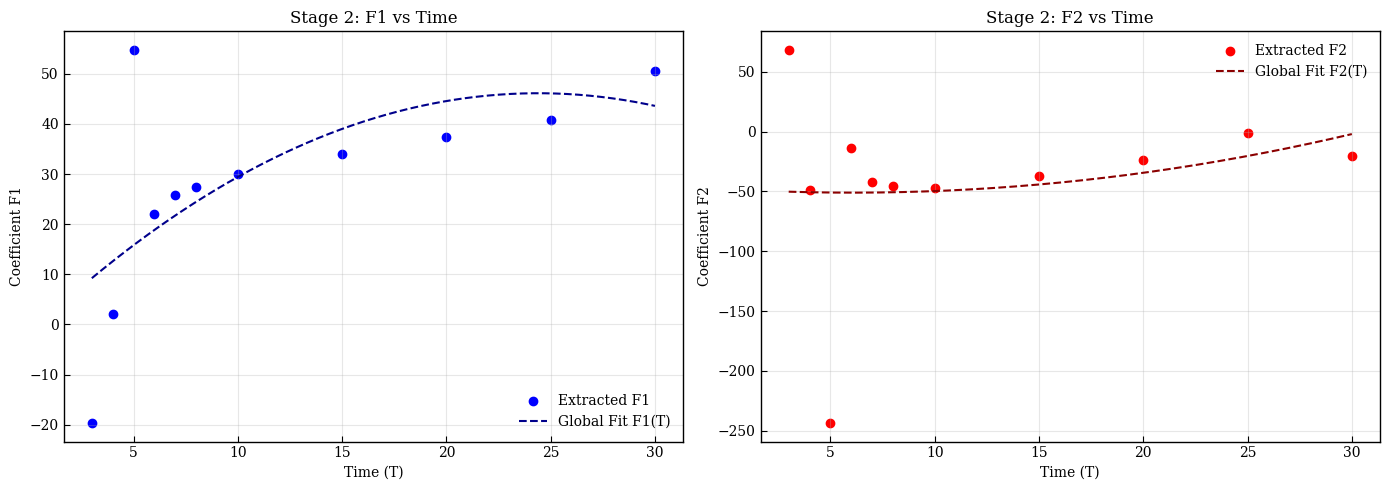

Global F1 Coefficients (F10, F11, F12): [-1.8402737   3.93037494 -0.08054008]
Global F2 Coefficients (F20, F21, F22): [-47.85776186  -1.03643507   0.08543616]


In [98]:
# 1. Extract data from the Stage 1 dictionary
# We sort the keys to ensure the T-axis is chronological
T_final = np.array(sorted(fit_coeffs_by_T.keys()))

# fit_stage1 returned [F1, F2] because degree was 2 and include_intercept was False
F1_values = np.array([fit_coeffs_by_T[t][0] for t in T_final])
F2_values = np.array([fit_coeffs_by_T[t][1] for t in T_final])

# 2. Perform Stage 2 Fitting (F vs T) using the module
# By default, fit_stage2 uses degree=2 (F = F10 + F11*T + F12*T^2)
F1_global_coeffs = rtc.fit_stage2(T_final, F1_values, degree=2)
F2_global_coeffs = rtc.fit_stage2(T_final, F2_values, degree=2)

# 3. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot F1 vs T ---
ax1.scatter(T_final, F1_values, color='blue', label='Extracted F1')
T_smooth = np.linspace(T_final.min(), T_final.max(), 200)
# F1(T) = F10 + F11*T + F12*T^2
F1_smooth = F1_global_coeffs[0] + F1_global_coeffs[1]*T_smooth + F1_global_coeffs[2]*T_smooth**2
ax1.plot(T_smooth, F1_smooth, color='darkblue', linestyle='--', label='Global Fit F1(T)')
ax1.set_xlabel("Time (T)")
ax1.set_ylabel("Coefficient F1")
ax1.set_title("Stage 2: F1 vs Time")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot F2 vs T ---
ax2.scatter(T_final, F2_values, color='red', label='Extracted F2')
# F2(T) = F20 + F21*T + F22*T^2
F2_smooth = F2_global_coeffs[0] + F2_global_coeffs[1]*T_smooth + F2_global_coeffs[2]*T_smooth**2
ax2.plot(T_smooth, F2_smooth, color='darkred', linestyle='--', label='Global Fit F2(T)')
ax2.set_xlabel("Time (T)")
ax2.set_ylabel("Coefficient F2")
ax2.set_title("Stage 2: F2 vs Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the resulting global coefficients
print(f"Global F1 Coefficients (F10, F11, F12): {F1_global_coeffs}")
print(f"Global F2 Coefficients (F20, F21, F22): {F2_global_coeffs}")

---

# `perform_rtc_analysis` Wrapper for $R(T,C)$ and $F(T)$ fittings

> we can use the polynomials with degree (C,T)=(1,1),(1,2),(2,1),(2,2) (edited) 
>
> there are at least 4 variation of R(T,C) function models.
>
> We can do all of them (edited) 
>
> We can compare the results of fitting for ZNE.

Fitting around small $T_{max}$

In [99]:
_fig_size = (7, 6)

Validation Successful: All 10 time points found for all 3 noise levels.


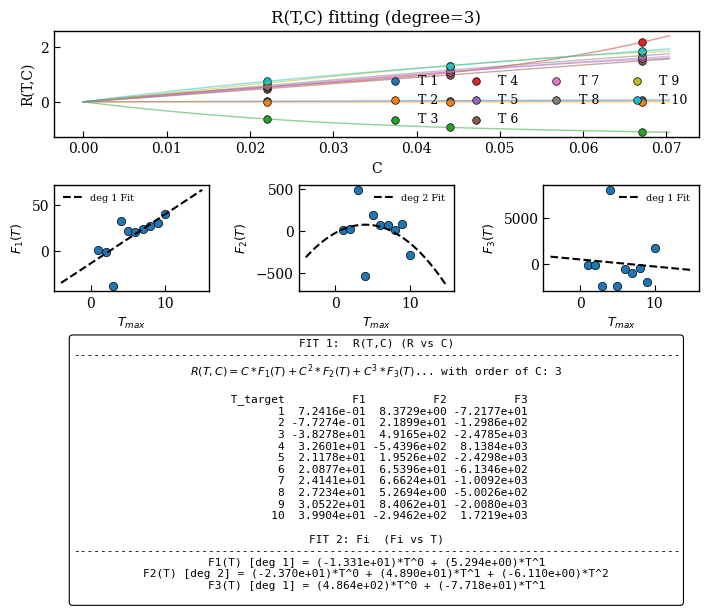

In [100]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[1,2,3,4,5,6,7,8,9,10],
    target_C=[0.022, 0.044, 0.067],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=3,      # Quadratic R vs C
    degree_s2=[1, 2, 1],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 4 time points found for all 4 noise levels.


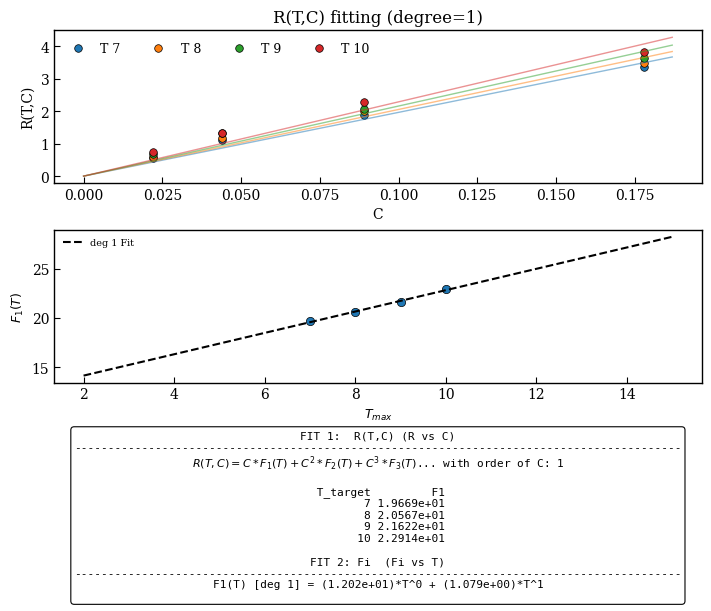

In [101]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[7, 8, 9, 10],
    target_C=[0.022, 0.044, 0.089, 0.178],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=1,      # Quadratic R vs C
    degree_s2=[1, 1],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 4 time points found for all 4 noise levels.


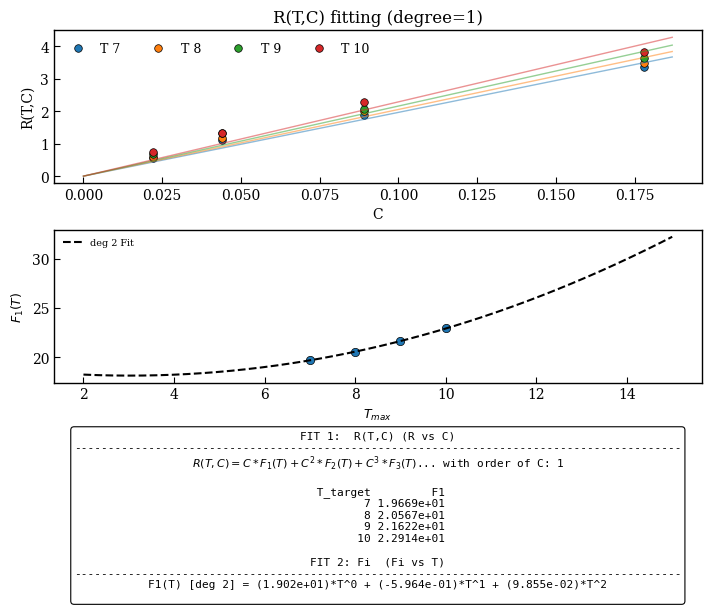

In [102]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[7, 8, 9, 10],
    target_C=[0.022, 0.044, 0.089, 0.178],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=1,      # Quadratic R vs C
    degree_s2=[2, 2],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 4 time points found for all 4 noise levels.


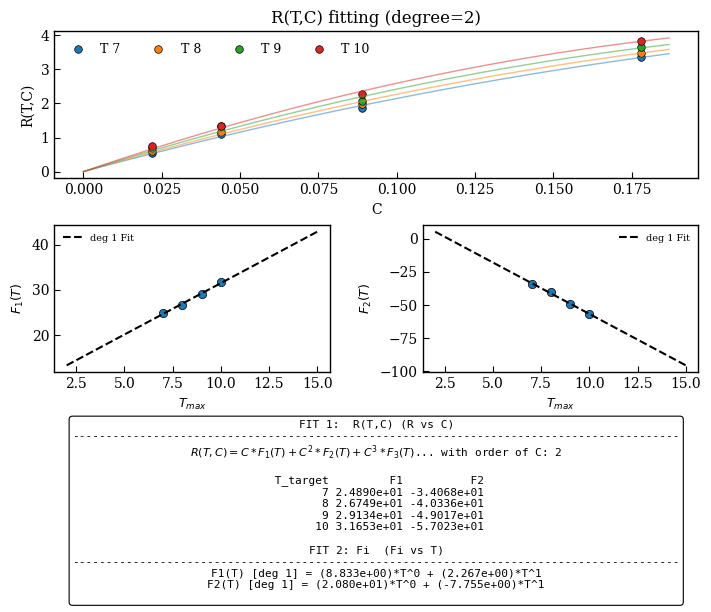

In [103]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[7, 8, 9, 10],
    target_C=[0.022, 0.044, 0.089, 0.178],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[1, 1],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 4 time points found for all 4 noise levels.


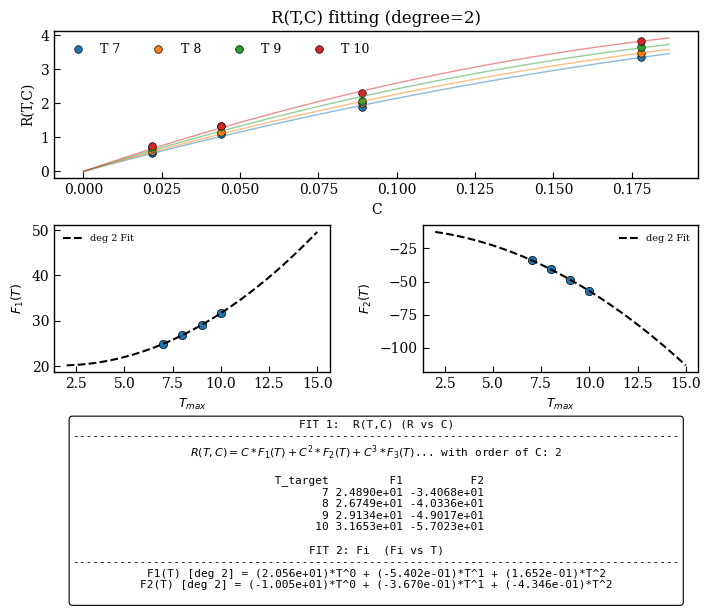

In [104]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[7, 8, 9, 10],
    target_C=[0.022, 0.044, 0.089, 0.178],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[2, 2],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Fitting around larger $T_{max}$

Validation Successful: All 5 time points found for all 3 noise levels.


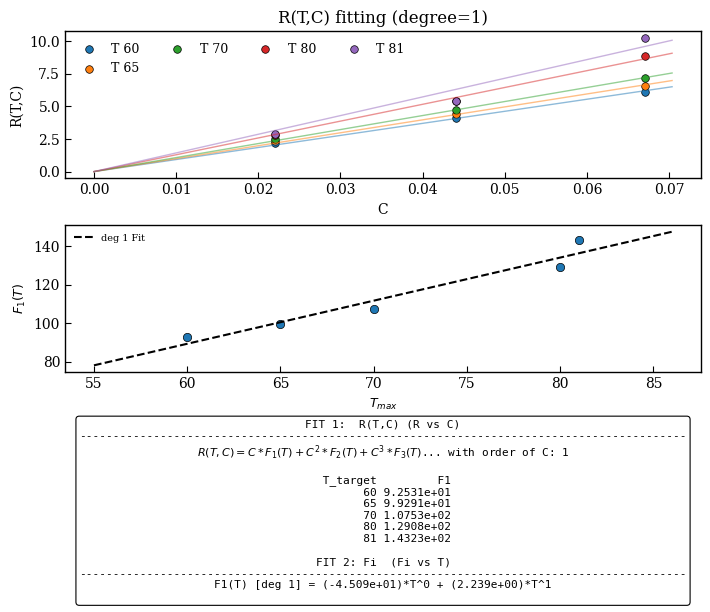

In [105]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.022, 0.044, 0.067],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=1,      # Quadratic R vs C
    degree_s2=[1, 1],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 5 time points found for all 3 noise levels.


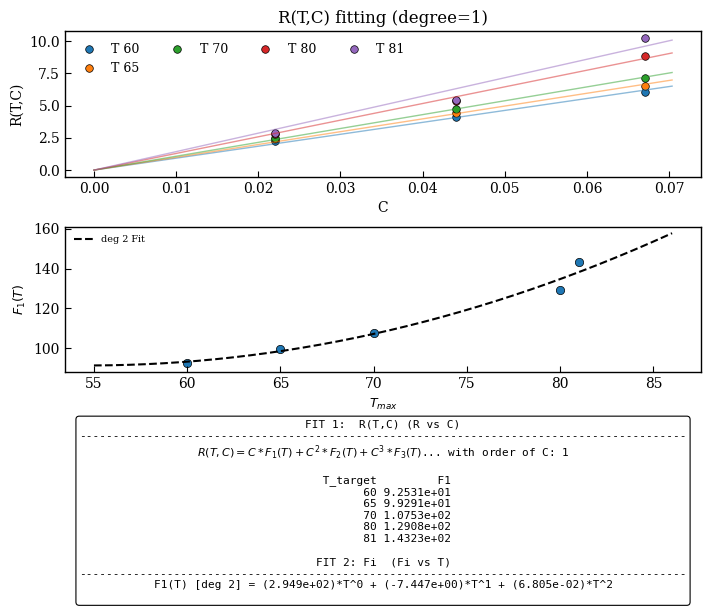

In [106]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.022, 0.044, 0.067],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=1,      # Quadratic R vs C
    degree_s2=[2, 2],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 5 time points found for all 3 noise levels.


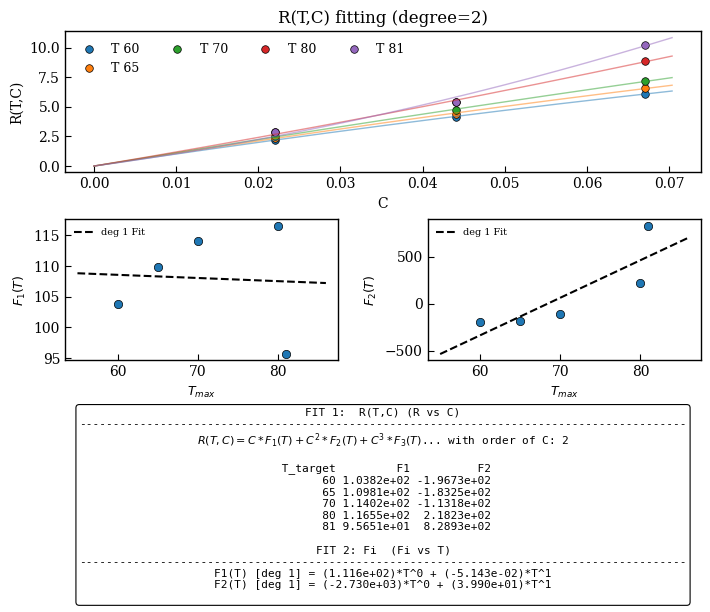

In [107]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.022, 0.044, 0.067],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[1, 1],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 5 time points found for all 3 noise levels.


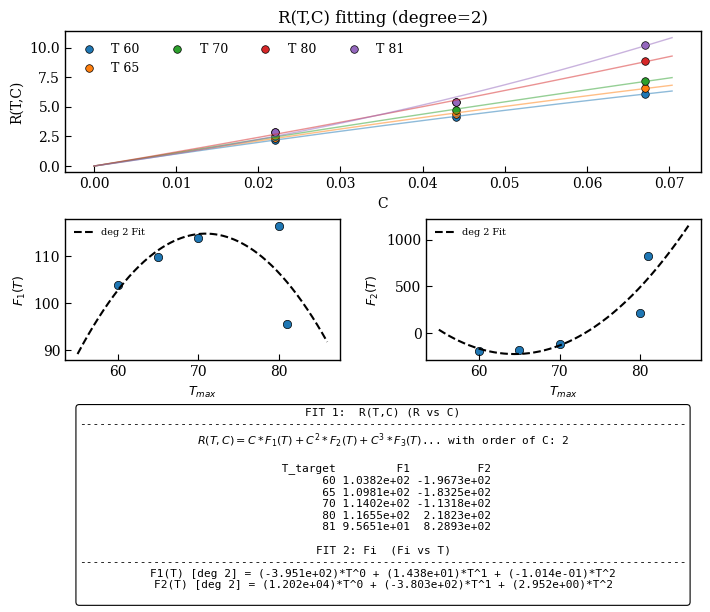

In [108]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.022, 0.044, 0.067],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[2, 2],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 14 time points found for all 3 noise levels.


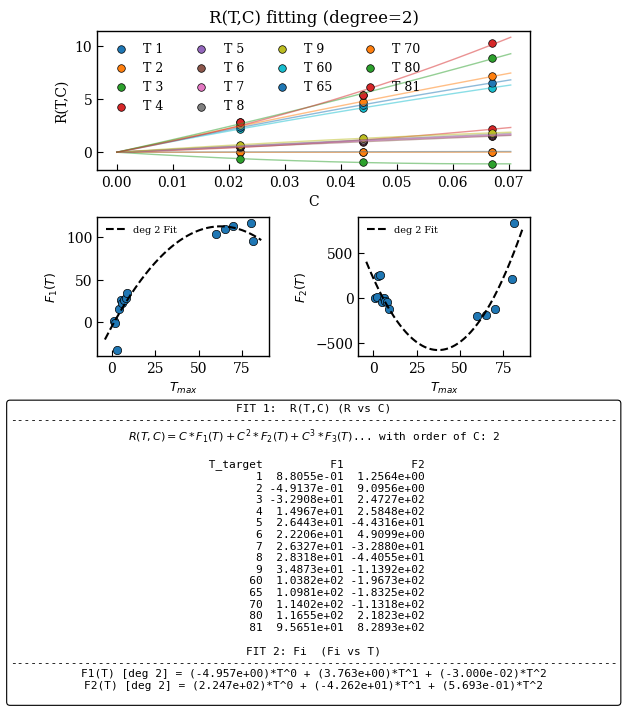

In [109]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[1,2,3,4,5,6,7,8,9,60, 65, 70, 80, 81],
    target_C=[0.022, 0.044, 0.067,],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[2, 2],      # Linear Fi vs T
    figsize=(6, 7),  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

In [110]:
print(sorted(R_by_c_totalZ.keys()))

[0.001, 0.002, 0.004, 0.006, 0.008, 0.01, 0.012, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.19, 0.2, 0.21]


Validation Successful: All 5 time points found for all 6 noise levels.


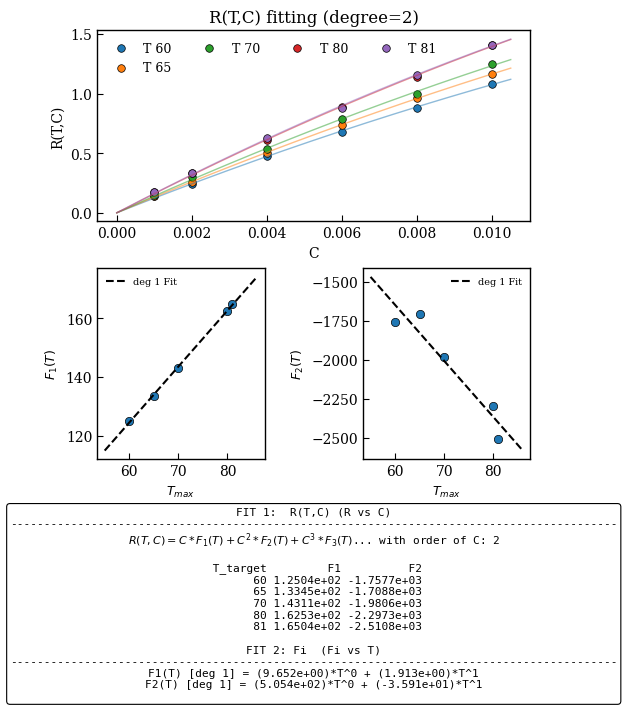

In [111]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.001, 0.002, 0.004, 0.006, 0.008, 0.01],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[1, 1],      # Linear Fi vs T
    figsize=(6, 7),  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 5 time points found for all 6 noise levels.


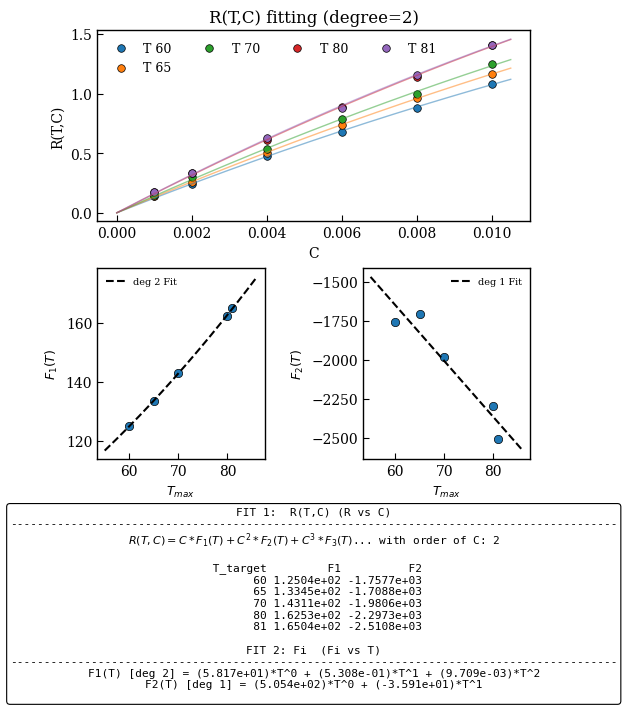

In [112]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.001, 0.002, 0.004, 0.006, 0.008, 0.01],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[2, 1],      # Linear Fi vs T
    figsize=(6, 7),  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 5 time points found for all 6 noise levels.


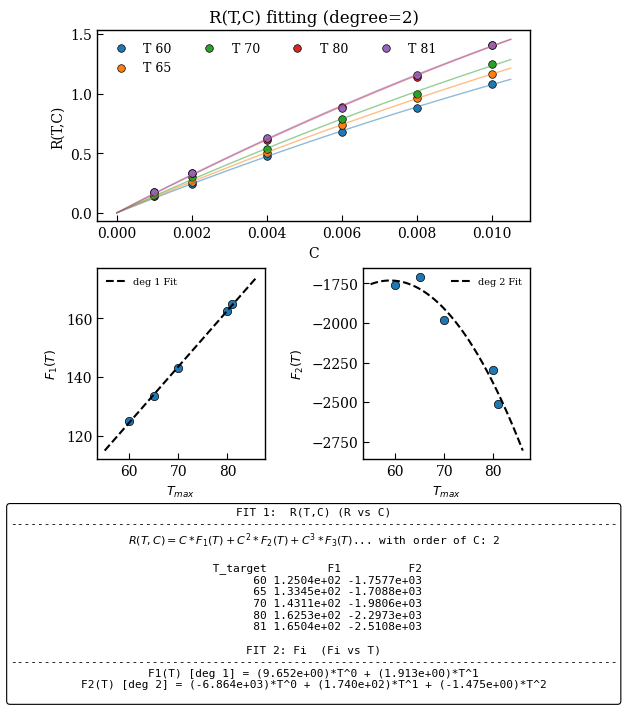

In [113]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.001, 0.002, 0.004, 0.006, 0.008, 0.01],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[1, 2],      # Linear Fi vs T
    figsize=(6, 7),  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

Validation Successful: All 5 time points found for all 6 noise levels.


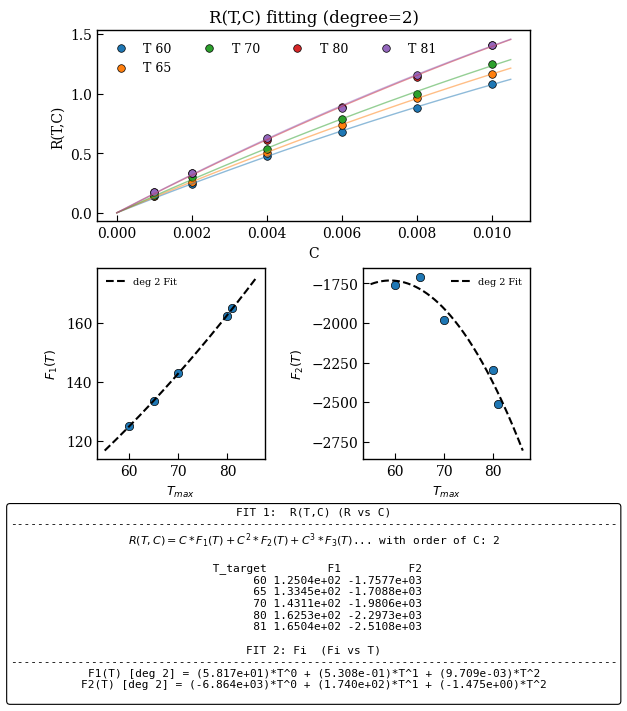

In [114]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_totalZ,
    T_data=T_by_c_for_R_totalZ,
    target_T=[60, 65, 70, 80, 81],
    target_C=[0.001, 0.002, 0.004, 0.006, 0.008, 0.01],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=2,      # Quadratic R vs C
    degree_s2=[2, 2],      # Linear Fi vs T
    figsize=(6, 7),  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)

---

# Observable `ising`

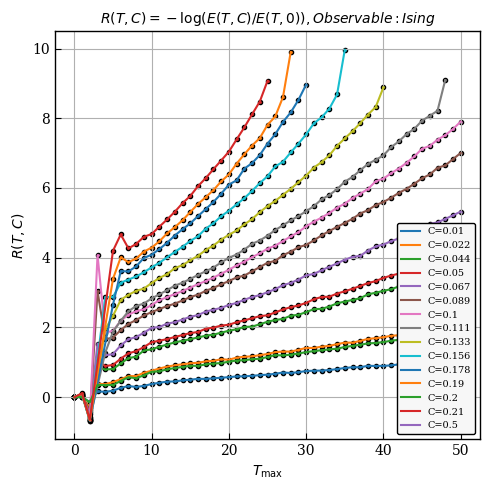

In [115]:
# ===============================
# User-defined T window
# ===============================
T_start = 0
T_end   = 100

# ===============================
# Containers to STORE R(T,C)
# ===============================
R_by_c_ising = {}
T_by_c_for_R_ising = {}

# ===============================
# Reference data at C = 0 (sign-filtered)
# ===============================
E0_all = np.array(vqe_means_sign_filtered_by_c_ising[0.0], dtype=float)
T0_all = np.array(t_vals_sign_filtered_by_c_ising[0.0], dtype=float)

plt.figure(figsize=(5, 5))

# ===============================
# Loop over C values
# ===============================
for c in sorted(vqe_means_sign_filtered_by_c_ising.keys()):
    if c == 0.0:
        continue

    E_c_all = np.array(vqe_means_sign_filtered_by_c_ising[c], dtype=float)
    T_c_all = np.array(t_vals_sign_filtered_by_c_ising[c], dtype=float)

    # -------------------------------
    # Align safely
    # -------------------------------
    N = min(len(T_c_all), len(T0_all))
    T_c_all = T_c_all[:N]
    E_c_all = E_c_all[:N]
    E0_cut  = E0_all[:N]

    # -------------------------------
    # Select T window
    # -------------------------------
    window_mask = (T_c_all >= T_start) & (T_c_all <= T_end)
    if not np.any(window_mask):
        continue

    T_c = T_c_all[window_mask]
    E_c = E_c_all[window_mask]
    E0  = E0_cut[window_mask]

    # -------------------------------
    # Compute R(T,C) ONCE
    # -------------------------------
    R = -np.log(E_c / E0)

    # -------------------------------
    # STORE for later fitting
    # -------------------------------
    R_by_c_ising[c] = R
    T_by_c_for_R_ising[c] = T_c

    # -------------------------------
    # Plot
    # -------------------------------
    plt.plot(T_c, R, label=f"C={c}")
    plt.scatter(T_c, R, marker=".", edgecolors="k")
# ===============================
# Final plot formatting
# ===============================
plt.grid(True)
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,0)), Observable: Ising$", fontsize=10)
plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)
plt.tight_layout()
plt.show()

In [116]:
R_by_c_ising.keys()

dict_keys([0.01, 0.022, 0.044, 0.05, 0.067, 0.089, 0.1, 0.111, 0.133, 0.156, 0.178, 0.19, 0.2, 0.21, 0.5])

Validation Successful: All 4 time points found for all 3 noise levels.


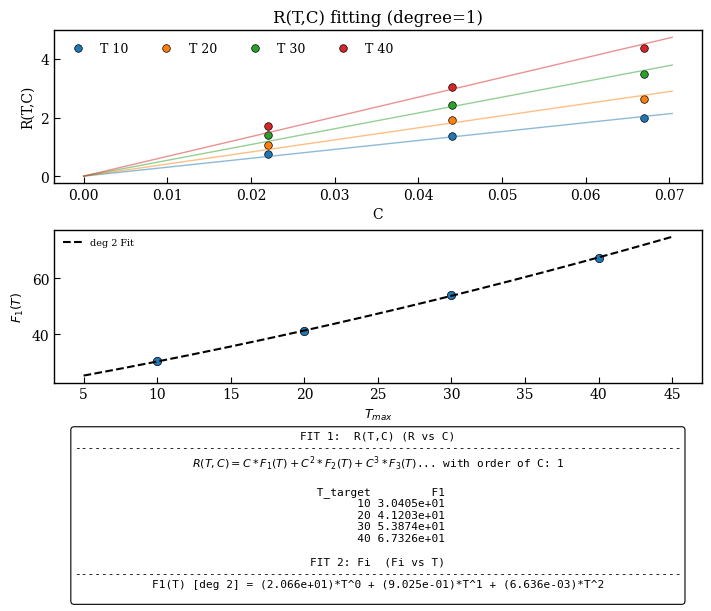

In [117]:
# Full control call
global_coeffs = perform_rtc_analysis(
    R_data=R_by_c_ising,
    T_data=T_by_c_for_R_ising,
    target_T=[10, 20, 30, 40],
    target_C=[0.022, 0.044, 0.067],
    T_by_C = T_by_c_for_R_totalZ,
    degree_s1=1,      # Quadratic R vs C
    degree_s2=[2, 1],      # Linear Fi vs T
    figsize=_fig_size,  # Custom plot size
    s1_alpha=0.5      # Lighter lines in top plot
)